In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [ ]:
df=pd.read_csv("/content/student-merged (1).csv")
print("Shape:",df.shape)
print("Nulos:",df.isnull().sum().sum())
print("Duplicados:",df.duplicated().sum())
df.head()

Shape: (383, 54)
Nulos: 0
Duplicados: 0


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel_por,freetime_por,goout_por,Dalc_por,Walc_por,health_por,absences_por,G1_por,G2_por,G3_por
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
comunes=["school","sex","age","address","famsize","Pstatus","Medu","Fedu","Mjob","Fjob","reason","guardian"]
especificas=["traveltime","studytime","failures","schoolsup","famsup","paid","activities","nursery","higher",
             "internet","romantic","famrel","freetime","goout","Dalc","Walc","health","absences","G1","G2","G3"]

df_mat=df[comunes+[c+"_mat" for c in especificas]].copy(); df_mat.columns=comunes+especificas
df_por=df[comunes+[c+"_por" for c in especificas]].copy(); df_por.columns=comunes+especificas

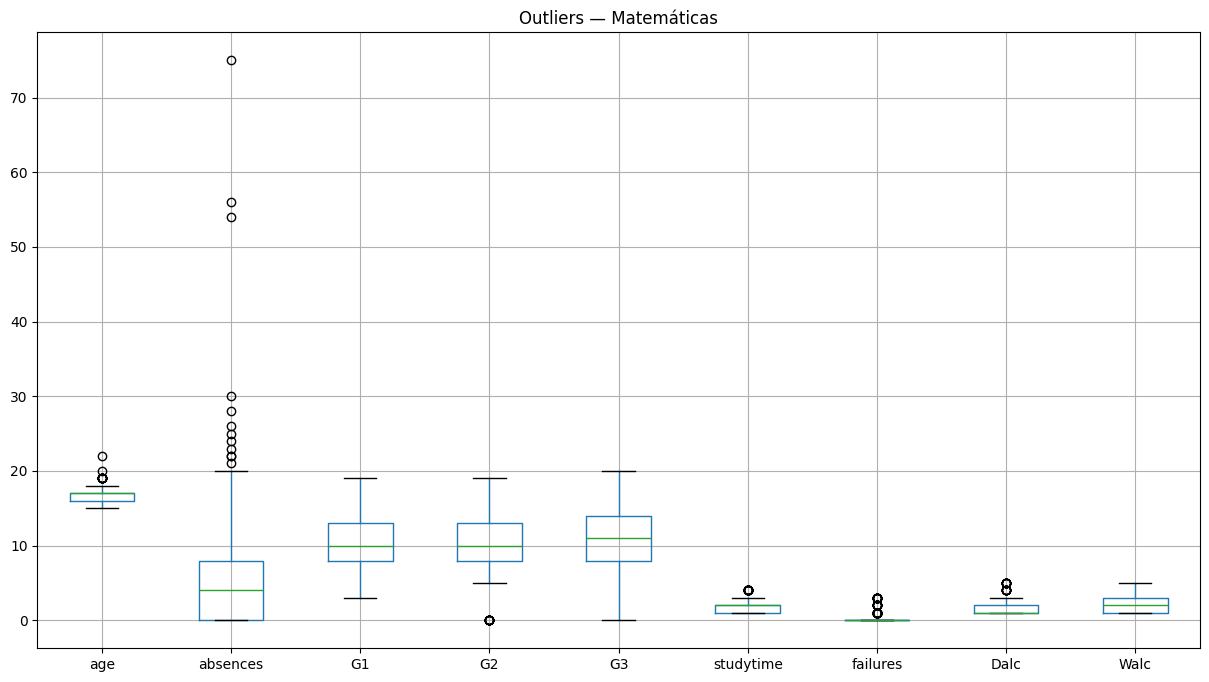

In [ ]:
vars_num=["age","absences","G1","G2","G3","studytime","failures","Dalc","Walc"]
df_mat[vars_num].boxplot(figsize=(15,8))
plt.title("Outliers — Matemáticas")
plt.show()

In [ ]:
binarias=["school","sex","address","famsize","Pstatus","schoolsup","famsup",
          "paid","activities","nursery","higher","internet","romantic"]
nominales=["Mjob","Fjob","reason","guardian"]

def codificar(data,bins,noms):
    data=data.copy()
    le=LabelEncoder()
    for c in bins: data[c]=le.fit_transform(data[c])
    data=pd.get_dummies(data,columns=noms,drop_first=True)
    bc=data.select_dtypes(include="bool").columns
    data[bc]=data[bc].astype(int)
    return data

df_mat_enc=codificar(df_mat,binarias,nominales)
df_por_enc=codificar(df_por,binarias,nominales)

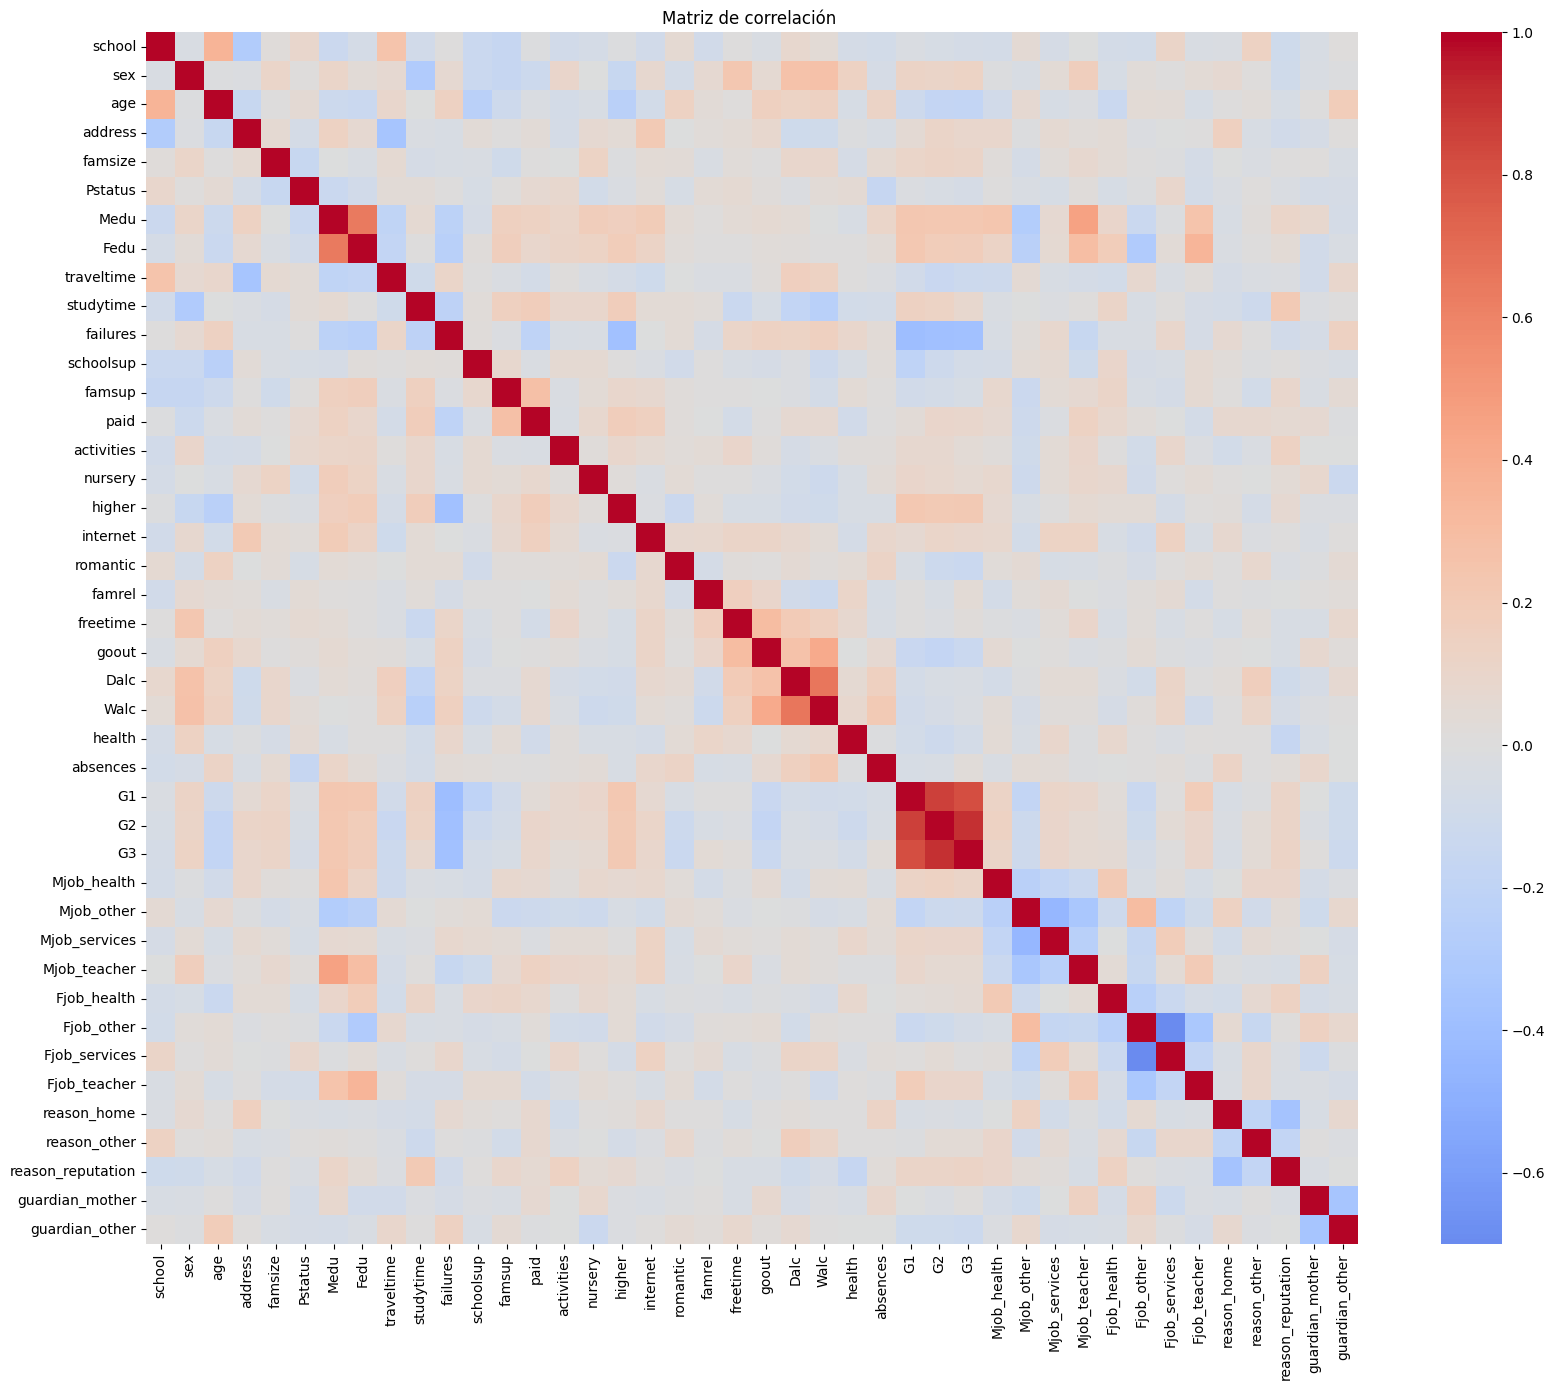

In [ ]:
plt.figure(figsize=(18,14))
sns.heatmap(df_mat_enc.corr(),cmap="coolwarm",center=0,square=True,)
plt.title("Matriz de correlación ")
plt.tight_layout(); plt.show()

In [ ]:
#2.1 Tendencias centrales y dispersión de variables principales
vars_principales=["age","studytime","failures","absences","G1","G2","G3"]

print("=== Matemáticas ===")
display(df_mat[vars_principales].describe().round(2))

print("\n=== Portugues ===")
display(df_por[vars_principales].describe().round(2))

=== Matemáticas ===


,age,studytime,failures,absences,G1,G2,G3
count,383.00,383.00,383.00,383.00,383.00,383.00,383.00
mean,16.59,2.04,0.30,5.32,10.81,10.64,10.35
std,1.17,0.84,0.74,7.60,3.34,3.82,4.64
min,15.00,1.00,0.00,0.00,3.00,0.00,0.00
25%,16.00,1.00,0.00,0.00,8.00,8.00,8.00
50%,17.00,2.00,0.00,4.00,10.00,10.00,11.00
75%,17.00,2.00,0.00,8.00,13.00,13.00,14.00
max,22.00,4.00,3.00,75.00,19.00,19.00,20.00



=== Portugues ===


,age,studytime,failures,absences,G1,G2,G3
count,383.00,383.00,383.00,383.00,383.00,383.00,383.00
mean,16.59,2.04,0.15,3.65,12.11,12.22,12.51
std,1.17,0.84,0.53,4.89,2.55,2.47,2.94
min,15.00,1.00,0.00,0.00,0.00,5.00,0.00
25%,16.00,1.00,0.00,0.00,10.00,11.00,11.00
50%,17.00,2.00,0.00,2.00,12.00,12.00,13.00
75%,17.00,2.00,0.00,6.00,14.00,14.00,14.00
max,22.00,4.00,3.00,32.00,19.00,19.00,19.00


/tmp/ipykernel_24131/366042897.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mat,x="sex",y="G3",ax=axes[0],palette="Set2")
/tmp/ipykernel_24131/366042897.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_por,x="sex",y="G3",ax=axes[1],palette="Set2")


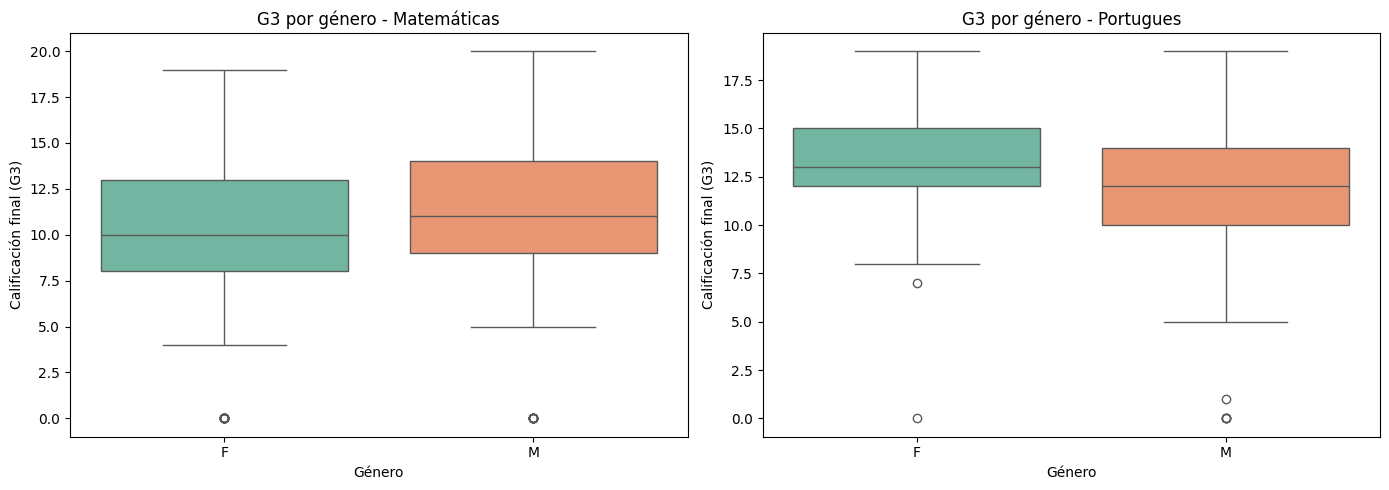


Promedio G3 por género:
Mat: {'F': 9.78, 'M': 10.98}
Por: {'F': 13.08, 'M': 11.87}


In [ ]:
#2.2 Distribución de calificaciones por género
fig,axes=plt.subplots(1,2,figsize=(14,5))

sns.boxplot(data=df_mat,x="sex",y="G3",ax=axes[0],palette="Set2")
axes[0].set_title("G3 por género - Matemáticas")
axes[0].set_xlabel("Género")
axes[0].set_ylabel("Calificación final (G3)")

sns.boxplot(data=df_por,x="sex",y="G3",ax=axes[1],palette="Set2")
axes[1].set_title("G3 por género - Portugues")
axes[1].set_xlabel("Género")
axes[1].set_ylabel("Calificación final (G3)")

plt.tight_layout()
plt.show()

print("\nPromedio G3 por género:")
print("Mat:",df_mat.groupby("sex")["G3"].mean().round(2).to_dict())
print("Por:",df_por.groupby("sex")["G3"].mean().round(2).to_dict())

/tmp/ipykernel_24131/2782815035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mat,x="age",y="G3",ax=axes[0],palette="viridis")
/tmp/ipykernel_24131/2782815035.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_por,x="age",y="G3",ax=axes[1],palette="viridis")


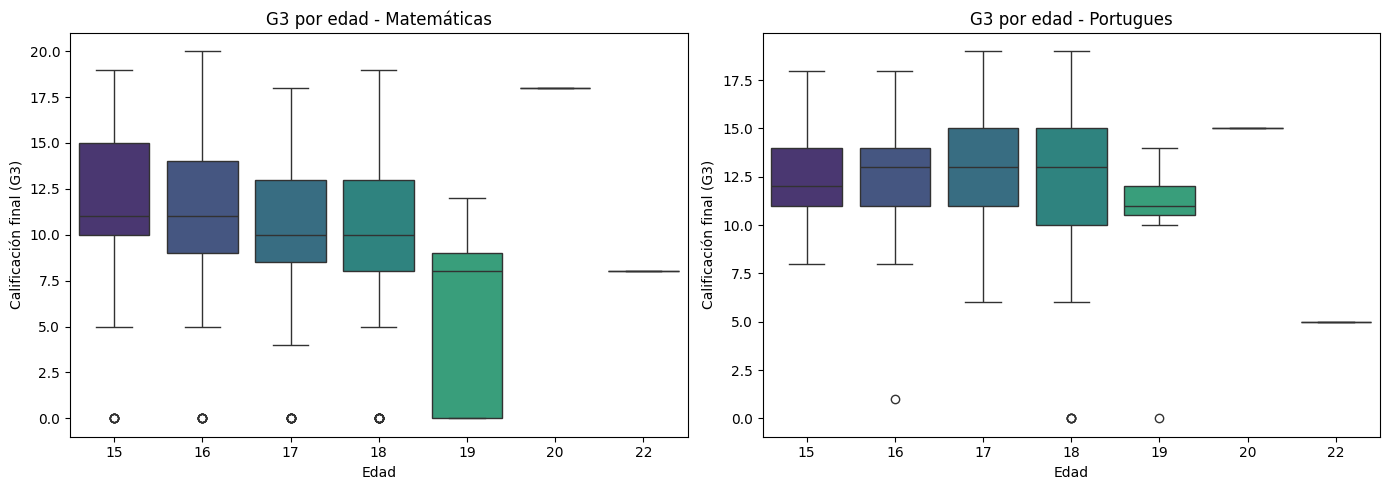

In [ ]:
#2.3 Distribución de calificaciones por edad
fig,axes=plt.subplots(1,2,figsize=(14,5))

sns.boxplot(data=df_mat,x="age",y="G3",ax=axes[0],palette="viridis")
axes[0].set_title("G3 por edad - Matemáticas")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Calificación final (G3)")

sns.boxplot(data=df_por,x="age",y="G3",ax=axes[1],palette="viridis")
axes[1].set_title("G3 por edad - Portugues")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Calificación final (G3)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_24131/1531402616.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mat,x="schoolsup",y="G3",ax=axes[0],palette="coolwarm")
/tmp/ipykernel_24131/1531402616.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_por,x="schoolsup",y="G3",ax=axes[1],palette="coolwarm")


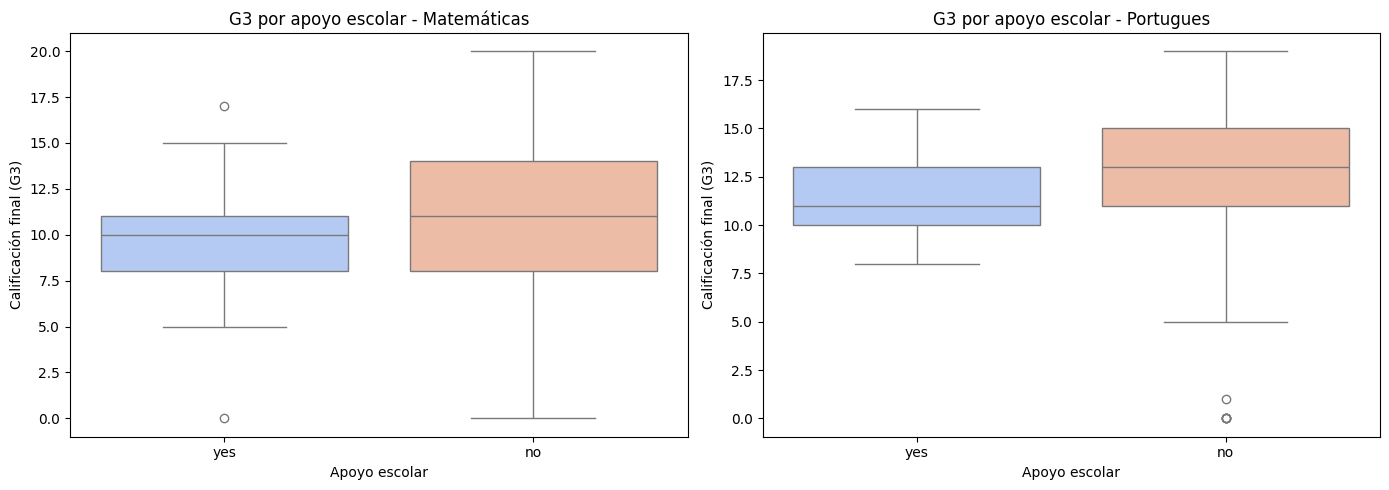


Promedio G3 por apoyo escolar:
Mat: {'no': 10.48, 'yes': 9.49}
Por: {'no': 12.67, 'yes': 11.46}


In [ ]:
#2.4 Distribución de calificaciones por apoyo escolar
fig,axes=plt.subplots(1,2,figsize=(14,5))

sns.boxplot(data=df_mat,x="schoolsup",y="G3",ax=axes[0],palette="coolwarm")
axes[0].set_title("G3 por apoyo escolar - Matemáticas")
axes[0].set_xlabel("Apoyo escolar")
axes[0].set_ylabel("Calificación final (G3)")

sns.boxplot(data=df_por,x="schoolsup",y="G3",ax=axes[1],palette="coolwarm")
axes[1].set_title("G3 por apoyo escolar - Portugues")
axes[1].set_xlabel("Apoyo escolar")
axes[1].set_ylabel("Calificación final (G3)")

plt.tight_layout()
plt.show()

print("\nPromedio G3 por apoyo escolar:")
print("Mat:",df_mat.groupby("schoolsup")["G3"].mean().round(2).to_dict())
print("Por:",df_por.groupby("schoolsup")["G3"].mean().round(2).to_dict())

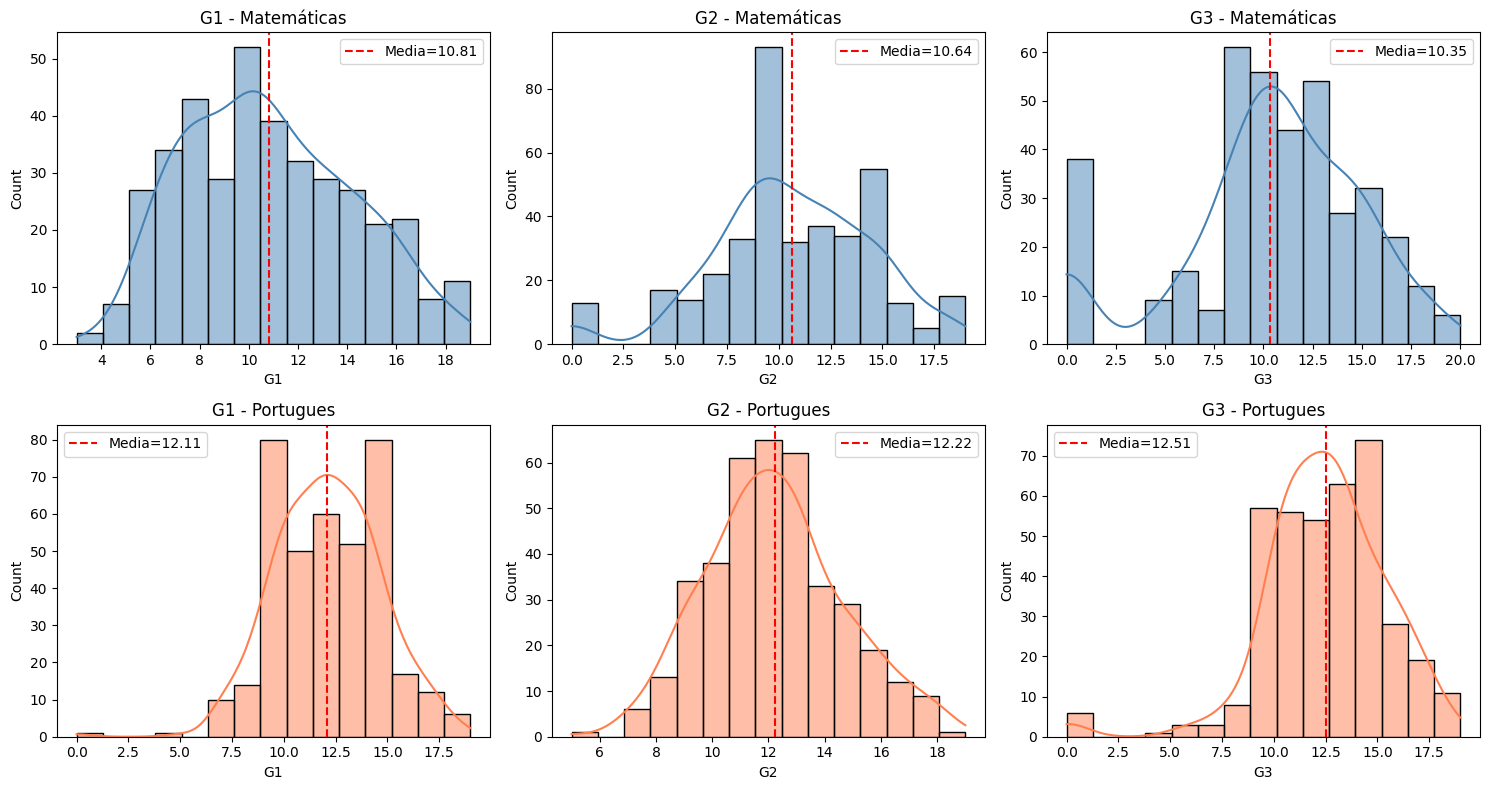

In [ ]:
#2.5 Distribución de las tres calificaciones
fig,axes=plt.subplots(2,3,figsize=(15,8))

for i,col in enumerate(["G1","G2","G3"]):
    sns.histplot(df_mat[col],bins=15,kde=True,ax=axes[0,i],color="steelblue")
    axes[0,i].set_title(f"{col} - Matemáticas")
    axes[0,i].axvline(df_mat[col].mean(),color="red",linestyle="--",label=f"Media={df_mat[col].mean():.2f}")
    axes[0,i].legend()

    sns.histplot(df_por[col],bins=15,kde=True,ax=axes[1,i],color="coral")
    axes[1,i].set_title(f"{col} - Portugues")
    axes[1,i].axvline(df_por[col].mean(),color="red",linestyle="--",label=f"Media={df_por[col].mean():.2f}")
    axes[1,i].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_24131/1984631388.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mat,x="Medu",y="G3",ax=axes[0,0],palette="Blues")
/tmp/ipykernel_24131/1984631388.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_por,x="Medu",y="G3",ax=axes[0,1],palette="Blues")
/tmp/ipykernel_24131/1984631388.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mat,x="Fedu",y="G3",ax=axes[1,0],palette="Oranges")
/tmp/ipykernel_24131/1984631388.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

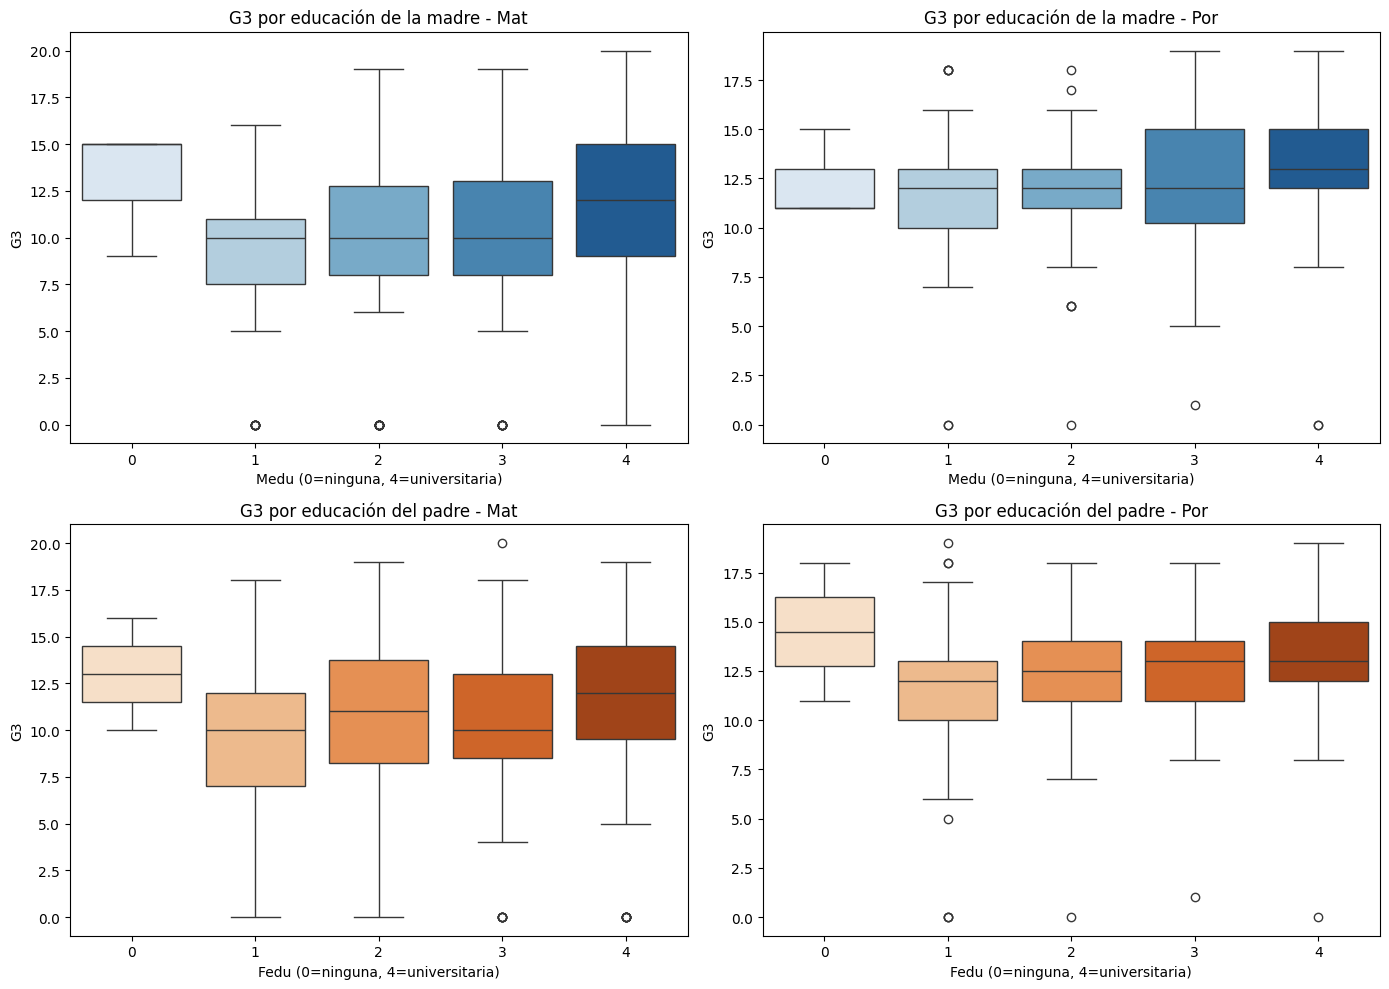


Promedio G3 por nivel educativo de la madre (Medu):
Mat: {0: 13.0, 1: 8.57, 2: 9.52, 3: 10.21, 4: 11.7}
Por: {0: 12.33, 1: 11.55, 2: 12.04, 3: 12.46, 4: 13.28}


In [ ]:
#2.6 Patrones del entorno familiar — Educación de los padres
fig,axes=plt.subplots(2,2,figsize=(14,10))

#Educación madre
sns.boxplot(data=df_mat,x="Medu",y="G3",ax=axes[0,0],palette="Blues")
axes[0,0].set_title("G3 por educación de la madre - Mat")
axes[0,0].set_xlabel("Medu (0=ninguna, 4=universitaria)")

sns.boxplot(data=df_por,x="Medu",y="G3",ax=axes[0,1],palette="Blues")
axes[0,1].set_title("G3 por educación de la madre - Por")
axes[0,1].set_xlabel("Medu (0=ninguna, 4=universitaria)")

#Educación padre
sns.boxplot(data=df_mat,x="Fedu",y="G3",ax=axes[1,0],palette="Oranges")
axes[1,0].set_title("G3 por educación del padre - Mat")
axes[1,0].set_xlabel("Fedu (0=ninguna, 4=universitaria)")

sns.boxplot(data=df_por,x="Fedu",y="G3",ax=axes[1,1],palette="Oranges")
axes[1,1].set_title("G3 por educación del padre - Por")
axes[1,1].set_xlabel("Fedu (0=ninguna, 4=universitaria)")

plt.tight_layout()
plt.show()

print("\nPromedio G3 por nivel educativo de la madre (Medu):")
print("Mat:",df_mat.groupby("Medu")["G3"].mean().round(2).to_dict())
print("Por:",df_por.groupby("Medu")["G3"].mean().round(2).to_dict())

/tmp/ipykernel_24131/890119154.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mat,x="Mjob",y="G3",ax=axes[0,0],palette="Set3")
/tmp/ipykernel_24131/890119154.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_por,x="Mjob",y="G3",ax=axes[0,1],palette="Set3")
/tmp/ipykernel_24131/890119154.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mat,x="famrel",y="G3",ax=axes[1,0],palette="Greens")
/tmp/ipykernel_24131/890119154.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be

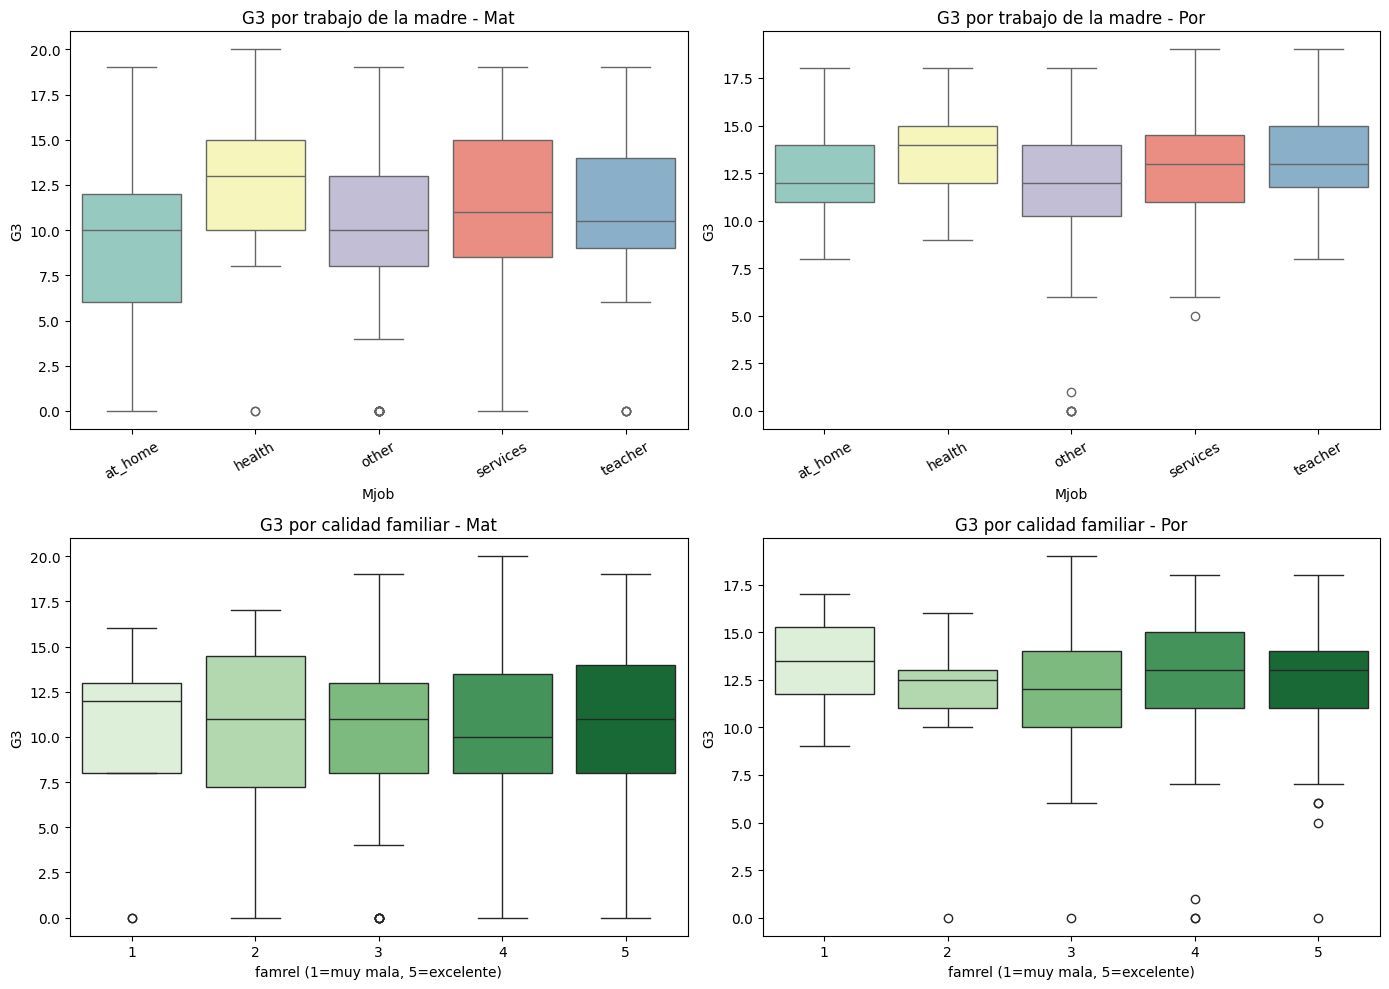

In [ ]:
#2.7 Patrones del entorno familiar — Trabajo de la madre y relaciones familiares
fig,axes=plt.subplots(2,2,figsize=(14,10))

#Trabajo de la madre
sns.boxplot(data=df_mat,x="Mjob",y="G3",ax=axes[0,0],palette="Set3")
axes[0,0].set_title("G3 por trabajo de la madre - Mat")
axes[0,0].tick_params(axis="x",rotation=30)

sns.boxplot(data=df_por,x="Mjob",y="G3",ax=axes[0,1],palette="Set3")
axes[0,1].set_title("G3 por trabajo de la madre - Por")
axes[0,1].tick_params(axis="x",rotation=30)

#Calidad de relaciones familiares
sns.boxplot(data=df_mat,x="famrel",y="G3",ax=axes[1,0],palette="Greens")
axes[1,0].set_title("G3 por calidad familiar - Mat")
axes[1,0].set_xlabel("famrel (1=muy mala, 5=excelente)")

sns.boxplot(data=df_por,x="famrel",y="G3",ax=axes[1,1],palette="Greens")
axes[1,1].set_title("G3 por calidad familiar - Por")
axes[1,1].set_xlabel("famrel (1=muy mala, 5=excelente)")

plt.tight_layout()
plt.show()

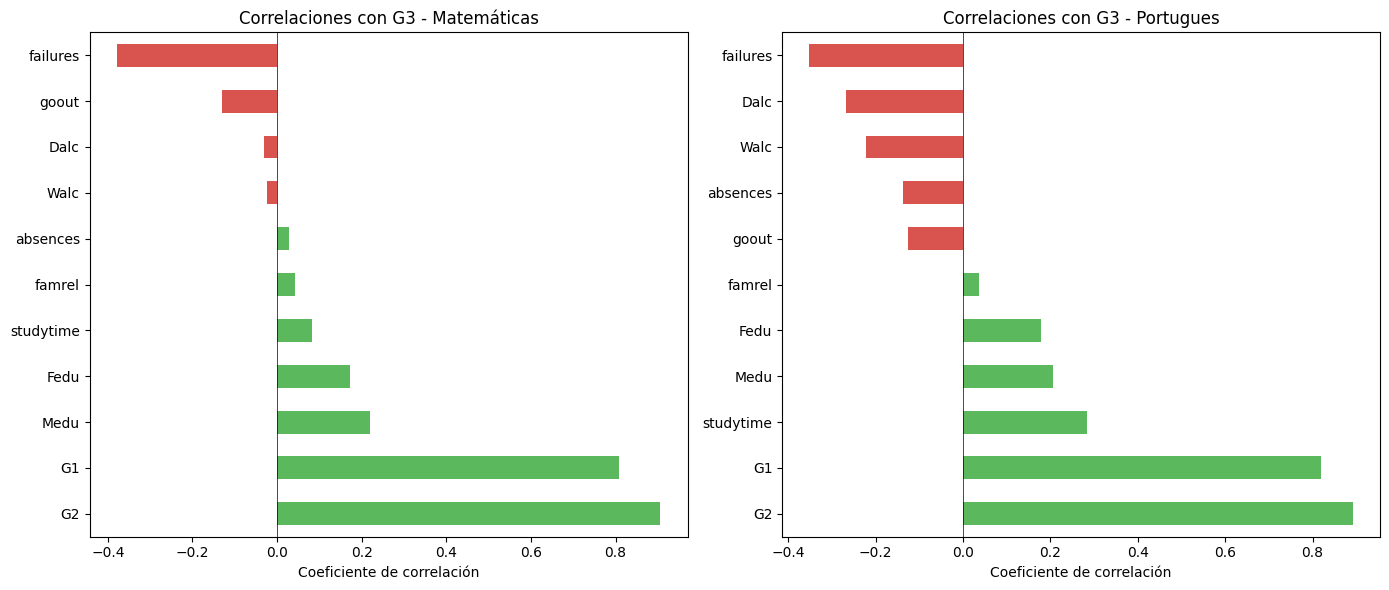


Top correlaciones con G3 - Mat:
G2           0.906
G1           0.808
Medu         0.220
Fedu         0.173
studytime    0.082
Name: G3, dtype: float64

Top correlaciones con G3 - Por:
G2           0.892
G1           0.820
studytime    0.284
Medu         0.205
Fedu         0.178
Name: G3, dtype: float64


In [ ]:
#2.8 Correlaciones socioeducativas con G3
socio_vars=["Medu","Fedu","studytime","failures","absences","Dalc","Walc","goout","famrel","G1","G2","G3"]

#Convertir Mjob y Fjob temporalmente para correlación (LabelEncoder rapido)
df_mat_corr=df_mat[socio_vars].copy()
df_por_corr=df_por[socio_vars].copy()

#Correlaciones con G3
corr_g3_mat=df_mat_corr.corr()["G3"].drop("G3").sort_values(ascending=False)
corr_g3_por=df_por_corr.corr()["G3"].drop("G3").sort_values(ascending=False)

#Visualización
fig,axes=plt.subplots(1,2,figsize=(14,6))

corr_g3_mat.plot(kind="barh",ax=axes[0],color=["#5cb85c" if v>0 else "#d9534f" for v in corr_g3_mat])
axes[0].set_title("Correlaciones con G3 - Matemáticas")
axes[0].set_xlabel("Coeficiente de correlación")
axes[0].axvline(0,color="black",linewidth=0.5)

corr_g3_por.plot(kind="barh",ax=axes[1],color=["#5cb85c" if v>0 else "#d9534f" for v in corr_g3_por])
axes[1].set_title("Correlaciones con G3 - Portugues")
axes[1].set_xlabel("Coeficiente de correlación")
axes[1].axvline(0,color="black",linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nTop correlaciones con G3 - Mat:")
print(corr_g3_mat.head(5).round(3))
print("\nTop correlaciones con G3 - Por:")
print(corr_g3_por.head(5).round(3))

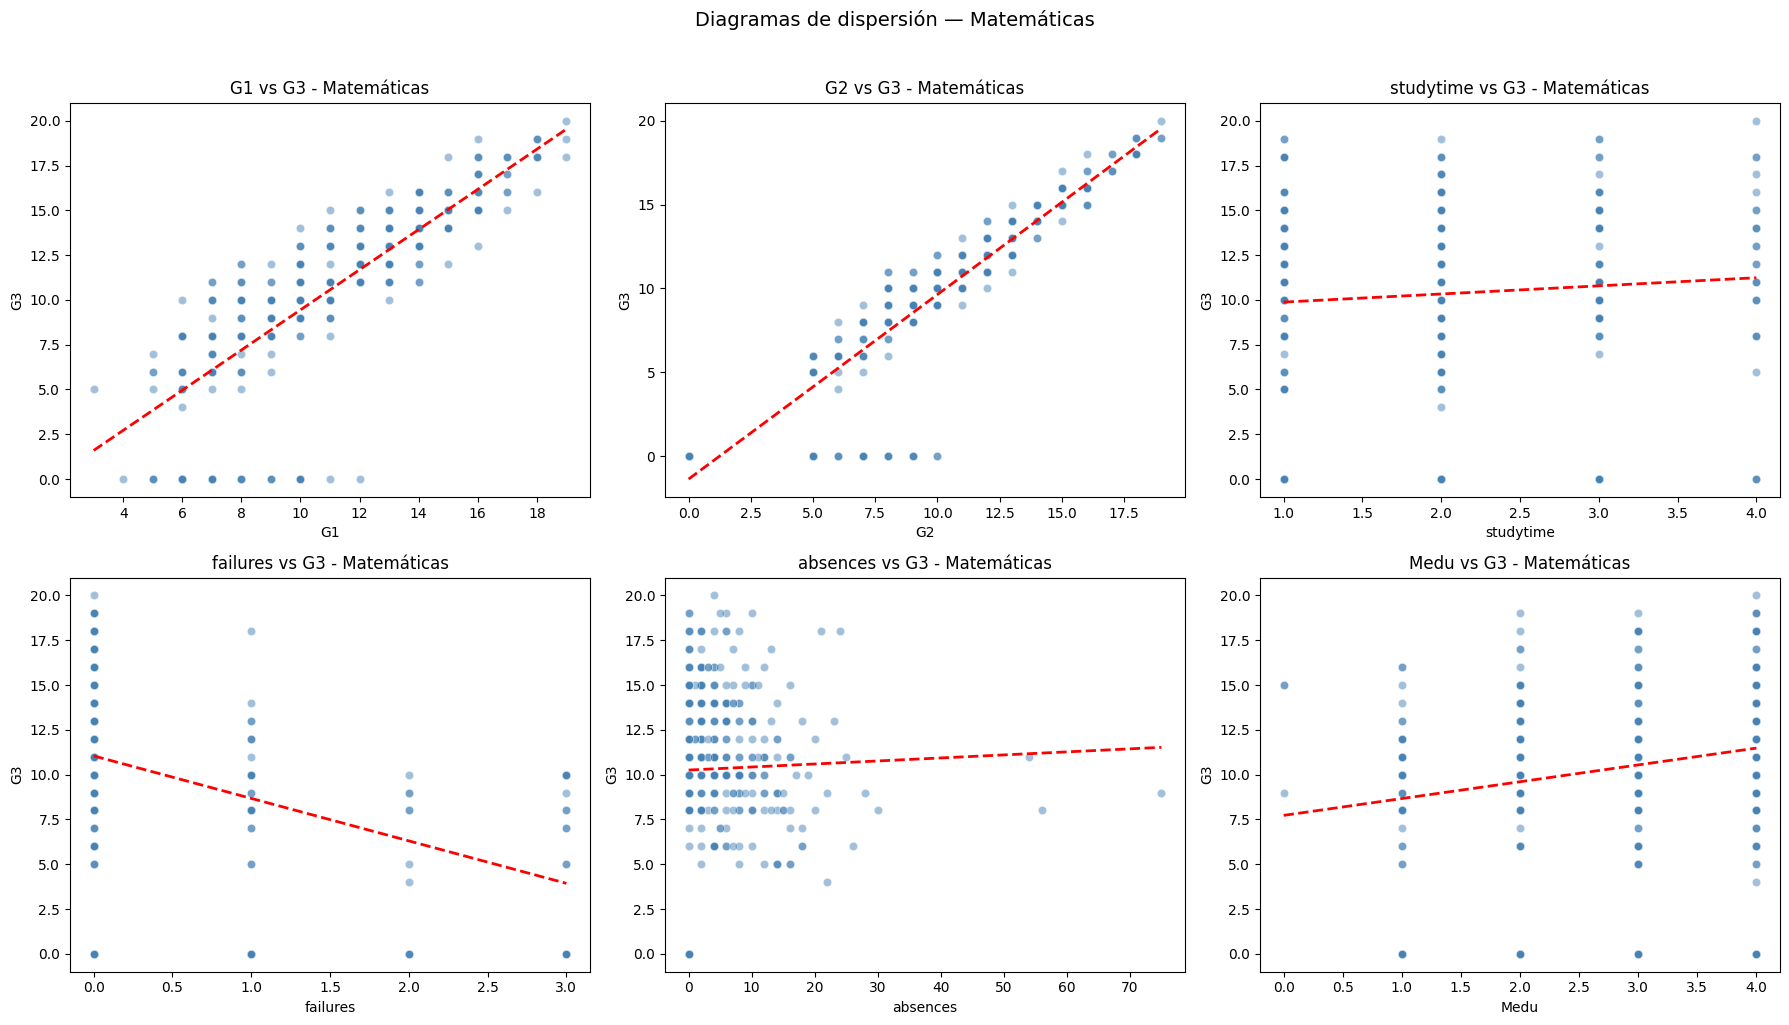

In [ ]:
#3.1 Diagramas de dispersión — Variables principales vs G3 (Matemáticas)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
scatter_vars = ["G1", "G2", "studytime", "failures", "absences", "Medu"]

for i, var in enumerate(scatter_vars):
    row, col = divmod(i, 3)
    axes[row, col].scatter(df_mat[var], df_mat["G3"], alpha=0.5, color="steelblue", edgecolors="white", linewidth=0.5)
    # Línea de tendencia
    z = np.polyfit(df_mat[var], df_mat["G3"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_mat[var].min(), df_mat[var].max(), 100)
    axes[row, col].plot(x_line, p(x_line), color="red", linestyle="--", linewidth=2)
    axes[row, col].set_title(f"{var} vs G3 - Matemáticas")
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel("G3")

plt.suptitle("Diagramas de dispersión — Matemáticas", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


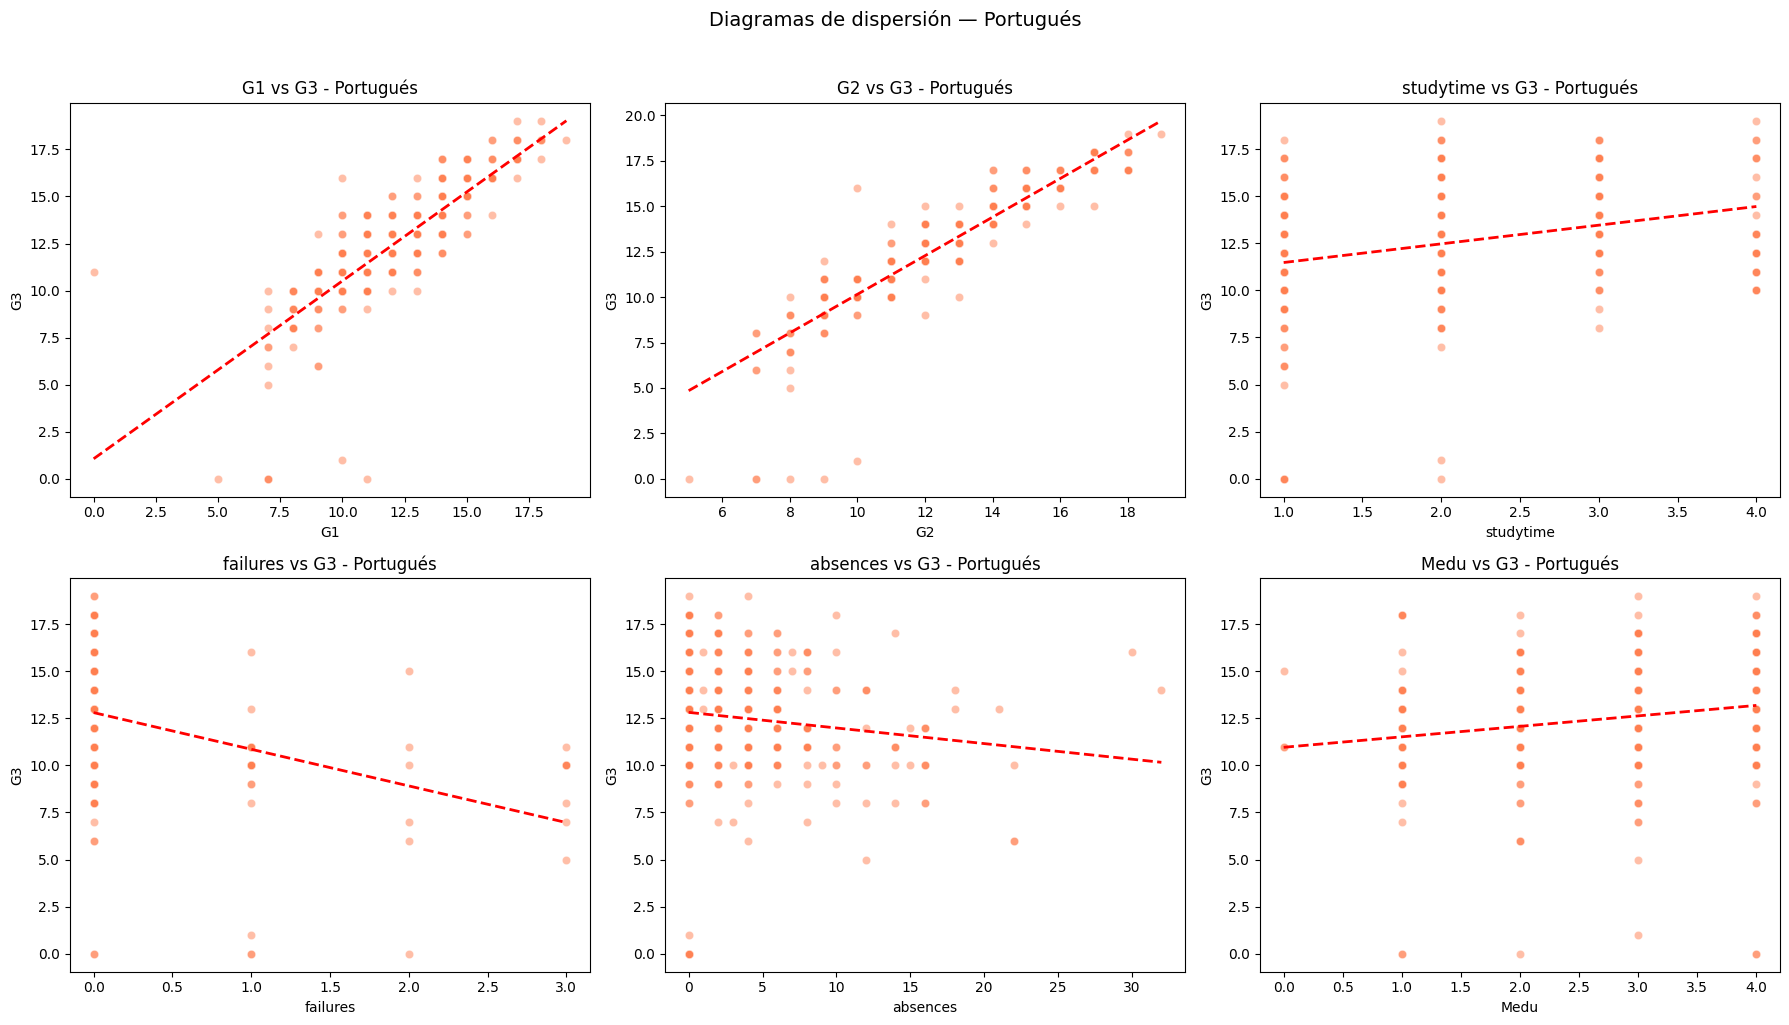

In [ ]:
#3.2 Diagramas de dispersión — Variables principales vs G3 (Portugués)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
scatter_vars = ["G1", "G2", "studytime", "failures", "absences", "Medu"]

for i, var in enumerate(scatter_vars):
    row, col = divmod(i, 3)
    axes[row, col].scatter(df_por[var], df_por["G3"], alpha=0.5, color="coral", edgecolors="white", linewidth=0.5)
    z = np.polyfit(df_por[var], df_por["G3"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_por[var].min(), df_por[var].max(), 100)
    axes[row, col].plot(x_line, p(x_line), color="red", linestyle="--", linewidth=2)
    axes[row, col].set_title(f"{var} vs G3 - Portugués")
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel("G3")

plt.suptitle("Diagramas de dispersión — Portugués", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


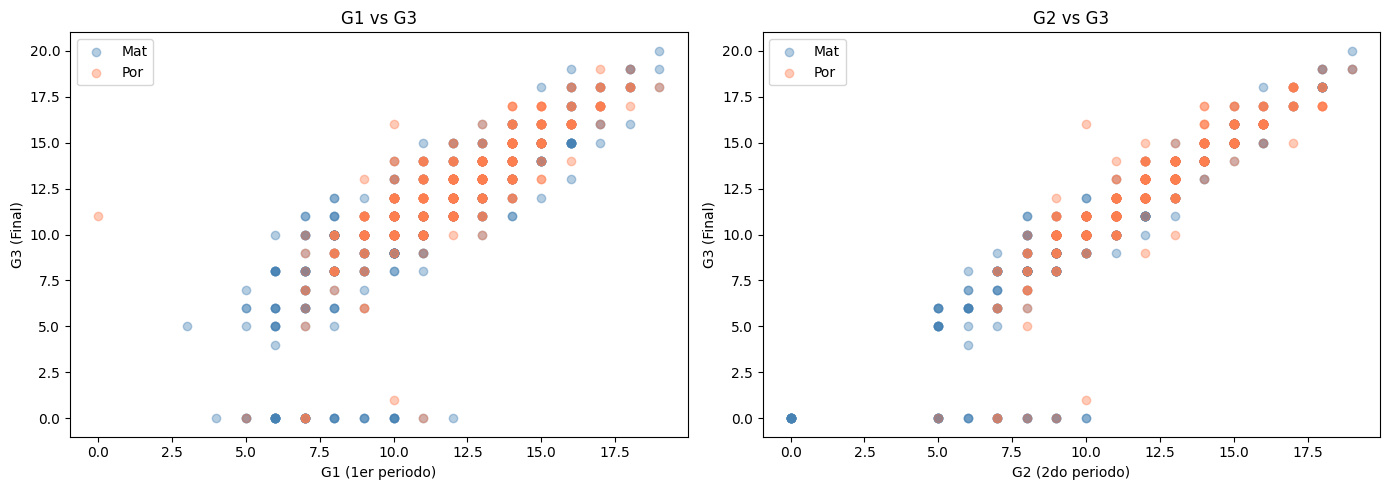

In [ ]:
#3.3 Scatter G1 vs G2 vs G3 — Relación entre calificaciones parciales y final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# G1 vs G3
axes[0].scatter(df_mat["G1"], df_mat["G3"], alpha=0.4, color="steelblue", label="Mat")
axes[0].scatter(df_por["G1"], df_por["G3"], alpha=0.4, color="coral", label="Por")
axes[0].set_title("G1 vs G3")
axes[0].set_xlabel("G1 (1er periodo)")
axes[0].set_ylabel("G3 (Final)")
axes[0].legend()

# G2 vs G3
axes[1].scatter(df_mat["G2"], df_mat["G3"], alpha=0.4, color="steelblue", label="Mat")
axes[1].scatter(df_por["G2"], df_por["G3"], alpha=0.4, color="coral", label="Por")
axes[1].set_title("G2 vs G3")
axes[1].set_xlabel("G2 (2do periodo)")
axes[1].set_ylabel("G3 (Final)")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
#CAtegorización de G3
def categorizar_g3(g):
    if g<=9: return 0
    elif g<=13: return 1
    else: return 2

df_mat_enc["G3_cat"]=df_mat_enc["G3"].apply(categorizar_g3)
df_por_enc["G3_cat"]=df_por_enc["G3"].apply(categorizar_g3)
print("Mat:",df_mat_enc["G3_cat"].value_counts().sort_index().to_dict())
print("Por:",df_por_enc["G3_cat"].value_counts().sort_index().to_dict())

Mat: {0: 130, 1: 154, 2: 99}
Por: {0: 32, 1: 219, 2: 132}


In [ ]:
#Matemáticas (Regresión)
#1.1 Declaración de variables
y_mat_reg= df_mat_enc["G3"]
X_mat= df_mat_enc.drop(columns=["G3","G3_cat"])

#1.2 División de train_test
X_mat_train,X_mat_test,y_mat_reg_train,y_mat_reg_test= train_test_split(
    X_mat,y_mat_reg,test_size=0.2,random_state=0
)

#1.3 Escalado de datos
scaler_mat= StandardScaler()
X_mat_train_scaled= scaler_mat.fit_transform(X_mat_train)
X_mat_test_scaled= scaler_mat.transform(X_mat_test)

X_mat_train_scaled.shape, X_mat_test_scaled.shape

((306, 41), (77, 41))

In [ ]:
#Matemáticas (Clasificación)
#1.1 Declaración de variables
y_mat_clf= df_mat_enc["G3_cat"]
X_mat= df_mat_enc.drop(columns=["G3","G3_cat"])

#1.2 División de train_test
X_mat_train,X_mat_test,y_mat_clf_train,y_mat_clf_test= train_test_split(
    X_mat,y_mat_clf,test_size=0.2,random_state=0,stratify=y_mat_clf
)

#1.3 Escalado de datos
scaler_mat= StandardScaler()
X_mat_train_scaled= scaler_mat.fit_transform(X_mat_train)
X_mat_test_scaled= scaler_mat.transform(X_mat_test)

X_mat_train_scaled.shape, X_mat_test_scaled.shape

((306, 41), (77, 41))

In [ ]:
print(y_mat_clf_train.value_counts())

ratio = y_mat_clf_train.value_counts().max() / y_mat_clf_train.value_counts().sum()
print("Ratio de la clase mayoritaria", round(ratio,2))
bal=ratio
if bal<0.75:
    print("Balanceado")
else:
    print("Desbalanceado")

G3_cat
1    123
0    104
2     79
Name: count, dtype: int64
Ratio de la clase mayoritaria 0.4
Balanceado


In [ ]:
#Portugues (Regresión)
#1.1 Declaración de variables
y_por_reg= df_por_enc["G3"]
X_por= df_por_enc.drop(columns=["G3","G3_cat"])

#1.2 División de train_test
X_por_train,X_por_test,y_por_reg_train,y_por_reg_test= train_test_split(
    X_por,y_por_reg,test_size=0.2,random_state=0
)

#1.3 Escalado de datos
scaler_por= StandardScaler()
X_por_train_scaled= scaler_por.fit_transform(X_por_train)
X_por_test_scaled= scaler_por.transform(X_por_test)

X_por_train_scaled.shape, X_por_test_scaled.shape

((306, 41), (77, 41))

In [ ]:
#Portugues (Clasificación)
#1.1 Declaración de variables
y_por_clf= df_por_enc["G3_cat"]
X_por= df_por_enc.drop(columns=["G3","G3_cat"])

#1.2 División de train_test
X_por_train,X_por_test,y_por_clf_train,y_por_clf_test= train_test_split(
    X_por,y_por_clf,test_size=0.2,random_state=0,stratify=y_por_clf
)

#1.3 Escalado de datos
scaler_por= StandardScaler()
X_por_train_scaled= scaler_por.fit_transform(X_por_train)
X_por_test_scaled= scaler_por.transform(X_por_test)

X_por_train_scaled.shape, X_por_test_scaled.shape

((306, 41), (77, 41))

In [ ]:
print(y_por_clf_train.value_counts())

ratio = y_por_clf_train.value_counts().max() / y_por_clf_train.value_counts().sum()
print("Ratio de la clase mayoritaria", round(ratio,2))
bal=ratio
if bal<0.75:
    print("Balanceado")
else:
    print("Desbalanceado")

G3_cat
1    175
2    105
0     26
Name: count, dtype: int64
Ratio de la clase mayoritaria 0.57
Balanceado


In [ ]:
#Librerías Feature Selection + Feature Importance
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# Feature Selection Matemáticas

In [ ]:
# 1.4.1 ANOVA (Analysis of variance) (F-Test) - Matemáticas
anova_filter_mat=SelectKBest(score_func=f_classif,k=10)
X_mat_train_filter = anova_filter_mat.fit_transform(X_mat_train_scaled,y_mat_clf_train)
X_mat_test_filter = anova_filter_mat.transform(X_mat_test_scaled)
#Variables filtradas por ANOVA
filtro_mat=X_mat.columns[anova_filter_mat.get_support()]
print("Variables elegidas por Método FILTER (Mat):", list(filtro_mat))

Variables elegidas por Método FILTER (Mat): ['age', 'Medu', 'failures', 'schoolsup', 'higher', 'goout', 'Dalc', 'Walc', 'G1', 'G2']


In [ ]:
#1.4.2 Método Wrapped (envolvente) - Matemáticas
modelo_mat = LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    random_state=0
)
selector_wrapped_mat=RFE(estimator=modelo_mat,n_features_to_select=10)
X_mat_train_wrapped=selector_wrapped_mat.fit_transform(X_mat_train_scaled,y_mat_clf_train)
X_mat_test_wrapped=selector_wrapped_mat.transform(X_mat_test_scaled)

wrapped_mat=X_mat.columns[selector_wrapped_mat.get_support()]
print("Variables elegidas por Método Wrapped (Mat):",list(wrapped_mat))

Variables elegidas por Método Wrapped (Mat): ['school', 'age', 'Medu', 'failures', 'famrel', 'goout', 'Walc', 'G1', 'G2', 'Fjob_other']


In [ ]:
# 1.4.3 Método Embedded (Incrustado) - Matemáticas
modelo_emb_mat = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    random_state=0
)
modelo_emb_mat.fit(X_mat_train_scaled,y_mat_clf_train)

selector_embedded_mat = SelectFromModel(modelo_emb_mat, prefit=True)
X_mat_train_embedded = selector_embedded_mat.transform(X_mat_train_scaled)
X_mat_test_embedded = selector_embedded_mat.transform(X_mat_test_scaled)

embedded_mat = X_mat.columns[selector_embedded_mat.get_support()]
print("Variables elegidas por Método EMBEDDED (Mat):", list(embedded_mat))

Variables elegidas por Método EMBEDDED (Mat): ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other']


In [ ]:
# 1.4.4 Método Embedded - Random Forest - Matemáticas
X_mat_train_df=pd.DataFrame(X_mat_train,columns=X_mat.columns)
X_mat_test_df=pd.DataFrame(X_mat_test,columns=X_mat.columns)

rf_mat=RandomForestClassifier(
    n_estimators=300,
    random_state=0,
    class_weight="balanced",
)
selector_rf_mat=SelectFromModel(
    estimator=rf_mat,
    threshold="median"
)
selector_rf_mat.fit(X_mat_train_df,y_mat_clf_train)

embedded_rf_mat=X_mat_train_df.columns[selector_rf_mat.get_support()]
print("Variables elegidas por Método EMBEDDED_RF (Mat):",list(embedded_rf_mat))

Variables elegidas por Método EMBEDDED_RF (Mat): ['sex', 'age', 'famsize', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'paid', 'activities', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'reason_reputation']


In [ ]:
## Resumen Feature Selection Matemáticas
feature_selection_mat=pd.DataFrame({
    "Variable":X_mat.columns,
    "Método Filtro":X_mat.columns.isin(list(filtro_mat)),
    "Método Envolvente":X_mat.columns.isin(list(wrapped_mat)),
    "Método Incrustado RL":X_mat.columns.isin(list(embedded_mat)),
    "Método Incrustado RF":X_mat.columns.isin(list(embedded_rf_mat))
})
feature_selection_mat["Conteo"]=feature_selection_mat.iloc[:,1:].sum(axis=1)
feature_selection_mat.sort_values(by="Conteo",ascending=False)

,Variable,Método Filtro,Método Envolvente,Método Incrustado RL,Método Incrustado RF,Conteo
2,age,True,True,True,True,4
6,Medu,True,True,True,True,4
21,goout,True,True,True,True,4
23,Walc,True,True,True,True,4
27,G2,True,True,True,True,4
26,G1,True,True,True,True,4
10,failures,True,True,True,True,4
19,famrel,False,True,True,True,3
22,Dalc,True,False,True,True,3
11,schoolsup,True,False,True,True,3


# Feature Selection Portugués

In [ ]:
# 1.4.1 ANOVA (Analysis of variance) (F-Test) - Portugues
anova_filter_por=SelectKBest(score_func=f_classif,k=10)
X_por_train_filter = anova_filter_por.fit_transform(X_por_train_scaled,y_por_clf_train)
X_por_test_filter = anova_filter_por.transform(X_por_test_scaled)
#Variables filtradas por ANOVA
filtro_por=X_por.columns[anova_filter_por.get_support()]
print("Variables elegidas por Método FILTER (Por):", list(filtro_por))

Variables elegidas por Método FILTER (Por): ['school', 'age', 'Medu', 'studytime', 'failures', 'schoolsup', 'higher', 'Dalc', 'G1', 'G2']


In [ ]:
#1.4.2 Método Wrapped (envolvente) - Portugues
modelo_por = LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    random_state=0
)
selector_wrapped_por=RFE(estimator=modelo_por,n_features_to_select=10)
X_por_train_wrapped=selector_wrapped_por.fit_transform(X_por_train_scaled,y_por_clf_train)
X_por_test_wrapped=selector_wrapped_por.transform(X_por_test_scaled)

wrapped_por=X_por.columns[selector_wrapped_por.get_support()]
print("Variables elegidas por Método Wrapped (Por):",list(wrapped_por))

Variables elegidas por Método Wrapped (Por): ['school', 'age', 'address', 'higher', 'internet', 'freetime', 'G1', 'G2', 'Mjob_other', 'Fjob_services']


In [ ]:
# 1.4.3 Método Embedded (Incrustado) - Portugues
modelo_emb_por = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    random_state=0
)
modelo_emb_por.fit(X_por_train_scaled,y_por_clf_train)

selector_embedded_por = SelectFromModel(modelo_emb_por, prefit=True)
X_por_train_embedded = selector_embedded_por.transform(X_por_train_scaled)
X_por_test_embedded = selector_embedded_por.transform(X_por_test_scaled)

embedded_por = X_por.columns[selector_embedded_por.get_support()]
print("Variables elegidas por Método EMBEDDED (Por):", list(embedded_por))

Variables elegidas por Método EMBEDDED (Por): ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other']


In [ ]:
# 1.4.4 Método Embedded - Random Forest - Portugues
X_por_train_df=pd.DataFrame(X_por_train,columns=X_por.columns)
X_por_test_df=pd.DataFrame(X_por_test,columns=X_por.columns)

rf_por=RandomForestClassifier(
    n_estimators=300,
    random_state=0,
    class_weight="balanced",
)
selector_rf_por=SelectFromModel(
    estimator=rf_por,
    threshold="median"
)
selector_rf_por.fit(X_por_train_df,y_por_clf_train)

embedded_rf_por=X_por_train_df.columns[selector_rf_por.get_support()]
print("Variables elegidas por Método EMBEDDED_RF (Por):",list(embedded_rf_por))

Variables elegidas por Método EMBEDDED_RF (Por): ['school', 'sex', 'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'activities', 'higher', 'internet', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [ ]:
## Resumen Feature Selection Portugues
feature_selection_por=pd.DataFrame({
    "Variable":X_por.columns,
    "Método Filtro":X_por.columns.isin(list(filtro_por)),
    "Método Envolvente":X_por.columns.isin(list(wrapped_por)),
    "Método Incrustado RL":X_por.columns.isin(list(embedded_por)),
    "Método Incrustado RF":X_por.columns.isin(list(embedded_rf_por))
})
feature_selection_por["Conteo"]=feature_selection_por.iloc[:,1:].sum(axis=1)
feature_selection_por.sort_values(by="Conteo",ascending=False)

,Variable,Método Filtro,Método Envolvente,Método Incrustado RL,Método Incrustado RF,Conteo
0,school,True,True,True,True,4
2,age,True,True,True,True,4
27,G2,True,True,True,True,4
26,G1,True,True,True,True,4
16,higher,True,True,True,True,4
9,studytime,True,False,True,True,3
6,Medu,True,False,True,True,3
22,Dalc,True,False,True,True,3
20,freetime,False,True,True,True,3
17,internet,False,True,True,True,3


In [ ]:
#Subset Final Matemáticas (Feature Selection: Conteo >=3)
features_final_mat=["age","Medu","goout","Walc","G2","G1","failures",
                    "famrel","Dalc","schoolsup"]

X_mat_final=df_mat_enc[features_final_mat]
y_mat_reg=df_mat_enc["G3"]
y_mat_clf=df_mat_enc["G3_cat"]
X_mat_final

,age,Medu,goout,Walc,G2,G1,failures,famrel,Dalc,schoolsup
0,18,4,4,1,6,5,0,4,1,1
1,17,1,3,1,5,5,0,5,1,0
2,15,1,2,3,8,7,3,4,2,1
3,15,4,2,1,14,15,0,3,1,0
4,16,3,2,2,10,6,0,4,1,0
...,...,...,...,...,...,...,...,...,...,...
378,18,3,4,1,9,7,0,4,1,0
379,18,1,1,1,5,6,1,1,1,0
380,18,1,1,1,5,6,1,1,1,0
381,17,3,5,4,16,14,0,2,3,0


In [ ]:
#Subset Final Portugues (Feature Selection: Conteo >=3)
features_final_por=["school","age","G2","G1","higher","studytime","Medu",
                    "Dalc","freetime","internet","failures","schoolsup"]

X_por_final=df_por_enc[features_final_por]
y_por_reg=df_por_enc["G3"]
y_por_clf=df_por_enc["G3_cat"]
X_por_final

,school,age,G2,G1,higher,studytime,Medu,Dalc,freetime,internet,failures,schoolsup
0,0,18,11,0,1,2,4,1,3,0,0,1
1,0,17,11,9,1,2,1,1,3,1,0,0
2,0,15,13,12,1,2,1,2,3,1,0,1
3,0,15,14,14,1,3,4,1,2,1,0,0
4,0,16,13,11,1,2,3,1,3,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
378,1,18,15,15,1,2,3,1,3,1,0,0
379,1,18,8,7,1,2,1,2,4,0,2,0
380,1,18,12,11,1,2,1,1,1,0,0,0
381,1,17,10,10,1,1,3,3,4,1,0,0


In [ ]:
#Train test split FINAL de Matemáticas (Regresión)
#1.1 División de train_test
X_mat_train,X_mat_test,y_mat_reg_train,y_mat_reg_test= train_test_split(
    X_mat_final,y_mat_reg,test_size=0.2,random_state=0
)

#1.2 Escalado de datos
scaler_mat= StandardScaler()
X_mat_train_scaled= scaler_mat.fit_transform(X_mat_train)
X_mat_test_scaled= scaler_mat.transform(X_mat_test)

X_mat_train_scaled.shape, X_mat_test_scaled.shape

((306, 10), (77, 10))

In [ ]:
#Train test split FINAL de Matemáticas (Clasificación)
X_mat_train,X_mat_test,y_mat_clf_train,y_mat_clf_test= train_test_split(
    X_mat_final,y_mat_clf,test_size=0.2,random_state=0,stratify=y_mat_clf
)

y_mat_clf_train.shape, y_mat_clf_test.shape

((306,), (77,))

In [ ]:
#Train test split FINAL Portugues (Regresión)
#1.1 División de train_test
X_por_train,X_por_test,y_por_reg_train,y_por_reg_test= train_test_split(
    X_por_final,y_por_reg,test_size=0.2,random_state=0
)

#1.2 Escalado de datos
scaler_por= StandardScaler()
X_por_train_scaled= scaler_por.fit_transform(X_por_train)
X_por_test_scaled= scaler_por.transform(X_por_test)

X_por_train_scaled.shape, X_por_test_scaled.shape

((306, 12), (77, 12))

In [ ]:
#Train test split FINAL Portugues (Clasificación)
X_por_train,X_por_test,y_por_clf_train,y_por_clf_test= train_test_split(
    X_por_final,y_por_clf,test_size=0.2,random_state=0,stratify=y_por_clf
)

y_por_clf_train.shape, y_por_clf_test.shape

((306,), (77,))

In [ ]:
#1.5 Feature Importance Matemáticas
#FS decide que variables ingresarán al modelo
#FI decide cuales son las variables más importantes del modelo
#1.5.4 Modelo de importancias (FI-RL, FI-RF)
#1.5.4.1 FI-RL
lr_mat=LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    random_state=0
)
lr_mat.fit(X_mat_train_scaled,y_mat_clf_train)

LogisticRegression(class_weight='balanced', random_state=0, solver='liblinear')

In [ ]:
#Importancias RL Matemáticas
fi_lr_mat=pd.DataFrame({
    "Variable":features_final_mat,
    "Coeficiente de importancia":lr_mat.coef_[0],
    "Importancia_abs":np.abs(lr_mat.coef_[0])
}).sort_values(by="Importancia_abs",ascending=False)
print("\n Feature Importance Regresión logística (Mat)")
print(fi_lr_mat)


 Feature Importance Regresión logística (Mat)
    Variable  Coeficiente de importancia  Importancia_abs
2      goout                   -0.453424         0.453424
3       Walc                    0.168209         0.168209
8       Dalc                   -0.105160         0.105160
6   failures                   -0.102730         0.102730
9  schoolsup                    0.098017         0.098017
0        age                    0.091463         0.091463
4         G2                    0.064396         0.064396
5         G1                    0.062251         0.062251
7     famrel                   -0.026934         0.026934
1       Medu                   -0.014763         0.014763


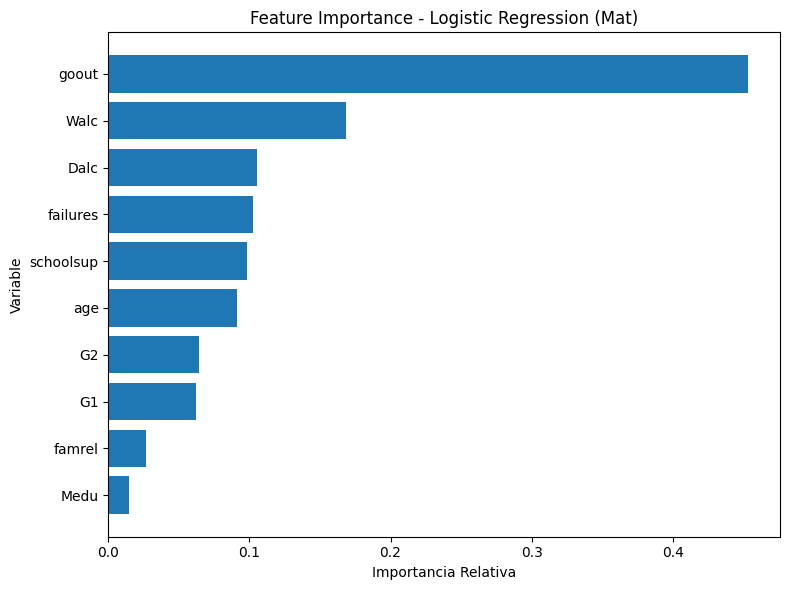

In [ ]:
#Graficamos la importancia FI-LR Matemáticas
fi_lr_mat_plot=fi_lr_mat.sort_values("Importancia_abs",ascending=True)
plt.figure(figsize=(8,6))
plt.barh(fi_lr_mat_plot["Variable"],fi_lr_mat_plot["Importancia_abs"])
plt.title("Feature Importance - Logistic Regression (Mat)")
plt.xlabel("Importancia Relativa")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [ ]:
#1.5 Feature Importance Portugues
#1.5.4.1 FI-RL
lr_por=LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    random_state=0
)
lr_por.fit(X_por_train_scaled,y_por_clf_train)

LogisticRegression(class_weight='balanced', random_state=0, solver='liblinear')

In [ ]:
#Importancias RL Portugues
fi_lr_por=pd.DataFrame({
    "Variable":features_final_por,
    "Coeficiente de importancia":lr_por.coef_[0],
    "Importancia_abs":np.abs(lr_por.coef_[0])
}).sort_values(by="Importancia_abs",ascending=False)
print("\n Feature Importance Regresión logística (Por)")
print(fi_lr_por)


 Feature Importance Regresión logística (Por)
     Variable  Coeficiente de importancia  Importancia_abs
5   studytime                    0.405449         0.405449
3          G1                   -0.315414         0.315414
7        Dalc                   -0.282241         0.282241
8    freetime                    0.252318         0.252318
2          G2                    0.236895         0.236895
4      higher                   -0.195133         0.195133
9    internet                   -0.104320         0.104320
0      school                   -0.075530         0.075530
10   failures                    0.073051         0.073051
6        Medu                    0.066930         0.066930
11  schoolsup                    0.041584         0.041584
1         age                   -0.003248         0.003248


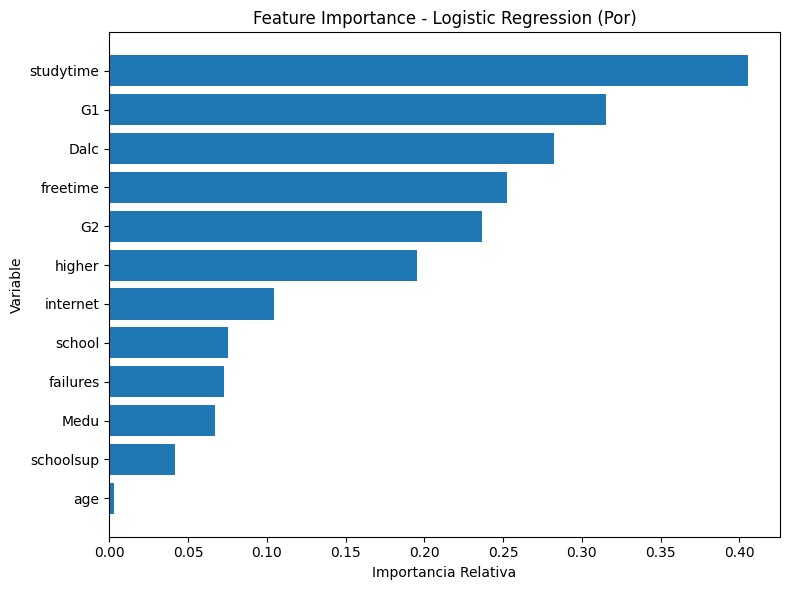

In [ ]:
#Graficamos la importancia FI-LR Portugues
fi_lr_por_plot=fi_lr_por.sort_values("Importancia_abs",ascending=True)
plt.figure(figsize=(8,6))
plt.barh(fi_lr_por_plot["Variable"],fi_lr_por_plot["Importancia_abs"])
plt.title("Feature Importance - Logistic Regression (Por)")
plt.xlabel("Importancia Relativa")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [ ]:
#Splits de regresión finales
X_mat_train,X_mat_test,y_mat_reg_train,y_mat_reg_test= train_test_split(
    X_mat_final,y_mat_reg,test_size=0.2,random_state=0
)
X_por_train,X_por_test,y_por_reg_train,y_por_reg_test= train_test_split(
    X_por_final,y_por_reg,test_size=0.2,random_state=0
)

#Reescalar
scaler_mat=StandardScaler()
X_mat_train_scaled=scaler_mat.fit_transform(X_mat_train)
X_mat_test_scaled=scaler_mat.transform(X_mat_test)

scaler_por=StandardScaler()
X_por_train_scaled=scaler_por.fit_transform(X_por_train)
X_por_test_scaled=scaler_por.transform(X_por_test)

print("Splits de regresión")
print("X_mat_train:",X_mat_train.shape,"| y_mat_reg_train:",y_mat_reg_train.shape)
print("X_por_train:",X_por_train.shape,"| y_por_reg_train:",y_por_reg_train.shape)

Splits de regresión
X_mat_train: (306, 10) | y_mat_reg_train: (306,)
X_por_train: (306, 12) | y_por_reg_train: (306,)


# Modelos básicos AR, RF y LR

In [ ]:
#Librerías regresión
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

#Configuración global
kf=KFold(n_splits=5,shuffle=True,random_state=0)
mask_mat=y_mat_reg_test!=0
mask_por=y_por_reg_test!=0

In [ ]:
#REGRESIÓN LINEAL - Matemáticas
modelo_rl_mat=LinearRegression()
modelo_rl_mat.fit(X_mat_train_scaled,y_mat_reg_train)

LinearRegression()

In [ ]:
#Predicciones
y_pred_test_rl_mat=modelo_rl_mat.predict(X_mat_test_scaled)

#Métricas
r2_rl_mat=r2_score(y_mat_reg_test,y_pred_test_rl_mat)
rmse_rl_mat=np.sqrt(mean_squared_error(y_mat_reg_test,y_pred_test_rl_mat))
mae_rl_mat=mean_absolute_error(y_mat_reg_test,y_pred_test_rl_mat)
mape_rl_mat=mean_absolute_percentage_error(y_mat_reg_test[mask_mat],y_pred_test_rl_mat[mask_mat])

print("Regresión Lineal - Matemáticas")
print(f"R²:   {r2_rl_mat:.4f}")
print(f"RMSE: {rmse_rl_mat:.4f}")
print(f"MAE:  {mae_rl_mat:.4f}")
print(f"MAPE: {mape_rl_mat:.4f}")

Regresión Lineal - Matemáticas
R²:   0.8371
RMSE: 1.7474
MAE:  1.2868
MAPE: 0.1128


In [ ]:
#Validación cruzada k-fold
cv_rl_mat=cross_val_score(modelo_rl_mat,X_mat_train_scaled,y_mat_reg_train,cv=kf,scoring="r2")
print("R² promedio k-fold (RL Mat):",round(cv_rl_mat.mean(),4))
print("Desviación estándar:",round(cv_rl_mat.std(),4))

R² promedio k-fold (RL Mat): 0.8107
Desviación estándar: 0.0766


In [ ]:
#ÁRBOL DE REGRESIÓN - Matemáticas
param_grid_ar={
    "max_depth":[3,5,7,10,15,20],
    "min_samples_split":[2,5,10,20],
    "min_samples_leaf":[1,2,4,8],
    "max_features":["sqrt","log2"]
}
grid_search=GridSearchCV(DecisionTreeRegressor(random_state=0),
                        param_grid_ar,cv=kf,scoring="r2",n_jobs=-1)
grid_search.fit(X_mat_train,y_mat_reg_train)
print("Mejores hiperparámetros (Mat):",grid_search.best_params_)

arbol_mat=grid_search.best_estimator_

Mejores hiperparámetros (Mat): {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 20}


In [ ]:
#Predicciones
y_pred_test_ar_mat=arbol_mat.predict(X_mat_test)

#Métricas
r2_ar_mat=r2_score(y_mat_reg_test,y_pred_test_ar_mat)
rmse_ar_mat=np.sqrt(mean_squared_error(y_mat_reg_test,y_pred_test_ar_mat))
mae_ar_mat=mean_absolute_error(y_mat_reg_test,y_pred_test_ar_mat)
mape_ar_mat=mean_absolute_percentage_error(y_mat_reg_test[mask_mat],y_pred_test_ar_mat[mask_mat])

print("Árbol de Regresión - Matemáticas")
print(f"R²:   {r2_ar_mat:.4f}")
print(f"RMSE: {rmse_ar_mat:.4f}")
print(f"MAE:  {mae_ar_mat:.4f}")
print(f"MAPE: {mape_ar_mat:.4f}")

Árbol de Regresión - Matemáticas
R²:   0.5708
RMSE: 2.8364
MAE:  1.9802
MAPE: 0.1643


In [ ]:
#Validación cruzada k-fold
cv_ar_mat=cross_val_score(arbol_mat,X_mat_train,y_mat_reg_train,cv=kf,scoring="r2")
print("R² promedio k-fold (Árbol Mat):",round(cv_ar_mat.mean(),4))
print("Desviación estándar:",round(cv_ar_mat.std(),4))

R² promedio k-fold (Árbol Mat): 0.6778
Desviación estándar: 0.0598


In [ ]:
#RANDOM FOREST REGRESSOR - Matemáticas
param_grid_rf={
    "n_estimators":[100,200],
    "max_depth":[5],
    "min_samples_split":[5,10],
    "min_samples_leaf":[2,4],
    "max_features":["sqrt","log2"]
}

grid_rf_mat=GridSearchCV(
    RandomForestRegressor(random_state=0),
    param_grid_rf,cv=kf,scoring="r2",n_jobs=-1
)
grid_rf_mat.fit(X_mat_train,y_mat_reg_train)

rf_mat=grid_rf_mat.best_estimator_
print("Mejores hiperparámetros (Mat):",grid_rf_mat.best_params_)

Mejores hiperparámetros (Mat): {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
#Predicciones
y_pred_test_rf_mat=rf_mat.predict(X_mat_test)

#Métricas
r2_rf_mat=r2_score(y_mat_reg_test,y_pred_test_rf_mat)
rmse_rf_mat=np.sqrt(mean_squared_error(y_mat_reg_test,y_pred_test_rf_mat))
mae_rf_mat=mean_absolute_error(y_mat_reg_test,y_pred_test_rf_mat)
mape_rf_mat=mean_absolute_percentage_error(y_mat_reg_test[mask_mat],y_pred_test_rf_mat[mask_mat])

print("Random Forest Regressor - Matemáticas")
print(f"R²:   {r2_rf_mat:.4f}")
print(f"RMSE: {rmse_rf_mat:.4f}")
print(f"MAE:  {mae_rf_mat:.4f}")
print(f"MAPE: {mape_rf_mat:.4f}")

Random Forest Regressor - Matemáticas
R²:   0.7662
RMSE: 2.0933
MAE:  1.4249
MAPE: 0.1071


In [ ]:
#Validación cruzada k-fold
cv_rf_mat=cross_val_score(rf_mat,X_mat_train,y_mat_reg_train,cv=kf,scoring="r2")
print("R² promedio k-fold (RF Mat):",round(cv_rf_mat.mean(),4))
print("Desviación estándar:",round(cv_rf_mat.std(),4))

R² promedio k-fold (RF Mat): 0.7649
Desviación estándar: 0.0337


# Algoritmos de boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boost_mat=GradientBoostingRegressor(
   n_estimators=50,
    max_depth=2,
    learning_rate=0.05
)
gradient_boost_mat.fit(X_mat_train,y_mat_reg_train)
#Predicción
y_pred_gb_mat=gradient_boost_mat.predict(X_mat_test)
y_pred_gb_mat

array([ 5.18180305, 15.10072816, 11.70346332, 12.83232612, 14.64194866,
        7.50201509, 10.9893646 , 12.94659567,  9.63919758, 16.8968089 ,
        5.62193015, 13.90611562, 14.81069328, 15.56634719,  5.83662038,
        2.33302734,  5.13953344,  8.59708953, 11.81773287, 12.66410418,
       13.01880579, 14.64194866, 10.82150705,  3.99912638,  9.63919758,
       11.10363415, 11.10363415,  4.03597837,  9.80997918,  7.33866369,
       10.9893646 , 13.06131463, 15.27631231, 11.81773287,  4.08843633,
        5.49011136,  9.58673962,  8.89225972,  2.54364388, 15.27631231,
       15.10072816,  4.94764492,  7.58137592,  8.26024409,  8.64954748,
        1.87811152,  9.63919758, 12.94659567, 10.83825014, 13.8945988 ,
        9.63919758,  9.90458159, 14.81069328, 11.81773287, 10.9893646 ,
        4.6539437 ,  7.14124883,  8.89225972,  5.49011136,  9.04337418,
       15.56634719,  9.63919758, 11.49989091, 12.68121166,  5.62193015,
        9.39648535,  8.89225972,  5.08707549,  7.85171311,  8.89

In [ ]:
#Métricas Gradient Boosting
r2_gb_mat=r2_score(y_mat_reg_test,y_pred_gb_mat)
rmse_gb_mat=np.sqrt(mean_squared_error(y_mat_reg_test,y_pred_gb_mat))
mae_gb_mat=mean_absolute_error(y_mat_reg_test,y_pred_gb_mat)
mape_gb_mat=mean_absolute_percentage_error(y_mat_reg_test[mask_mat],y_pred_gb_mat[mask_mat])

print("Gradient Boosting Regressor - Matemáticas")
print(f"R²:   {r2_gb_mat:.4f}")
print(f"RMSE: {rmse_gb_mat:.4f}")
print(f"MAE:  {mae_gb_mat:.4f}")
print(f"MAPE: {mape_gb_mat:.4f}")

#Validación cruzada
cv_gb_mat=cross_val_score(gradient_boost_mat,X_mat_train,y_mat_reg_train,cv=kf,scoring="r2")
print("R² promedio k-fold (GB Mat):",round(cv_gb_mat.mean(),4))

Gradient Boosting Regressor - Matemáticas
R²:   0.8293
RMSE: 1.7886
MAE:  1.1357
MAPE: 0.0839
R² promedio k-fold (GB Mat): 0.7795


# Bagging trees

In [ ]:
from sklearn.ensemble import BaggingRegressor

#Crear un modelo de Bagged Trees (
bagged_trees_mat=BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=50,
    random_state=0,
)
#Submuestreo (División de datos)
bagged_trees_mat.fit(X_mat_train,y_mat_reg_train)
#Predicción
y_pred_bt_mat=bagged_trees_mat.predict(X_mat_test)
y_pred_bt_mat

array([ 3.78478775, 15.33898455, 11.34914946, 13.77977121, 15.235839  ,
        7.16937058, 11.00171749, 13.02659565,  9.82466882, 18.12801837,
        6.24686999, 14.05645661, 15.27739792, 15.70942638,  6.5698706 ,
        0.138     ,  5.41097738,  6.17242305, 11.69140607, 12.99054143,
       13.70299612, 15.21174321, 10.97001399,  3.07178287,  9.92616851,
       11.2286182 , 11.19192705,  2.04279763,  8.87346094,  6.97604983,
       11.01671749, 13.07067458, 15.54595572, 11.82606598,  3.83130882,
        3.86285856,  9.58168437,  9.49879628,  0.9112381 , 15.57656127,
       15.37334319,  5.10941372,  7.25271953,  5.6142271 ,  8.11053312,
        0.27233766,  9.74602683, 13.12503673, 11.01671749, 13.99416385,
        9.68458286, 10.0521726 , 15.2733039 , 11.77885549, 11.01426225,
        5.01982809,  6.8048432 ,  9.01008632,  3.62492629,  9.39154353,
       15.7452174 ,  9.69993179, 11.15526634, 13.78568438,  5.93957952,
        9.17743261,  9.28950677,  3.99862399,  3.50281427,  8.99

In [ ]:
#Métricas Bagged Trees
r2_bt_mat=r2_score(y_mat_reg_test,y_pred_bt_mat)
rmse_bt_mat=np.sqrt(mean_squared_error(y_mat_reg_test,y_pred_bt_mat))
mae_bt_mat=mean_absolute_error(y_mat_reg_test,y_pred_bt_mat)
mape_bt_mat=mean_absolute_percentage_error(y_mat_reg_test[mask_mat],y_pred_bt_mat[mask_mat])

print("Bagged Trees Regressor - Matemáticas")
print(f"R²:   {r2_bt_mat:.4f}")
print(f"RMSE: {rmse_bt_mat:.4f}")
print(f"MAE:  {mae_bt_mat:.4f}")
print(f"MAPE: {mape_bt_mat:.4f}")

#Validación cruzada
cv_bt_mat=cross_val_score(bagged_trees_mat,X_mat_train,y_mat_reg_train,cv=kf,scoring="r2")
print("R² promedio k-fold (BT Mat):",round(cv_bt_mat.mean(),4))

Bagged Trees Regressor - Matemáticas
R²:   0.7978
RMSE: 1.9469
MAE:  1.2194
MAPE: 0.1117
R² promedio k-fold (BT Mat): 0.7863


In [ ]:
from sklearn.ensemble import ExtraTreesRegressor

extra_trees_mat=ExtraTreesRegressor(
    max_depth=5,
    n_estimators=50,
    random_state=0
)
#Ajustar
extra_trees_mat.fit(X_mat_train,y_mat_reg_train)

#Predicción
y_pred_et_mat=extra_trees_mat.predict(X_mat_test)
y_pred_et_mat

array([ 4.45005237, 15.20427574, 11.70399073, 12.72091749, 14.91580681,
        7.20982077, 10.86011169, 12.84194134,  9.60403428, 18.15585257,
        6.34172147, 14.24109935, 15.16882189, 15.86614973,  6.36860363,
        0.44353684,  5.4591359 ,  7.96922222, 11.84414888, 12.64458849,
       13.29544105, 14.92702903, 10.81263704,  3.17976941,  9.84684761,
       11.12004036, 10.97140666,  3.21344812,  9.75057976,  7.10948162,
       10.86011169, 13.11710588, 15.73123603, 11.86456429,  4.22863214,
        5.57116085,  9.8673245 ,  8.92431779,  0.81211241, 15.73123603,
       15.24258526,  5.22424587,  7.36988825,  7.5217944 ,  8.1840569 ,
        0.        ,  9.85170051, 12.83852135, 10.37175047, 14.11930718,
        9.5677606 , 10.22078343, 15.19571078, 11.82276343, 10.84763727,
        5.31546492,  6.91684861,  8.4935775 ,  5.16408969,  9.08376148,
       15.99611051,  9.69278808, 11.40618865, 12.58630644,  6.39216403,
        9.05901455,  8.79179834,  4.51796331,  7.480265  ,  8.40

In [ ]:
#Métricas Extra Trees
r2_et_mat=r2_score(y_mat_reg_test,y_pred_et_mat)
rmse_et_mat=np.sqrt(mean_squared_error(y_mat_reg_test,y_pred_et_mat))
mae_et_mat=mean_absolute_error(y_mat_reg_test,y_pred_et_mat)
mape_et_mat=mean_absolute_percentage_error(y_mat_reg_test[mask_mat],y_pred_et_mat[mask_mat])

print("Extra Trees Regressor - Matemáticas")
print(f"R²:   {r2_et_mat:.4f}")
print(f"RMSE: {rmse_et_mat:.4f}")
print(f"MAE:  {mae_et_mat:.4f}")
print(f"MAPE: {mape_et_mat:.4f}")

#Validación cruzada
cv_et_mat=cross_val_score(extra_trees_mat,X_mat_train,y_mat_reg_train,cv=kf,scoring="r2")
print("R² promedio k-fold (ET Mat):",round(cv_et_mat.mean(),4))

Extra Trees Regressor - Matemáticas
R²:   0.8470
RMSE: 1.6935
MAE:  1.0690
MAPE: 0.0890
R² promedio k-fold (ET Mat): 0.809


In [ ]:
df_bt_mat=pd.DataFrame({
    "R²":[r2_bt_mat],"RMSE":[rmse_bt_mat],"MAE":[mae_bt_mat],"MAPE":[mape_bt_mat]
},index=["Bagged Trees"])
df_rf_mat_table=pd.DataFrame({
    "R²":[r2_rf_mat],"RMSE":[rmse_rf_mat],"MAE":[mae_rf_mat],"MAPE":[mape_rf_mat]
},index=["Random Forest"])
df_et_mat=pd.DataFrame({
    "R²":[r2_et_mat],"RMSE":[rmse_et_mat],"MAE":[mae_et_mat],"MAPE":[mape_et_mat]
},index=["Extra Trees"])

df_bagging_mat=pd.concat([df_bt_mat,df_rf_mat_table,df_et_mat]).round(4)
display(df_bagging_mat)

,R²,RMSE,MAE,MAPE
Bagged Trees,0.7978,1.9469,1.2194,0.1117
Random Forest,0.7662,2.0933,1.4249,0.1071
Extra Trees,0.8470,1.6935,1.0690,0.0890


# Modelos Boosting Matemáticas

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
ada_boost_mat=AdaBoostRegressor(
    n_estimators=75,
    random_state=0
)
ada_boost_mat.fit(X_mat_train,y_mat_reg_train)

#Predicción
y_pred_ada_mat=ada_boost_mat.predict(X_mat_test)
y_pred_ada_mat

array([ 3.10169492, 15.33333333, 11.49152542, 13.        , 15.33333333,
        4.7804878 , 11.4047619 , 13.16666667,  7.71551724, 18.2       ,
        3.58878505, 14.37634409, 15.33333333, 15.5       ,  4.51351351,
        4.51351351,  3.35915493,  4.7804878 , 11.5       , 13.        ,
       13.16666667, 15.33333333, 11.4047619 ,  2.84615385,  7.71551724,
       11.49152542, 11.49152542,  2.58695652,  4.7804878 ,  4.7804878 ,
       11.4047619 , 13.16666667, 15.5       , 11.5       ,  2.84615385,
        4.08484848,  7.71551724,  7.71559633,  4.62962963, 15.5       ,
       15.33333333,  4.50568182,  3.63829787,  4.75892857,  4.7804878 ,
        3.10169492,  8.2195122 , 13.16666667, 11.4047619 , 14.37634409,
        7.71551724,  8.2195122 , 15.33333333, 11.5       , 11.4047619 ,
        3.63829787,  4.84651163,  5.79508197,  4.47826087,  7.6031746 ,
       15.5       ,  7.71551724, 11.49152542, 13.        ,  4.08484848,
        7.02803738,  7.6031746 ,  4.62962963,  4.08484848,  7.71

In [ ]:
#Métricas AdaBoost
r2_ada_mat=r2_score(y_mat_reg_test,y_pred_ada_mat)
rmse_ada_mat=np.sqrt(mean_squared_error(y_mat_reg_test,y_pred_ada_mat))
mae_ada_mat=mean_absolute_error(y_mat_reg_test,y_pred_ada_mat)
mape_ada_mat=mean_absolute_percentage_error(y_mat_reg_test[mask_mat],y_pred_ada_mat[mask_mat])

print("AdaBoost Regressor - Matemáticas")
print(f"R²:   {r2_ada_mat:.4f}")
print(f"RMSE: {rmse_ada_mat:.4f}")
print(f"MAE:  {mae_ada_mat:.4f}")
print(f"MAPE: {mape_ada_mat:.4f}")

AdaBoost Regressor - Matemáticas
R²:   0.6560
RMSE: 2.5394
MAE:  1.9600
MAPE: 0.1919


In [ ]:
from xgboost import XGBRegressor
xgb_mat=XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=1,
    colsample_bytree=1,
    random_state=0,
    n_jobs=-1
)
xgb_mat.fit(X_mat_train,y_mat_reg_train)
#Predicción
y_pred_xgb_mat=xgb_mat.predict(X_mat_test)
y_pred_xgb_mat

array([ 2.767538  , 15.011936  , 11.534207  , 13.093933  , 16.230377  ,
        6.7347684 , 11.049059  , 13.117455  ,  9.413691  , 17.197123  ,
        5.298367  , 14.562579  , 15.310805  , 16.085562  ,  6.971188  ,
        1.9550235 ,  4.9067364 ,  5.2884398 , 11.980658  , 12.375061  ,
       13.9726715 , 14.826037  , 10.589865  ,  4.1177077 ,  9.741003  ,
       10.827688  , 11.504203  ,  1.366146  ,  9.397691  ,  6.3301125 ,
       10.867764  , 13.3873005 , 16.129541  , 11.884649  ,  3.006818  ,
        3.7764919 ,  9.412232  ,  9.781989  ,  3.354592  , 15.949027  ,
       16.677149  ,  4.1854715 ,  7.4605017 ,  5.515175  ,  8.509967  ,
        0.42571738,  9.889469  , 13.109955  , 11.054492  , 14.182849  ,
        9.501421  , 10.002878  , 15.428091  , 12.053741  , 11.374667  ,
        5.861489  ,  4.746953  ,  8.637451  ,  3.9347963 ,  9.166196  ,
       16.462442  ,  9.74143   , 11.190766  , 13.31945   ,  4.7500887 ,
        8.889308  ,  8.884156  ,  3.9135587 ,  5.6960716 ,  9.21

In [ ]:
#Métricas XGBoost
r2_xgb_mat=r2_score(y_mat_reg_test,y_pred_xgb_mat)
rmse_xgb_mat=np.sqrt(mean_squared_error(y_mat_reg_test,y_pred_xgb_mat))
mae_xgb_mat=mean_absolute_error(y_mat_reg_test,y_pred_xgb_mat)
mape_xgb_mat=mean_absolute_percentage_error(y_mat_reg_test[mask_mat],y_pred_xgb_mat[mask_mat])

print("XGBoost Regressor - Matemáticas")
print(f"R²:   {r2_xgb_mat:.4f}")
print(f"RMSE: {rmse_xgb_mat:.4f}")
print(f"MAE:  {mae_xgb_mat:.4f}")
print(f"MAPE: {mape_xgb_mat:.4f}")

XGBoost Regressor - Matemáticas
R²:   0.7711
RMSE: 2.0716
MAE:  1.4074
MAPE: 0.1292


In [ ]:
from lightgbm import LGBMRegressor

lgbm_mat=LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=15,
    subsample=1,
    colsample_bytree=1.0,
    random_state=0,
    n_jobs=-1
)
#Ajustar
lgbm_mat.fit(X_mat_train,y_mat_reg_train)
#Predecir
y_pred_lgbm_mat=lgbm_mat.predict(X_mat_test)
y_pred_lgbm_mat

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000514 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 74
[LightGBM] [Info] Number of data points in the train set: 306, number of used features: 10
[LightGBM] [Info] Start training from score 10.398693
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

array([ 3.80742233, 15.97934077, 11.29529986, 13.51527716, 14.55368805,
        6.73624404, 10.58818016, 13.27476412,  8.98052686, 16.52304665,
        5.74031768, 14.51572117, 15.10458083, 17.26971344,  6.5415499 ,
        2.93950568,  4.35179623,  7.2631915 , 11.94631168, 12.87787935,
       14.05393311, 15.13392608, 10.72433985,  2.53105487, 10.1286136 ,
       10.92830511, 11.48277982,  0.37938354,  9.38823925,  5.58033079,
       11.03644297, 13.65453096, 17.1879715 , 11.92314345,  1.64541079,
        4.31213663,  9.94817285,  9.76090404,  4.46020087, 17.25275987,
       16.54505664,  4.1118099 ,  7.2369894 ,  6.73940567,  8.0488517 ,
        1.71901578, 10.50516781, 13.06511584, 11.35188495, 14.61341617,
       10.5787711 , 10.79721729, 15.15643187, 11.2637322 , 11.18399653,
        3.84472605,  7.84959188,  7.85163425,  4.51962562,  9.9660686 ,
       17.93036871, 11.24836326, 11.10517377, 13.96971096,  5.00897795,
        8.6008067 ,  8.59151601,  4.91320238,  5.3568545 ,  9.86

In [ ]:
#Métricas LightGBM
r2_lgbm_mat=r2_score(y_mat_reg_test,y_pred_lgbm_mat)
rmse_lgbm_mat=np.sqrt(mean_squared_error(y_mat_reg_test,y_pred_lgbm_mat))
mae_lgbm_mat=mean_absolute_error(y_mat_reg_test,y_pred_lgbm_mat)
mape_lgbm_mat=mean_absolute_percentage_error(y_mat_reg_test[mask_mat],y_pred_lgbm_mat[mask_mat])

print("LightGBM Regressor - Matemáticas")
print(f"R²:   {r2_lgbm_mat:.4f}")
print(f"RMSE: {rmse_lgbm_mat:.4f}")
print(f"MAE:  {mae_lgbm_mat:.4f}")
print(f"MAPE: {mape_lgbm_mat:.4f}")

LightGBM Regressor - Matemáticas
R²:   0.7882
RMSE: 1.9926
MAE:  1.4196
MAPE: 0.1284


In [ ]:
#Comparación de modelos Boosting
df_ada_mat=pd.DataFrame({
    "R²":[r2_ada_mat],"RMSE":[rmse_ada_mat],"MAE":[mae_ada_mat],"MAPE":[mape_ada_mat]
},index=["AdaBoost"])
df_gb_mat_table=pd.DataFrame({
    "R²":[r2_gb_mat],"RMSE":[rmse_gb_mat],"MAE":[mae_gb_mat],"MAPE":[mape_gb_mat]
},index=["Gradient Boosting"])
df_xgb_mat=pd.DataFrame({
    "R²":[r2_xgb_mat],"RMSE":[rmse_xgb_mat],"MAE":[mae_xgb_mat],"MAPE":[mape_xgb_mat]
},index=["XG Boost"])
df_lgbm_mat=pd.DataFrame({
    "R²":[r2_lgbm_mat],"RMSE":[rmse_lgbm_mat],"MAE":[mae_lgbm_mat],"MAPE":[mape_lgbm_mat]
},index=["LightGBM"])

df_boosting_mat=pd.concat([df_ada_mat,df_gb_mat_table,df_xgb_mat,df_lgbm_mat]).round(4)
df_boosting_mat

,R²,RMSE,MAE,MAPE
AdaBoost,0.6560,2.5394,1.9600,0.1919
Gradient Boosting,0.8293,1.7886,1.1357,0.0839
XG Boost,0.7711,2.0716,1.4074,0.1292
LightGBM,0.7882,1.9926,1.4196,0.1284


# Modelos Voting Matemáticas

In [ ]:
from sklearn.ensemble import VotingRegressor

jurado_mat=[
    ("rf",rf_mat),
    ("et",extra_trees_mat),
    ("gb",gradient_boost_mat),
    ("xgb",xgb_mat),
    ("lgbm",lgbm_mat),
    ("rl",modelo_rl_mat)
]

In [ ]:
#Voting Regressor (promedio de predicciones)
voting_mat=VotingRegressor(
    estimators=jurado_mat,
    n_jobs=-1
)

voting_mat.fit(X_mat_train,y_mat_reg_train)
#Predicción
y_pred_vot_mat=voting_mat.predict(X_mat_test)

#Métricas
r2_vot_mat=r2_score(y_mat_reg_test,y_pred_vot_mat)
rmse_vot_mat=np.sqrt(mean_squared_error(y_mat_reg_test,y_pred_vot_mat))
mae_vot_mat=mean_absolute_error(y_mat_reg_test,y_pred_vot_mat)
mape_vot_mat=mean_absolute_percentage_error(y_mat_reg_test[mask_mat],y_pred_vot_mat[mask_mat])

print("Voting Regressor - Matemáticas")
print(f"R²:   {r2_vot_mat:.4f}")
print(f"RMSE: {rmse_vot_mat:.4f}")
print(f"MAE:  {mae_vot_mat:.4f}")
print(f"MAPE: {mape_vot_mat:.4f}")

Voting Regressor - Matemáticas
R²:   0.8269
RMSE: 1.8014
MAE:  1.2131
MAPE: 0.1012


In [ ]:
#Validación cruzada k-fold
cv_vot_mat=cross_val_score(voting_mat,X_mat_train,y_mat_reg_train,cv=kf,scoring="r2")
print("R² promedio k-fold (Voting Mat):",round(cv_vot_mat.mean(),4))
print("Desviación estándar:",round(cv_vot_mat.std(),4))

R² promedio k-fold (Voting Mat): 0.8048
Desviación estándar: 0.0637


In [ ]:
print("X_mat_train shape:",X_mat_train.shape)
print("X_mat_test shape:",X_mat_test.shape)
print("y_mat_reg_train shape:",y_mat_reg_train.shape)
print("y_mat_reg_test shape:",y_mat_reg_test.shape)
print()
print("Columnas X_mat_train:",list(X_mat_train.columns) if hasattr(X_mat_train,'columns') else "Es array")
print()
print("Tipo X_mat_train:",type(X_mat_train))
print("Tipo X_mat_train_scaled:",type(X_mat_train_scaled))

X_mat_train shape: (306, 10)
X_mat_test shape: (77, 10)
y_mat_reg_train shape: (306,)
y_mat_reg_test shape: (77,)

Columnas X_mat_train: ['age', 'Medu', 'goout', 'Walc', 'G2', 'G1', 'failures', 'famrel', 'Dalc', 'schoolsup']

Tipo X_mat_train: <class 'pandas.core.frame.DataFrame'>
Tipo X_mat_train_scaled: <class 'numpy.ndarray'>


# MLP Matemáticas

In [ ]:
#Librería de redes neuronales
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#MLP Regresión - Matemáticas
mlp_mat= Sequential()

mlp_mat.add(Dense(64,input_dim=X_mat_train_scaled.shape[1],activation="relu"))
mlp_mat.add(Dropout(0.2))

mlp_mat.add(Dense(32,activation="relu"))
mlp_mat.add(Dropout(0.2))

mlp_mat.add(Dense(16,activation="relu"))


mlp_mat.add(Dense(1,activation="linear"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
mlp_mat.compile(loss="mse",optimizer="adam", metrics=["mae"])

early_stop=EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [ ]:
history_mat=mlp_mat.fit(
    X_mat_train_scaled,y_mat_reg_train,
    validation_split=0.2,
    epochs=1000,
    batch_size=10,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 123.6701 - mae: 10.1579 - val_loss: 104.9036 - val_mae: 9.2881
Epoch 2/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 99.4150 - mae: 9.0969 - val_loss: 75.3035 - val_mae: 7.9920
Epoch 3/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 62.3696 - mae: 7.1551 - val_loss: 34.7385 - val_mae: 5.4625
Epoch 4/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24.7332 - mae: 4.1578 - val_loss: 13.3745 - val_mae: 2.9755
Epoch 5/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.0360 - mae: 2.9206 - val_loss: 10.9229 - val_mae: 2.6771
Epoch 6/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.6844 - mae: 2.8671 - val_loss: 9.5834 - val_mae: 2.5303
Epoch 7/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.0030 - mae: 2.6310 - val_loss: 9.0490 - val_mae: 2.4750
Epoch 8/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.6974 - mae: 2.4932 - val_loss: 8.4110 - val_mae: 2.3463
Epoch 9/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
#Predicciones
y_pred_mlp_mat=mlp_mat.predict(X_mat_test_scaled).flatten()

#Métricas
r2_mlp_mat=r2_score(y_mat_reg_test,y_pred_mlp_mat)
rmse_mlp_mat=np.sqrt(mean_squared_error(y_mat_reg_test,y_pred_mlp_mat))
mae_mlp_mat=mean_absolute_error(y_mat_reg_test,y_pred_mlp_mat)
mape_mlp_mat=mean_absolute_percentage_error(y_mat_reg_test[mask_mat],y_pred_mlp_mat[mask_mat])

print("MLP Regressor - Matemáticas")
print(f"R²:   {r2_mlp_mat:.4f}")
print(f"RMSE: {rmse_mlp_mat:.4f}")
print(f"MAE:  {mae_mlp_mat:.4f}")
print(f"MAPE: {mape_mlp_mat:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
MLP Regressor - Matemáticas
R²:   0.7515
RMSE: 2.1584
MAE:  1.6395
MAPE: 0.1510


#Tabla comparativa y overfitting Matemáticas regresión

In [ ]:
#Diagnóstico de Overfitting - Matemáticas
modelos_mat={
    "Regresión Lineal":(modelo_rl_mat,X_mat_train_scaled,X_mat_test_scaled),
    "Árbol de Regresión":(arbol_mat,X_mat_train,X_mat_test),
    "Random Forest":(rf_mat,X_mat_train,X_mat_test),
    "Gradient Boosting":(gradient_boost_mat,X_mat_train,X_mat_test),
    "Bagged Trees":(bagged_trees_mat,X_mat_train,X_mat_test),
    "Extra Trees":(extra_trees_mat,X_mat_train,X_mat_test),
    "AdaBoost":(ada_boost_mat,X_mat_train,X_mat_test),
    "XGBoost":(xgb_mat,X_mat_train,X_mat_test),
    "LightGBM":(lgbm_mat,X_mat_train,X_mat_test),
    "Voting":(voting_mat,X_mat_train,X_mat_test),
}

resultados_of_mat=[]
for nombre,(modelo,X_tr,X_te) in modelos_mat.items():
    pred_train=modelo.predict(X_tr)
    pred_test=modelo.predict(X_te)
    if nombre=="MLP":
        pred_train=pred_train.flatten()
        pred_test=pred_test.flatten()
    r2_tr=r2_score(y_mat_reg_train,pred_train)
    r2_te=r2_score(y_mat_reg_test,pred_test)
    gap=r2_tr-r2_te
    diagnostico="Overfitting" if gap>0.15 else ("Underfitting" if r2_te<0.3 else "OK")
    resultados_of_mat.append({"Modelo":nombre,"R² Train":r2_tr,"R² Test":r2_te,
                              "Gap":gap,"Diagnóstico":diagnostico})

df_of_mat=pd.DataFrame(resultados_of_mat).round(4).sort_values(by="Gap",ascending=False)
print("Diagnóstico de Overfitting — Matemáticas")
display(df_of_mat)

Diagnóstico de Overfitting — Matemáticas


,Modelo,R² Train,R² Test,Gap,Diagnóstico
6,AdaBoost,0.8097,0.6560,0.1537,Overfitting
7,XGBoost,0.9183,0.7711,0.1472,OK
1,Árbol de Regresión,0.7139,0.5708,0.1431,OK
8,LightGBM,0.9245,0.7882,0.1363,OK
4,Bagged Trees,0.9062,0.7978,0.1084,OK
2,Random Forest,0.8616,0.7662,0.0953,OK
9,Voting,0.8873,0.8269,0.0604,OK
5,Extra Trees,0.8736,0.8470,0.0266,OK
0,Regresión Lineal,0.8327,0.8371,-0.0044,OK
3,Gradient Boosting,0.8216,0.8293,-0.0077,OK


In [ ]:
#Tabla comparativa Regresión - Matemáticas
resumen_reg_mat=pd.DataFrame({
    "Modelo":["Regresión Lineal","Árbol de Regresión","Random Forest","Gradient Boosting",
              "Bagged Trees","Extra Trees","AdaBoost","XGBoost","LightGBM","Voting","MLP"],
    "R²":[r2_rl_mat,r2_ar_mat,r2_rf_mat,r2_gb_mat,r2_bt_mat,r2_et_mat,
          r2_ada_mat,r2_xgb_mat,r2_lgbm_mat,r2_vot_mat,r2_mlp_mat],
    "RMSE":[rmse_rl_mat,rmse_ar_mat,rmse_rf_mat,rmse_gb_mat,rmse_bt_mat,rmse_et_mat,
            rmse_ada_mat,rmse_xgb_mat,rmse_lgbm_mat,rmse_vot_mat,rmse_mlp_mat],
    "MAE":[mae_rl_mat,mae_ar_mat,mae_rf_mat,mae_gb_mat,mae_bt_mat,mae_et_mat,
           mae_ada_mat,mae_xgb_mat,mae_lgbm_mat,mae_vot_mat,mae_mlp_mat],
    "MAPE":[mape_rl_mat,mape_ar_mat,mape_rf_mat,mape_gb_mat,mape_bt_mat,mape_et_mat,
            mape_ada_mat,mape_xgb_mat,mape_lgbm_mat,mape_vot_mat,mape_mlp_mat]
}).round(4).sort_values(by="R²",ascending=False).reset_index(drop=True)

print("Comparación de modelos de Regresión — Matemáticas")
display(resumen_reg_mat)

Comparación de modelos de Regresión — Matemáticas


,Modelo,R²,RMSE,MAE,MAPE
0,Extra Trees,0.8470,1.6935,1.0690,0.0890
1,Regresión Lineal,0.8371,1.7474,1.2868,0.1128
2,Gradient Boosting,0.8293,1.7886,1.1357,0.0839
3,Voting,0.8269,1.8014,1.2131,0.1012
4,Bagged Trees,0.7978,1.9469,1.2194,0.1117
5,LightGBM,0.7882,1.9926,1.4196,0.1284
6,XGBoost,0.7711,2.0716,1.4074,0.1292
7,Random Forest,0.7662,2.0933,1.4249,0.1071
8,MLP,0.7515,2.1584,1.6395,0.1510
9,AdaBoost,0.6560,2.5394,1.9600,0.1919


# Modelos de portugues

Modelos básicos

In [ ]:
#REGRESIÓN LINEAL - Portugues
modelo_rl_por=LinearRegression()
modelo_rl_por.fit(X_por_train_scaled,y_por_reg_train)

#Predicciones
y_pred_test_rl_por=modelo_rl_por.predict(X_por_test_scaled)

#Métricas
r2_rl_por=r2_score(y_por_reg_test,y_pred_test_rl_por)
rmse_rl_por=np.sqrt(mean_squared_error(y_por_reg_test,y_pred_test_rl_por))
mae_rl_por=mean_absolute_error(y_por_reg_test,y_pred_test_rl_por)
mape_rl_por=mean_absolute_percentage_error(y_por_reg_test[mask_por],y_pred_test_rl_por[mask_por])

print("Regresión Lineal - Portugues")
print(f"R²:   {r2_rl_por:.4f}")
print(f"RMSE: {rmse_rl_por:.4f}")
print(f"MAE:  {mae_rl_por:.4f}")
print(f"MAPE: {mape_rl_por:.4f}")

Regresión Lineal - Portugues
R²:   0.6639
RMSE: 1.9385
MAE:  1.0261
MAPE: 0.1879


In [ ]:
#Validación cruzada k-fold
cv_rl_por=cross_val_score(modelo_rl_por,X_por_train_scaled,y_por_reg_train,cv=kf,scoring="r2")
print("R² promedio k-fold (RL Por):",round(cv_rl_por.mean(),4))
print("Desviación estándar:",round(cv_rl_por.std(),4))

R² promedio k-fold (RL Por): 0.8342
Desviación estándar: 0.0487


In [ ]:
#ÁRBOL DE REGRESIÓN - Portugues
param_grid_ar={
    "max_depth":[3,4,5],
    "min_samples_split":[10,15],
    "min_samples_leaf":[5],
    "max_features":["sqrt","log2"]
}
grid_search_por=GridSearchCV(DecisionTreeRegressor(random_state=0),
                        param_grid_ar,cv=5,scoring="r2",n_jobs=-1)
grid_search_por.fit(X_por_train,y_por_reg_train)
print("Mejores hiperparámetros (Por):",grid_search_por.best_params_)

arbol_por=grid_search_por.best_estimator_

Mejores hiperparámetros (Por): {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 15}


In [ ]:
#Predicciones
y_pred_test_ar_por=arbol_por.predict(X_por_test)

#Métricas
r2_ar_por=r2_score(y_por_reg_test,y_pred_test_ar_por)
rmse_ar_por=np.sqrt(mean_squared_error(y_por_reg_test,y_pred_test_ar_por))
mae_ar_por=mean_absolute_error(y_por_reg_test,y_pred_test_ar_por)
mape_ar_por=mean_absolute_percentage_error(y_por_reg_test[mask_por],y_pred_test_ar_por[mask_por])

print("Árbol de Regresión - Portugues")
print(f"R²:   {r2_ar_por:.4f}")
print(f"RMSE: {rmse_ar_por:.4f}")
print(f"MAE:  {mae_ar_por:.4f}")
print(f"MAPE: {mape_ar_por:.4f}")

Árbol de Regresión - Portugues
R²:   0.4966
RMSE: 2.3722
MAE:  1.4243
MAPE: 0.2126


In [ ]:
#Validación cruzada k-fold
cv_ar_por=cross_val_score(arbol_por,X_por_train,y_por_reg_train,cv=kf,scoring="r2")
print("R² promedio k-fold (Árbol Por):",round(cv_ar_por.mean(),4))
print("Desviación estándar:",round(cv_ar_por.std(),4))

R² promedio k-fold (Árbol Por): 0.5257
Desviación estándar: 0.0856


In [ ]:
#RANDOM FOREST REGRESSOR - Portugues
param_grid_rf={
    "n_estimators":[100,150],
    "max_depth":[3],
    "min_samples_split":[10],
    "min_samples_leaf":[5,10],
    "max_features":["sqrt"]
}

grid_rf_por=GridSearchCV(
    RandomForestRegressor(random_state=0),
    param_grid_rf,cv=kf,scoring="r2",n_jobs=-1
)
grid_rf_por.fit(X_por_train,y_por_reg_train)

rf_por=grid_rf_por.best_estimator_
print("Mejores hiperparámetros (Por):",grid_rf_por.best_params_)

Mejores hiperparámetros (Por): {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 150}


In [ ]:
#Predicciones
y_pred_test_rf_por=rf_por.predict(X_por_test)

#Métricas
r2_rf_por=r2_score(y_por_reg_test,y_pred_test_rf_por)
rmse_rf_por=np.sqrt(mean_squared_error(y_por_reg_test,y_pred_test_rf_por))
mae_rf_por=mean_absolute_error(y_por_reg_test,y_pred_test_rf_por)
mape_rf_por=mean_absolute_percentage_error(y_por_reg_test[mask_por],y_pred_test_rf_por[mask_por])

print("Random Forest Regressor - Portugues")
print(f"R²:   {r2_rf_por:.4f}")
print(f"RMSE: {rmse_rf_por:.4f}")
print(f"MAE:  {mae_rf_por:.4f}")
print(f"MAPE: {mape_rf_por:.4f}")

Random Forest Regressor - Portugues
R²:   0.5669
RMSE: 2.2005
MAE:  1.2079
MAPE: 0.2006


In [ ]:
#Validación cruzada k-fold
cv_rf_por=cross_val_score(rf_por,X_por_train,y_por_reg_train,cv=kf,scoring="r2")
print("R² promedio k-fold (RF Por):",round(cv_rf_por.mean(),4))
print("Desviación estándar:",round(cv_rf_por.std(),4))

R² promedio k-fold (RF Por): 0.7009
Desviación estándar: 0.0728


# Gradient Boosting

In [ ]:
gradient_boost_por=GradientBoostingRegressor(
    n_estimators=20,
    learning_rate=0.05,
    max_depth=1,
    min_samples_leaf=3,
    random_state=0
)
gradient_boost_por.fit(X_por_train,y_por_reg_train)
y_pred_gb_por=gradient_boost_por.predict(X_por_test)
y_pred_gb_por

array([11.6639772 , 14.15346452, 12.67973323, 14.15346452, 12.67973323,
       11.6639772 , 12.83627432, 12.67973323, 14.15346452, 14.15346452,
       11.6639772 , 14.15346452, 14.15346452, 14.15346452, 11.19729766,
       11.6639772 , 10.68323054, 12.67973323, 14.15346452, 11.35503217,
       14.15346452, 14.15346452, 12.67973323, 11.19729766, 12.67973323,
       12.83627432, 11.6639772 , 12.67973323, 14.15346452, 11.6639772 ,
       11.6639772 , 12.83627432, 14.15346452, 12.67973323, 11.6639772 ,
       11.35503217, 11.6639772 , 11.6639772 , 11.19729766, 14.15346452,
       14.15346452, 11.19729766, 14.15346452, 11.6639772 , 12.67973323,
       11.19729766, 12.83627432, 12.67973323, 12.67973323, 14.15346452,
       12.67973323, 14.15346452, 12.67973323, 12.83627432, 12.83627432,
       12.83627432, 10.68323054, 11.6639772 , 11.19729766, 12.83627432,
       14.15346452, 12.67973323, 11.35503217, 12.83627432, 11.19729766,
       11.35503217, 11.6639772 , 11.35503217, 12.67973323, 12.83

In [ ]:
#Métricas Gradient Boosting
r2_gb_por=r2_score(y_por_reg_test,y_pred_gb_por)
rmse_gb_por=np.sqrt(mean_squared_error(y_por_reg_test,y_pred_gb_por))
mae_gb_por=mean_absolute_error(y_por_reg_test,y_pred_gb_por)
mape_gb_por=mean_absolute_percentage_error(y_por_reg_test[mask_por],y_pred_gb_por[mask_por])

print("Gradient Boosting Regressor - Portugues")
print(f"R²:   {r2_gb_por:.4f}")
print(f"RMSE: {rmse_gb_por:.4f}")
print(f"MAE:  {mae_gb_por:.4f}")
print(f"MAPE: {mape_gb_por:.4f}")

#Validación cruzada
cv_gb_por=cross_val_score(gradient_boost_por,X_por_train,y_por_reg_train,cv=kf,scoring="r2")
print("R² promedio k-fold (GB Por):",round(cv_gb_por.mean(),4))

Gradient Boosting Regressor - Portugues
R²:   0.3945
RMSE: 2.6018
MAE:  1.4155
MAPE: 0.2263
R² promedio k-fold (GB Por): 0.5502


# Bagging

In [ ]:
#Crear un modelo de Bagged Trees (BDT)
bagged_trees_por=BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=3,min_samples_leaf=5),
    n_estimators=35,
    max_samples=0.8,
    max_features=0.8,
    random_state=0,
)
bagged_trees_por.fit(X_por_train,y_por_reg_train)
y_pred_bt_por=bagged_trees_por.predict(X_por_test)
y_pred_bt_por

array([11.4397903 , 14.51881039, 12.50236921, 15.33678779, 12.32142304,
       11.63286115, 12.90928291, 12.74358441, 15.58704428, 16.83000391,
       11.65364598, 16.74337648, 16.86546195, 14.75935213, 10.79386007,
       11.41650977,  6.3521365 , 12.52134252, 15.26134507, 10.32480907,
       15.08516998, 16.39421569, 12.90922961, 10.48328647, 12.86140077,
       12.90706255, 11.10167894, 12.5634611 , 15.0073125 , 11.42081159,
       11.5219602 , 13.07837318, 14.68625958, 12.74358441, 10.66695834,
       10.19655691, 11.01976074, 11.469099  , 10.64329783, 15.59985871,
       14.70600811, 10.0547888 , 14.75935213, 11.21209128, 12.6356152 ,
       10.68284711, 13.22954996, 12.48640883, 12.4099307 , 16.73028124,
       12.86140077, 15.27997796, 12.63670572, 12.99578015, 13.01405822,
       12.58663102,  6.30509745, 11.42664851, 10.43952429, 13.12313859,
       14.1773394 , 12.63670572, 10.79987286, 12.82063784,  9.98734815,
       11.12626766, 11.44173948, 11.08099858, 13.21819708, 13.59

In [ ]:
#Métricas Bagged Trees
r2_bt_por=r2_score(y_por_reg_test,y_pred_bt_por)
rmse_bt_por=np.sqrt(mean_squared_error(y_por_reg_test,y_pred_bt_por))
mae_bt_por=mean_absolute_error(y_por_reg_test,y_pred_bt_por)
mape_bt_por=mean_absolute_percentage_error(y_por_reg_test[mask_por],y_pred_bt_por[mask_por])

print("Bagged Trees Regressor - Portugues")
print(f"R²:   {r2_bt_por:.4f}")
print(f"RMSE: {rmse_bt_por:.4f}")
print(f"MAE:  {mae_bt_por:.4f}")
print(f"MAPE: {mape_bt_por:.4f}")

#Validación cruzada
cv_bt_por=cross_val_score(bagged_trees_por,X_por_train,y_por_reg_train,cv=kf,scoring="r2")
print("R² promedio k-fold (BT Por):",round(cv_bt_por.mean(),4))

Bagged Trees Regressor - Portugues
R²:   0.6643
RMSE: 1.9373
MAE:  0.9328
MAPE: 0.1817
R² promedio k-fold (BT Por): 0.817


In [ ]:
extra_trees_por=ExtraTreesRegressor(
    n_estimators=20,
    max_depth=1,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=0
)
extra_trees_por.fit(X_por_train,y_por_reg_train)
y_pred_et_por=extra_trees_por.predict(X_por_test)
y_pred_et_por

array([12.84333162, 13.47693965, 12.84333162, 13.47693965, 12.19461582,
       12.2824145 , 12.95824468, 12.84333162, 13.93313261, 14.1862468 ,
       12.84333162, 14.1862468 , 14.1862468 , 13.47693965, 11.15848037,
       12.84333162, 10.26344755, 12.2824145 , 13.93313261, 11.09436266,
       13.93313261, 14.1862468 , 12.84333162, 10.70448797, 12.84333162,
       13.04604336, 12.09872274, 12.84333162, 13.93313261, 12.2824145 ,
       12.2824145 , 13.04604336, 13.47693965, 12.84333162, 11.82521414,
       10.9118607 , 12.09872274, 12.2824145 , 11.15848037, 13.93313261,
       13.47693965, 10.43097936, 13.47693965, 12.19461582, 12.19461582,
       10.88817972, 13.25264101, 12.2824145 , 12.84333162, 14.09844813,
       12.75553295, 13.93313261, 12.84333162, 12.95824468, 13.04604336,
       12.48512623,  9.89725382, 12.2824145 , 10.97478861, 13.04604336,
       13.18254333, 12.75553295, 11.45566994, 12.95824468, 10.70128   ,
       11.6393617 , 12.2824145 , 11.6393617 , 12.86623752, 13.25

In [ ]:
#Métricas Extra Trees
r2_et_por=r2_score(y_por_reg_test,y_pred_et_por)
rmse_et_por=np.sqrt(mean_squared_error(y_por_reg_test,y_pred_et_por))
mae_et_por=mean_absolute_error(y_por_reg_test,y_pred_et_por)
mape_et_por=mean_absolute_percentage_error(y_por_reg_test[mask_por],y_pred_et_por[mask_por])

print("Extra Trees Regressor - Portugues")
print(f"R²:   {r2_et_por:.4f}")
print(f"RMSE: {rmse_et_por:.4f}")
print(f"MAE:  {mae_et_por:.4f}")
print(f"MAPE: {mape_et_por:.4f}")

#Validación cruzada
cv_et_por=cross_val_score(extra_trees_por,X_por_train,y_por_reg_train,cv=kf,scoring="r2")
print("R² promedio k-fold (ET Por):",round(cv_et_por.mean(),4))

Extra Trees Regressor - Portugues
R²:   0.4091
RMSE: 2.5702
MAE:  1.4685
MAPE: 0.2308
R² promedio k-fold (ET Por): 0.543


In [ ]:
df_bt_por=pd.DataFrame({
    "R²":[r2_bt_por],"RMSE":[rmse_bt_por],"MAE":[mae_bt_por],"MAPE":[mape_bt_por]
},index=["Bagged Trees"])
df_rf_por_table=pd.DataFrame({
    "R²":[r2_rf_por],"RMSE":[rmse_rf_por],"MAE":[mae_rf_por],"MAPE":[mape_rf_por]
},index=["Random Forest"])
df_et_por=pd.DataFrame({
    "R²":[r2_et_por],"RMSE":[rmse_et_por],"MAE":[mae_et_por],"MAPE":[mape_et_por]
},index=["Extra Trees"])

df_bagging_por=pd.concat([df_bt_por,df_rf_por_table,df_et_por]).round(4)
display(df_bagging_por)

,R²,RMSE,MAE,MAPE
Bagged Trees,0.6643,1.9373,0.9328,0.1817
Random Forest,0.5669,2.2005,1.2079,0.2006
Extra Trees,0.4091,2.5702,1.4685,0.2308


# Boosting portugues

In [ ]:
ada_boost_por=AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=1),
    n_estimators=30,
    learning_rate=0.05,
    random_state=0
)
ada_boost_por.fit(X_por_train,y_por_reg_train)
y_pred_ada_por=ada_boost_por.predict(X_por_test)
y_pred_ada_por

array([ 9.81481481, 14.29479769, 14.2173913 , 14.29479769, 14.2173913 ,
        9.81481481, 14.26162791, 14.2173913 , 14.29479769, 14.29479769,
        9.81481481, 14.29479769, 14.29479769, 14.29479769,  9.81481481,
        9.81481481,  9.73170732, 14.2173913 , 14.29479769,  9.81481481,
       14.29479769, 14.29479769, 14.2173913 ,  9.81481481, 14.2173913 ,
       14.26162791,  9.81481481, 14.2173913 , 14.29479769,  9.81481481,
        9.81481481, 14.26162791, 14.29479769, 14.2173913 ,  9.81481481,
        9.81481481,  9.81481481,  9.81481481,  9.81481481, 14.29479769,
       14.29479769,  9.81481481, 14.29479769,  9.81481481, 14.2173913 ,
        9.81481481, 14.26162791, 14.2173913 , 14.2173913 , 14.29479769,
       14.2173913 , 14.29479769, 14.2173913 , 14.26162791, 14.26162791,
       14.26162791,  9.73170732,  9.81481481,  9.81481481, 14.26162791,
       14.29479769, 14.2173913 ,  9.81481481, 14.26162791,  9.81481481,
        9.81481481,  9.81481481,  9.81481481, 14.2173913 , 14.26

In [ ]:
#Métricas AdaBoost
r2_ada_por=r2_score(y_por_reg_test,y_pred_ada_por)
rmse_ada_por=np.sqrt(mean_squared_error(y_por_reg_test,y_pred_ada_por))
mae_ada_por=mean_absolute_error(y_por_reg_test,y_pred_ada_por)
mape_ada_por=mean_absolute_percentage_error(y_por_reg_test[mask_por],y_pred_ada_por[mask_por])

print("AdaBoost Regressor - Portugues")
print(f"R²:   {r2_ada_por:.4f}")
print(f"RMSE: {rmse_ada_por:.4f}")
print(f"MAE:  {mae_ada_por:.4f}")
print(f"MAPE: {mape_ada_por:.4f}")

AdaBoost Regressor - Portugues
R²:   0.4152
RMSE: 2.5568
MAE:  1.7761
MAPE: 0.2372


In [ ]:
xgb_por=XGBRegressor(
    n_estimators=20,
    learning_rate=0.05,
    max_depth=1,
    subsample=1,
    colsample_bytree=1,
    random_state=0,
    n_jobs=-1
)
xgb_por.fit(X_por_train,y_por_reg_train)
#Predicción
y_pred_xgb_por=xgb_por.predict(X_por_test)
y_pred_xgb_por

array([11.660038, 14.144307, 12.680057, 14.144307, 12.680057, 11.660038,
       12.835881, 12.680057, 14.144307, 14.144307, 11.660038, 14.144307,
       14.144307, 14.144307, 11.198016, 11.660038, 10.722617, 12.680057,
       14.144307, 11.37149 , 14.144307, 14.144307, 12.680057, 11.198016,
       12.680057, 12.835881, 11.660038, 12.680057, 14.144307, 11.660038,
       11.660038, 12.835881, 14.144307, 12.680057, 11.660038, 11.37149 ,
       11.660038, 11.660038, 11.198016, 14.144307, 14.144307, 11.198016,
       14.144307, 11.660038, 12.680057, 11.198016, 12.835881, 12.680057,
       12.680057, 14.144307, 12.680057, 14.144307, 12.680057, 12.835881,
       12.835881, 12.835881, 10.722617, 11.660038, 11.198016, 12.835881,
       14.144307, 12.680057, 11.37149 , 12.835881, 11.198016, 11.37149 ,
       11.660038, 11.37149 , 12.680057, 12.835881, 12.680057, 11.660038,
       12.835881, 12.835881, 12.680057, 11.198016, 12.835881],
      dtype=float32)

In [ ]:
#Métricas XGBoost
r2_xgb_por=r2_score(y_por_reg_test,y_pred_xgb_por)
rmse_xgb_por=np.sqrt(mean_squared_error(y_por_reg_test,y_pred_xgb_por))
mae_xgb_por=mean_absolute_error(y_por_reg_test,y_pred_xgb_por)
mape_xgb_por=mean_absolute_percentage_error(y_por_reg_test[mask_por],y_pred_xgb_por[mask_por])

print("XGBoost Regressor - Portugues")
print(f"R²:   {r2_xgb_por:.4f}")
print(f"RMSE: {rmse_xgb_por:.4f}")
print(f"MAE:  {mae_xgb_por:.4f}")
print(f"MAPE: {mape_xgb_por:.4f}")

XGBoost Regressor - Portugues
R²:   0.3918
RMSE: 2.6076
MAE:  1.4188
MAPE: 0.2268


In [ ]:
lgbm_por=LGBMRegressor(
    n_estimators=30,
    learning_rate=0.05,
    num_leaves=4,
    subsample=1,
    colsample_bytree=0.8,
    random_state=0,
    n_jobs=-1
)
#Ajustar
lgbm_por.fit(X_por_train,y_por_reg_train)
#Predecir
y_pred_lgbm_por=lgbm_por.predict(X_por_test)
y_pred_lgbm_por

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000286 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 67
[LightGBM] [Info] Number of data points in the train set: 306, number of used features: 11
[LightGBM] [Info] Start training from score 12.571895


array([11.52740065, 14.43263495, 12.63457679, 14.72219195, 12.63457679,
       11.52740065, 12.92947148, 12.63457679, 15.38416656, 15.62387317,
       11.52740065, 15.62387317, 15.62387317, 14.43263495, 10.44597666,
       11.52740065,  8.60528725, 12.63457679, 14.96953044, 10.85993066,
       14.91968006, 15.62387317, 12.5494357 , 10.39971647, 12.63457679,
       12.92947148, 11.44225956, 12.63457679, 14.91968006, 11.44225956,
       11.52740065, 12.92947148, 14.43263495, 12.63457679, 11.18913535,
       10.85993066, 11.52740065, 11.52740065, 10.44597666, 15.20923706,
       14.43263495, 10.10771136, 14.43263495, 11.52740065, 12.63457679,
       10.39971647, 13.16252912, 12.63457679, 12.63457679, 15.62387317,
       12.63457679, 14.96953044, 12.63457679, 12.92947148, 12.92947148,
       12.92947148,  8.69042834, 11.52740065, 10.31457538, 12.92947148,
       14.19957731, 12.63457679, 11.32959724, 12.92947148, 10.10771136,
       11.28333706, 11.52740065, 11.28333706, 12.86763444, 13.16

In [ ]:
#Métricas LightGBM
r2_lgbm_por=r2_score(y_por_reg_test,y_pred_lgbm_por)
rmse_lgbm_por=np.sqrt(mean_squared_error(y_por_reg_test,y_pred_lgbm_por))
mae_lgbm_por=mean_absolute_error(y_por_reg_test,y_pred_lgbm_por)
mape_lgbm_por=mean_absolute_percentage_error(y_por_reg_test[mask_por],y_pred_lgbm_por[mask_por])

print("LightGBM Regressor - Portugues")
print(f"R²:   {r2_lgbm_por:.4f}")
print(f"RMSE: {rmse_lgbm_por:.4f}")
print(f"MAE:  {mae_lgbm_por:.4f}")
print(f"MAPE: {mape_lgbm_por:.4f}")

LightGBM Regressor - Portugues
R²:   0.5691
RMSE: 2.1949
MAE:  1.1133
MAPE: 0.2030


In [ ]:
#Comparación de modelos Boosting
df_ada_por=pd.DataFrame({
    "R²":[r2_ada_por],"RMSE":[rmse_ada_por],"MAE":[mae_ada_por],"MAPE":[mape_ada_por]
},index=["AdaBoost"])
df_gb_por_table=pd.DataFrame({
    "R²":[r2_gb_por],"RMSE":[rmse_gb_por],"MAE":[mae_gb_por],"MAPE":[mape_gb_por]
},index=["Gradient Boosting"])
df_xgb_por=pd.DataFrame({
    "R²":[r2_xgb_por],"RMSE":[rmse_xgb_por],"MAE":[mae_xgb_por],"MAPE":[mape_xgb_por]
},index=["XG Boost"])
df_lgbm_por=pd.DataFrame({
    "R²":[r2_lgbm_por],"RMSE":[rmse_lgbm_por],"MAE":[mae_lgbm_por],"MAPE":[mape_lgbm_por]
},index=["LightGBM"])

df_boosting_por=pd.concat([df_ada_por,df_gb_por_table,df_xgb_por,df_lgbm_por]).round(4)
df_boosting_por

,R²,RMSE,MAE,MAPE
AdaBoost,0.4152,2.5568,1.7761,0.2372
Gradient Boosting,0.3945,2.6018,1.4155,0.2263
XG Boost,0.3918,2.6076,1.4188,0.2268
LightGBM,0.5691,2.1949,1.1133,0.2030


# Voting portugues

In [ ]:
#Modelos del jurado: RF, ExtraTrees, GradientBoost, XGB, LGBM, RL
jurado_por=[
    ("rf",rf_por),
    ("et",extra_trees_por),
    ("gb",gradient_boost_por),
    ("xgb",xgb_por),
    ("lgbm",lgbm_por),
    ("rl",modelo_rl_por)
]

In [ ]:
#Voting Regressor
voting_por=VotingRegressor(
    estimators=jurado_por,
    n_jobs=-1
)

voting_por.fit(X_por_train,y_por_reg_train)
#Predicción
y_pred_vot_por=voting_por.predict(X_por_test)

#Métricas
r2_vot_por=r2_score(y_por_reg_test,y_pred_vot_por)
rmse_vot_por=np.sqrt(mean_squared_error(y_por_reg_test,y_pred_vot_por))
mae_vot_por=mean_absolute_error(y_por_reg_test,y_pred_vot_por)
mape_vot_por=mean_absolute_percentage_error(y_por_reg_test[mask_por],y_pred_vot_por[mask_por])

print("Voting Regressor - Portugues")
print(f"R²:   {r2_vot_por:.4f}")
print(f"RMSE: {rmse_vot_por:.4f}")
print(f"MAE:  {mae_vot_por:.4f}")
print(f"MAPE: {mape_vot_por:.4f}")

Voting Regressor - Portugues
R²:   0.5296
RMSE: 2.2933
MAE:  1.1941
MAPE: 0.2059


In [ ]:
#Validación cruzada k-fold
cv_vot_por=cross_val_score(voting_por,X_por_train,y_por_reg_train,cv=kf,scoring="r2")
print("R² promedio k-fold (Voting Por):",round(cv_vot_por.mean(),4))
print("Desviación estándar:",round(cv_vot_por.std(),4))

R² promedio k-fold (Voting Por): 0.7052
Desviación estándar: 0.0647


#MLP Portugués

In [ ]:
#MLP Regresión - Portugues
mlp_por= Sequential()

mlp_por.add(Dense(64,input_dim=X_por_train_scaled.shape[1],activation="relu"))
mlp_por.add(Dropout(0.2))

mlp_por.add(Dense(32,activation="relu"))
mlp_por.add(Dropout(0.2))

mlp_por.add(Dense(16,activation="relu"))

mlp_por.add(Dense(1,activation="linear"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
mlp_por.compile(loss="mse",optimizer="adam", metrics=["mae"])

In [ ]:
history_por=mlp_por.fit(
    X_por_train_scaled,y_por_reg_train,
    validation_split=0.2,
    epochs=1000,
    batch_size=10,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 152.7880 - mae: 12.0131 - val_loss: 145.3293 - val_mae: 11.7646
Epoch 2/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 119.4660 - mae: 10.5233 - val_loss: 99.6825 - val_mae: 9.5561
Epoch 3/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 62.6224 - mae: 7.3041 - val_loss: 33.0428 - val_mae: 5.1640
Epoch 4/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 19.3030 - mae: 3.6947 - val_loss: 10.6345 - val_mae: 2.5924
Epoch 5/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12.7633 - mae: 2.8538 - val_loss: 7.7866 - val_mae: 2.2193
Epoch 6/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 10.1344 - mae: 2.5461 - val_loss: 6.6673 - val_mae: 1.9945
Epoch 7/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 10.2411 - mae: 2.5250 - val_loss: 6.1974 - val_mae: 1.9154
Epoch 8/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.2511 - mae: 2.4143 - val_loss: 5.0191 - val_mae: 1.6971
Epoch 9/1000
25/25 ━━━━━━━━━━━━━━━━━━━

In [ ]:
#Predicciones
y_pred_mlp_por=mlp_por.predict(X_por_test_scaled).flatten()

#Métricas
r2_mlp_por=r2_score(y_por_reg_test,y_pred_mlp_por)
rmse_mlp_por=np.sqrt(mean_squared_error(y_por_reg_test,y_pred_mlp_por))
mae_mlp_por=mean_absolute_error(y_por_reg_test,y_pred_mlp_por)
mape_mlp_por=mean_absolute_percentage_error(y_por_reg_test[mask_por],y_pred_mlp_por[mask_por])

print("MLP Regressor - Portugues")
print(f"R²:   {r2_mlp_por:.4f}")
print(f"RMSE: {rmse_mlp_por:.4f}")
print(f"MAE:  {mae_mlp_por:.4f}")
print(f"MAPE: {mape_mlp_por:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
MLP Regressor - Portugues
R²:   0.5459
RMSE: 2.2532
MAE:  1.5021
MAPE: 0.2136


### Tabla comparativa

In [ ]:
#Diagnóstico de Overfitting - Portugues
modelos_por={
    "Regresión Lineal":(modelo_rl_por,X_por_train_scaled,X_por_test_scaled),
    "Árbol de Regresión":(arbol_por,X_por_train,X_por_test),
    "Random Forest":(rf_por,X_por_train,X_por_test),
    "Gradient Boosting":(gradient_boost_por,X_por_train,X_por_test),
    "Bagged Trees":(bagged_trees_por,X_por_train,X_por_test),
    "Extra Trees":(extra_trees_por,X_por_train,X_por_test),
    "AdaBoost":(ada_boost_por,X_por_train,X_por_test),
    "XGBoost":(xgb_por,X_por_train,X_por_test),
    "LightGBM":(lgbm_por,X_por_train,X_por_test),
    "Voting":(voting_por,X_por_train,X_por_test),
}

resultados_of_por=[]
for nombre,(modelo,X_tr,X_te) in modelos_por.items():
    pred_train=modelo.predict(X_tr)
    pred_test=modelo.predict(X_te)
    if nombre=="MLP":
        pred_train=pred_train.flatten()
        pred_test=pred_test.flatten()
    r2_tr=r2_score(y_por_reg_train,pred_train)
    r2_te=r2_score(y_por_reg_test,pred_test)
    gap=r2_tr-r2_te
    diagnostico="Overfitting" if gap>0.15 else ("Underfitting" if r2_te<0.3 else "OK")
    resultados_of_por.append({"Modelo":nombre,"R² Train":r2_tr,"R² Test":r2_te,
                              "Gap":gap,"Diagnóstico":diagnostico})

df_of_por=pd.DataFrame(resultados_of_por).round(4).sort_values(by="Gap",ascending=False)
print("Diagnóstico de Overfitting — Portugues")
display(df_of_por)

Diagnóstico de Overfitting — Portugues


,Modelo,R² Train,R² Test,Gap,Diagnóstico
8,LightGBM,0.7673,0.5691,0.1982,Overfitting
0,Regresión Lineal,0.8547,0.6639,0.1909,Overfitting
9,Voting,0.7158,0.5296,0.1863,Overfitting
4,Bagged Trees,0.8504,0.6643,0.1861,Overfitting
2,Random Forest,0.7398,0.5669,0.1729,Overfitting
3,Gradient Boosting,0.5535,0.3945,0.1591,Overfitting
7,XGBoost,0.5497,0.3918,0.1579,Overfitting
1,Árbol de Regresión,0.6419,0.4966,0.1453,OK
5,Extra Trees,0.5337,0.4091,0.1246,OK
6,AdaBoost,0.5329,0.4152,0.1176,OK


In [ ]:
#Tabla comparativa Regresión - Portugues
resumen_reg_por=pd.DataFrame({
    "Modelo":["Regresión Lineal","Árbol de Regresión","Random Forest","Gradient Boosting",
              "Bagged Trees","Extra Trees","AdaBoost","XGBoost","LightGBM","Voting","MLP"],
    "R²":[r2_rl_por,r2_ar_por,r2_rf_por,r2_gb_por,r2_bt_por,r2_et_por,
          r2_ada_por,r2_xgb_por,r2_lgbm_por,r2_vot_por,r2_mlp_por],
    "RMSE":[rmse_rl_por,rmse_ar_por,rmse_rf_por,rmse_gb_por,rmse_bt_por,rmse_et_por,
            rmse_ada_por,rmse_xgb_por,rmse_lgbm_por,rmse_vot_por,rmse_mlp_por],
    "MAE":[mae_rl_por,mae_ar_por,mae_rf_por,mae_gb_por,mae_bt_por,mae_et_por,
           mae_ada_por,mae_xgb_por,mae_lgbm_por,mae_vot_por,mae_mlp_por],
    "MAPE":[mape_rl_por,mape_ar_por,mape_rf_por,mape_gb_por,mape_bt_por,mape_et_por,
            mape_ada_por,mape_xgb_por,mape_lgbm_por,mape_vot_por,mape_mlp_por]
}).round(4).sort_values(by="R²",ascending=False).reset_index(drop=True)

print("Comparación de modelos de Regresión — Portugues")
display(resumen_reg_por)

Comparación de modelos de Regresión — Portugues


,Modelo,R²,RMSE,MAE,MAPE
0,Bagged Trees,0.6643,1.9373,0.9328,0.1817
1,Regresión Lineal,0.6639,1.9385,1.0261,0.1879
2,LightGBM,0.5691,2.1949,1.1133,0.2030
3,Random Forest,0.5669,2.2005,1.2079,0.2006
4,MLP,0.5459,2.2532,1.5021,0.2136
5,Voting,0.5296,2.2933,1.1941,0.2059
6,Árbol de Regresión,0.4966,2.3722,1.4243,0.2126
7,AdaBoost,0.4152,2.5568,1.7761,0.2372
8,Extra Trees,0.4091,2.5702,1.4685,0.2308
9,Gradient Boosting,0.3945,2.6018,1.4155,0.2263


# **Clasificación**

In [ ]:
# Para datos
import pandas as pd
import numpy as np

# Para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Train test y validación
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score

# Escalado
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

**Regresión Logística Matemáticas**

Mejores hiperparámetros: {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}
Accuracy train: 0.8824
Accuracy test: 0.7662
Precision: 0.7629
Recall: 0.7662
F1-score: 0.762
Diferencia train-test: 0.1161
F1 promedio CV: 0.8366
Desviación estándar CV: 0.0372


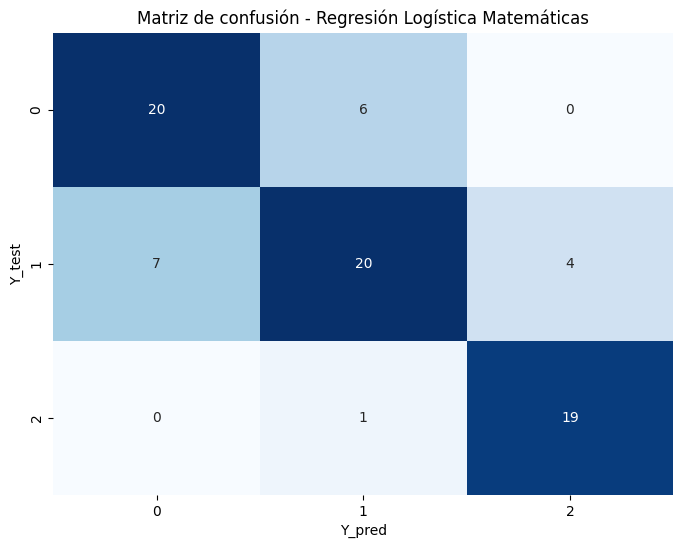

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.74      0.77      0.75        26
       Medio       0.74      0.65      0.69        31
        Alto       0.83      0.95      0.88        20

    accuracy                           0.77        77
   macro avg       0.77      0.79      0.78        77
weighted avg       0.76      0.77      0.76        77



In [ ]:
# REGRESIÓN LOGÍSTICA - MATEMÁTICAS

# 1. Preprocesamiento
y = df_mat_enc["G3_cat"]
X = df_mat_enc[features_final_mat]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Optimización de hiperparámetros
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs"],
    "max_iter": [1000]
}

grid_log = GridSearchCV(
    LogisticRegression(class_weight="balanced", random_state=0),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_log.fit(X_train_scaled, y_train)

log_final = grid_log.best_estimator_
print("Mejores hiperparámetros:", grid_log.best_params_)

# 3. Predicciones
y_pred_train = log_final.predict(X_train_scaled)
y_pred_test = log_final.predict(X_test_scaled)

# 4. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 5. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 6. Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(log_final, X_train_scaled, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 7. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - Regresión Logística Matemáticas")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 8. Reporte de clasificación
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))


In [ ]:
y_pred_logreg_mat = y_pred_test
logreg_mat = log_final

Mejores hiperparámetros: {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}
Accuracy train: 0.8562
Accuracy test: 0.7662
Precision: 0.8267
Recall: 0.7662
F1-score: 0.7779
Diferencia train-test: 0.09
F1 promedio CV: 0.8137
Desviación estándar CV: 0.0464


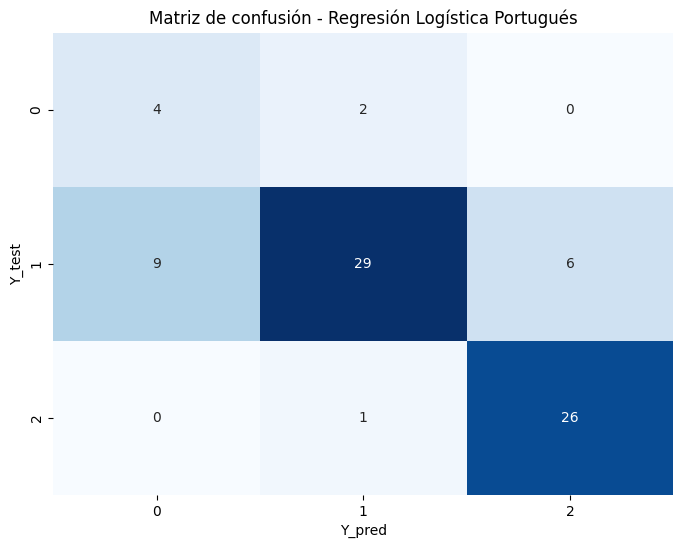

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.31      0.67      0.42         6
       Medio       0.91      0.66      0.76        44
        Alto       0.81      0.96      0.88        27

    accuracy                           0.77        77
   macro avg       0.68      0.76      0.69        77
weighted avg       0.83      0.77      0.78        77



In [ ]:
# REGRESIÓN LOGÍSTICA - PORTUGUÉS

# 1. Preprocesamiento
y = df_por_enc["G3_cat"]
X = df_por_enc[features_final_por]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Optimización de hiperparámetros
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs"],
    "max_iter": [1000]
}

grid_log = GridSearchCV(
    LogisticRegression(class_weight="balanced", random_state=0),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_log.fit(X_train_scaled, y_train)

log_final = grid_log.best_estimator_
print("Mejores hiperparámetros:", grid_log.best_params_)

# 3. Predicciones
y_pred_train = log_final.predict(X_train_scaled)
y_pred_test = log_final.predict(X_test_scaled)

# 4. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 5. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 6. Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(log_final, X_train_scaled, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 7. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - Regresión Logística Portugués")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 8. Reporte de clasificación
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_logreg_por = y_pred_test
logreg_por = log_final

# **Árboles de decisión**

Mejores hiperparámetros: {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}


,Variable,Importancia
4,G2,1.0
0,age,0.0
1,Medu,0.0
2,goout,0.0
3,Walc,0.0
5,G1,0.0
6,failures,0.0
7,famrel,0.0
8,Dalc,0.0
9,schoolsup,0.0


/tmp/ipykernel_24131/1847337153.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias.head(10), x="Importancia", y="Variable", palette="bright", edgecolor="black")


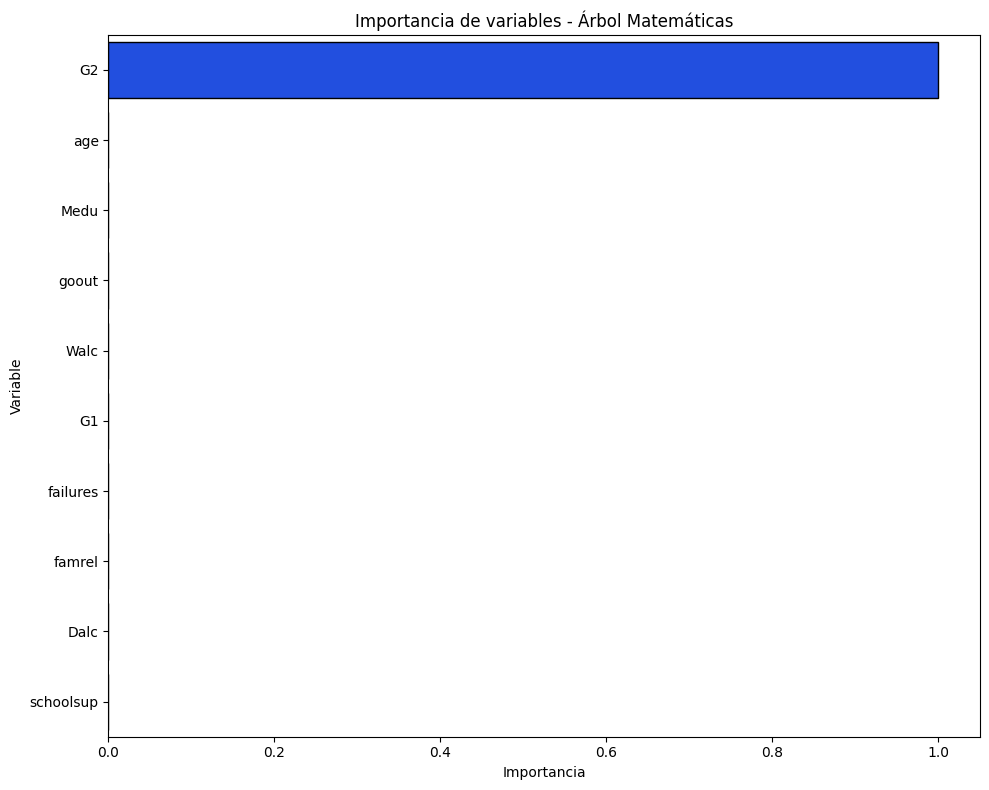

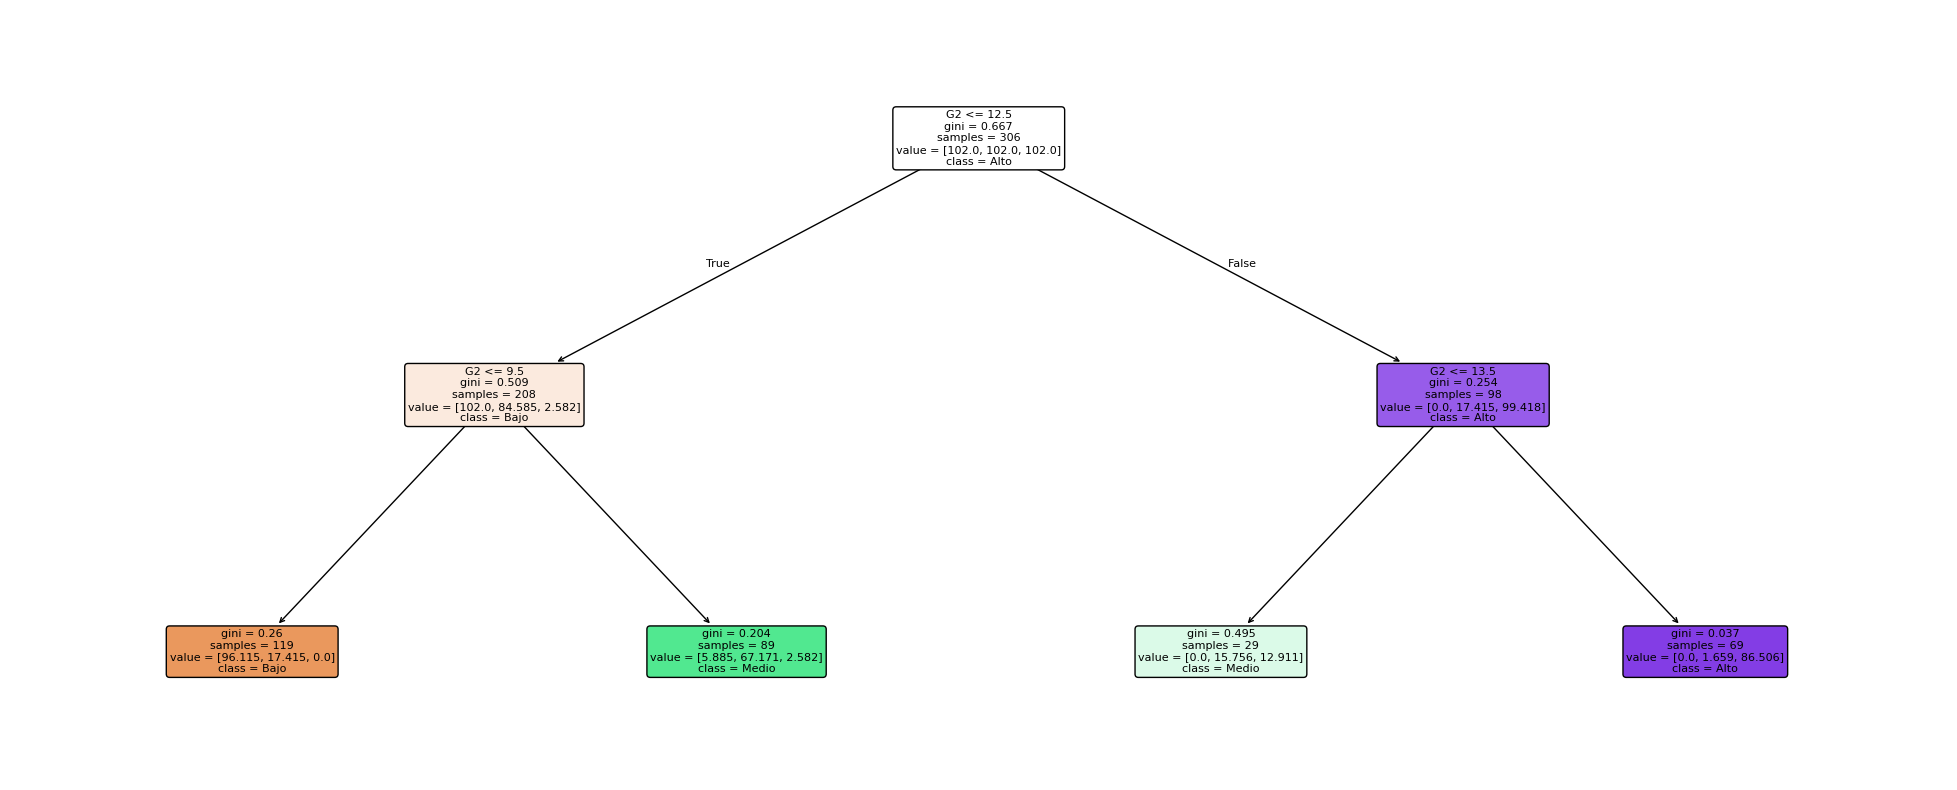

Accuracy train: 0.866
Accuracy test: 0.8701
Precision: 0.8746
Recall: 0.8701
F1-score: 0.871
Diferencia train-test: 0.0041
F1 promedio CV: 0.8474
Desviación estándar CV: 0.0502


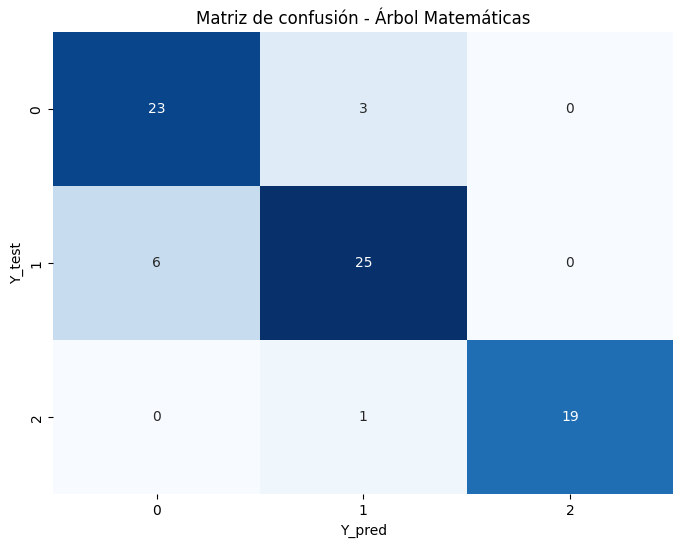

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.79      0.88      0.84        26
       Medio       0.86      0.81      0.83        31
        Alto       1.00      0.95      0.97        20

    accuracy                           0.87        77
   macro avg       0.89      0.88      0.88        77
weighted avg       0.87      0.87      0.87        77



In [ ]:
# ÁRBOL DE DECISIÓN - MATEMÁTICAS

# 1. Preprocesamiento
y = df_mat_enc["G3_cat"]
X = df_mat_enc[features_final_mat]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos: No es necesario en árboles de decisión

# 2. Optimización de hiperparámetros
param_grid = {
    "max_depth": range(1, 15),
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=0, class_weight="balanced"),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

arbol_final = grid_search.best_estimator_
print("Mejores hiperparámetros:", grid_search.best_params_)

# 3. Importancia de variables
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": arbol_final.feature_importances_
}).sort_values(by="Importancia", ascending=False)

display(importancias.head(10))

plt.figure(figsize=(10,8))
sns.barplot(data=importancias.head(10), x="Importancia", y="Variable", palette="bright", edgecolor="black")
plt.title("Importancia de variables - Árbol Matemáticas")
plt.tight_layout()
plt.show()

# 4. Visualización del árbol
plt.figure(figsize=(25,10))
plot_tree(
    arbol_final,
    filled=True,
    feature_names=X.columns.tolist(),
    class_names=["Bajo", "Medio", "Alto"],
    rounded=True,
    fontsize=8
)
plt.show()

# 5. Predicciones
y_pred_train = arbol_final.predict(X_train)
y_pred_test = arbol_final.predict(X_test)

# 6. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 7. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 8. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(arbol_final, X_train, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 9. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - Árbol Matemáticas")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 10. Reporte de clasificación
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_dt_mat = y_pred_test
dt_mat = arbol_final

Mejores hiperparámetros: {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}


,Variable,Importancia
2,G2,0.978547
8,freetime,0.021453
1,age,0.000000
0,school,0.000000
3,G1,0.000000
4,higher,0.000000
6,Medu,0.000000
5,studytime,0.000000
7,Dalc,0.000000
9,internet,0.000000


/tmp/ipykernel_24131/3881312195.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias.head(10), x="Importancia", y="Variable", palette="bright", edgecolor="black")


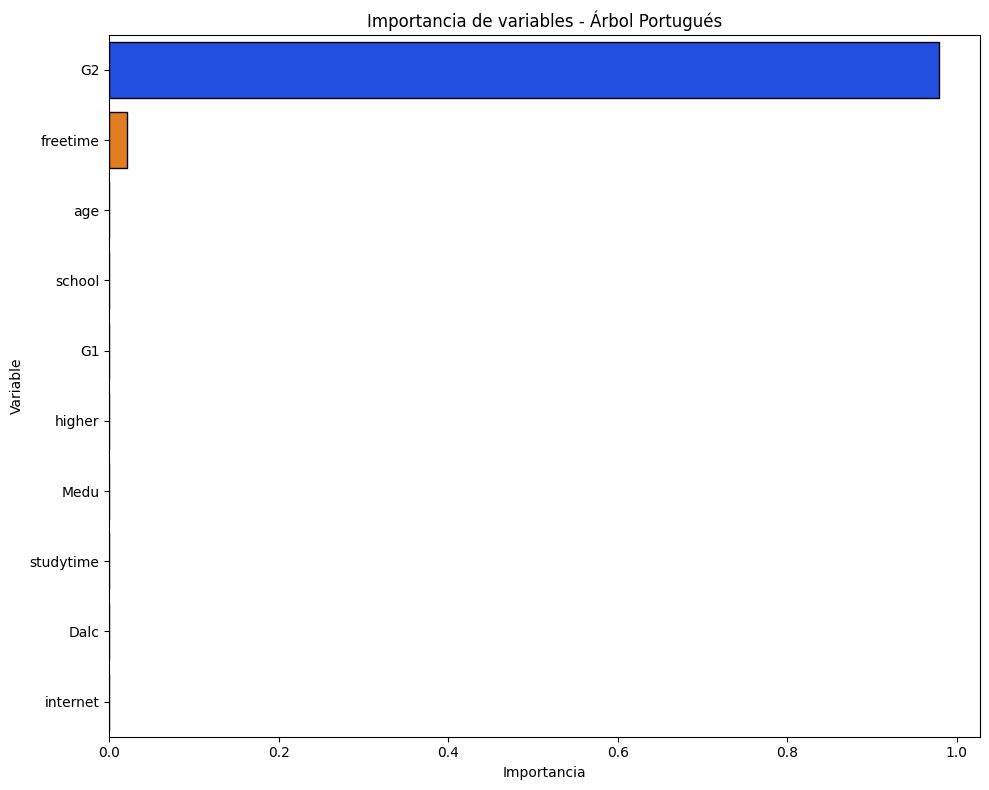

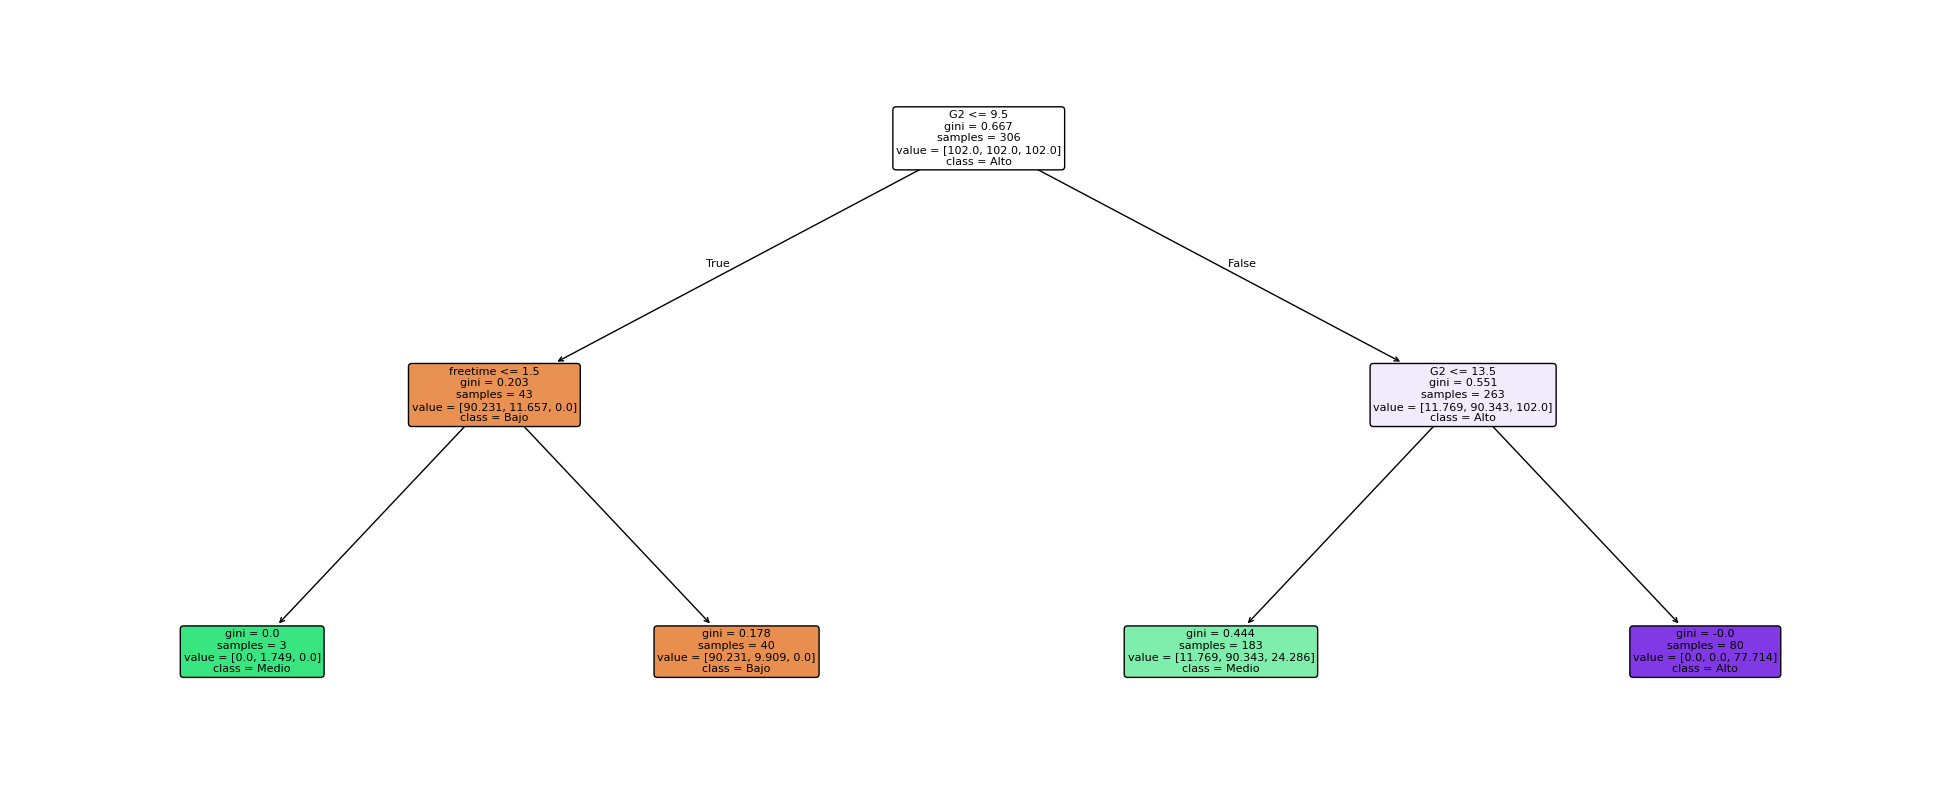

Accuracy train: 0.8529
Accuracy test: 0.8312
Precision: 0.8625
Recall: 0.8312
F1-score: 0.8405
Diferencia train-test: 0.0218
F1 promedio CV: 0.8096
Desviación estándar CV: 0.0409


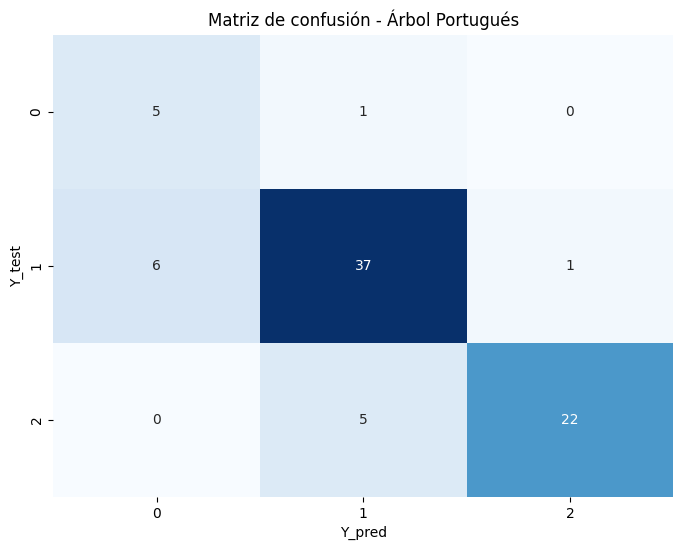

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.45      0.83      0.59         6
       Medio       0.86      0.84      0.85        44
        Alto       0.96      0.81      0.88        27

    accuracy                           0.83        77
   macro avg       0.76      0.83      0.77        77
weighted avg       0.86      0.83      0.84        77



In [ ]:
# ÁRBOL DE DECISIÓN - PORTUGUÉS

# 1. Preprocesamiento
y = df_por_enc["G3_cat"]
X = df_por_enc[features_final_por]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos: No es necesario en árboles de decisión

# 2. Optimización de hiperparámetros
param_grid = {
    "max_depth": range(1, 15),
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=0, class_weight="balanced"),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

arbol_final = grid_search.best_estimator_
print("Mejores hiperparámetros:", grid_search.best_params_)

# 3. Importancia de variables
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": arbol_final.feature_importances_
}).sort_values(by="Importancia", ascending=False)

display(importancias.head(10))

plt.figure(figsize=(10,8))
sns.barplot(data=importancias.head(10), x="Importancia", y="Variable", palette="bright", edgecolor="black")
plt.title("Importancia de variables - Árbol Portugués")
plt.tight_layout()
plt.show()

# 4. Visualización del árbol
plt.figure(figsize=(25,10))
plot_tree(
    arbol_final,
    filled=True,
    feature_names=X.columns.tolist(),
    class_names=["Bajo", "Medio", "Alto"],
    rounded=True,
    fontsize=8
)
plt.show()

# 5. Predicciones
y_pred_train = arbol_final.predict(X_train)
y_pred_test = arbol_final.predict(X_test)

# 6. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 7. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 8. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(arbol_final, X_train, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 9. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - Árbol Portugués")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 10. Reporte de clasificación
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_dt_por = y_pred_test
dt_por = arbol_final

# **Random Forest**

Mejores hiperparámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


,Variable,Importancia
4,G2,0.526300
5,G1,0.289991
6,failures,0.034235
3,Walc,0.028935
2,goout,0.028108
1,Medu,0.023202
0,age,0.021085
8,Dalc,0.019533
7,famrel,0.015626
9,schoolsup,0.012985


/tmp/ipykernel_24131/4077688889.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_rf.head(10), x="Importancia", y="Variable", palette="crest", edgecolor="black")


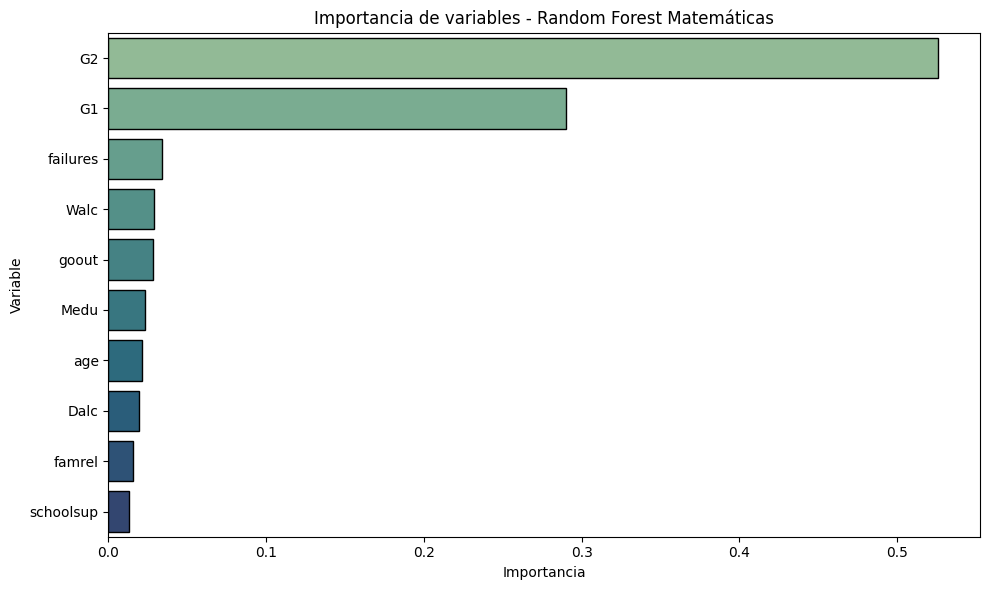

Accuracy train: 0.8954
Accuracy test: 0.8442
Precision: 0.8458
Recall: 0.8442
F1-score: 0.8424
Diferencia train-test: 0.0513
F1 promedio CV: 0.8599
Desviación estándar CV: 0.0249


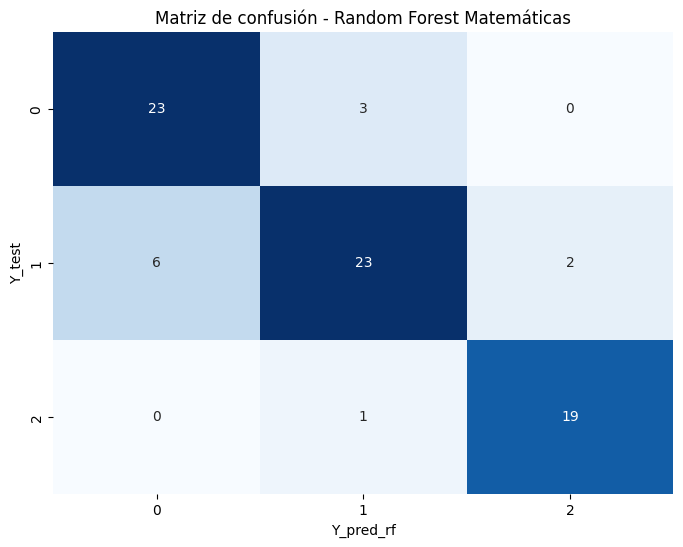

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.79      0.88      0.84        26
       Medio       0.85      0.74      0.79        31
        Alto       0.90      0.95      0.93        20

    accuracy                           0.84        77
   macro avg       0.85      0.86      0.85        77
weighted avg       0.85      0.84      0.84        77



In [ ]:
# RANDOM FOREST - MATEMÁTICAS

# 1. Preprocesamiento
y = df_mat_enc["G3_cat"]
X = df_mat_enc[features_final_mat]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos: No es necesario en Random Forest

# 2. Optimización de hiperparámetros
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 4, 6],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=0, class_weight="balanced_subsample"),
    param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

rf_final = grid_rf.best_estimator_
print("Mejores hiperparámetros:", grid_rf.best_params_)

# 3. Importancia de variables
importancias_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf_final.feature_importances_
}).sort_values(by="Importancia", ascending=False)

display(importancias_rf.head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=importancias_rf.head(10), x="Importancia", y="Variable", palette="crest", edgecolor="black")
plt.title("Importancia de variables - Random Forest Matemáticas")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# 4. Predicciones
y_pred_train_rf = rf_final.predict(X_train)
y_pred_test_rf = rf_final.predict(X_test)

# 5. Métricas
acc_train_rf = accuracy_score(y_train, y_pred_train_rf)
acc_test_rf = accuracy_score(y_test, y_pred_test_rf)
precision_rf = precision_score(y_test, y_pred_test_rf, average="weighted", zero_division=0)
recall_rf = recall_score(y_test, y_pred_test_rf, average="weighted", zero_division=0)
f1_rf = f1_score(y_test, y_pred_test_rf, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train_rf, 4))
print("Accuracy test:", round(acc_test_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall:", round(recall_rf, 4))
print("F1-score:", round(f1_rf, 4))

# 6. Overfitting
over_rf = abs(acc_train_rf - acc_test_rf)
print("Diferencia train-test:", round(over_rf, 4))

# 7. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(rf_final, X_train, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 8. Matriz de confusión
matriz_rf = confusion_matrix(y_test, y_pred_test_rf)

plt.figure(figsize=(8,6))
sns.heatmap(matriz_rf, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - Random Forest Matemáticas")
plt.xlabel("Y_pred_rf")
plt.ylabel("Y_test")
plt.show()

# 9. Reporte de clasificación
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test_rf, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_rfc_mat = y_pred_test_rf
rfc_mat = rf_final

Mejores hiperparámetros: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


,Variable,Importancia
2,G2,0.408709
3,G1,0.298465
7,Dalc,0.049471
10,failures,0.044120
4,higher,0.036572
8,freetime,0.030506
0,school,0.029246
6,Medu,0.028450
5,studytime,0.024204
1,age,0.019913


/tmp/ipykernel_24131/1108797532.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_rf.head(10), x="Importancia", y="Variable", palette="crest", edgecolor="black")


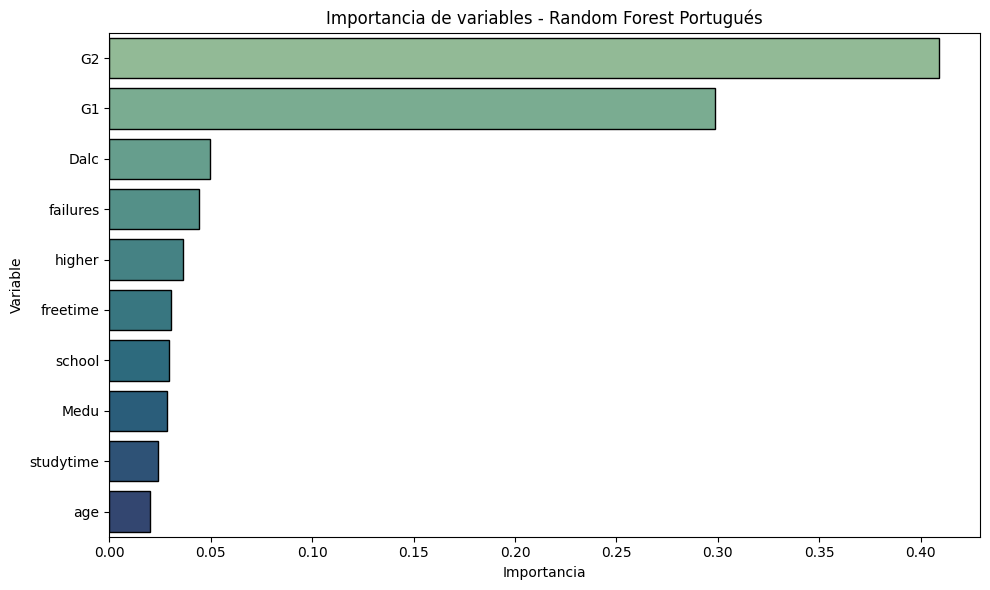

Accuracy train: 0.8791
Accuracy test: 0.8442
Precision: 0.8597
Recall: 0.8442
F1-score: 0.8469
Diferencia train-test: 0.0349
F1 promedio CV: 0.8604
Desviación estándar CV: 0.0409


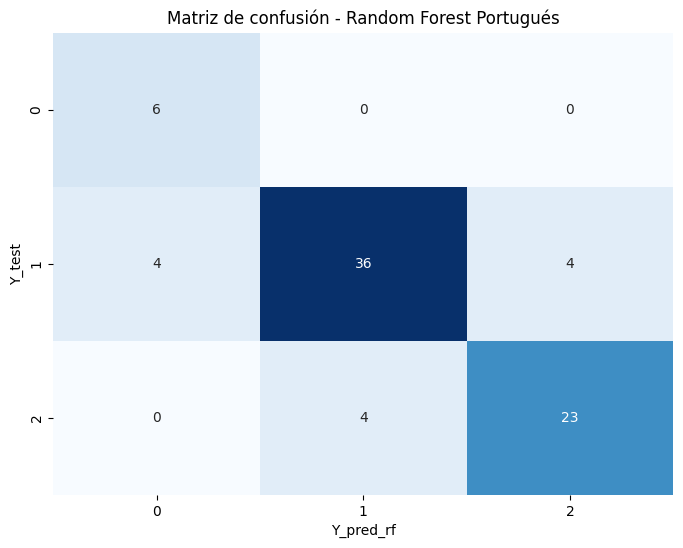

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.60      1.00      0.75         6
       Medio       0.90      0.82      0.86        44
        Alto       0.85      0.85      0.85        27

    accuracy                           0.84        77
   macro avg       0.78      0.89      0.82        77
weighted avg       0.86      0.84      0.85        77



In [ ]:
# RANDOM FOREST - PORTUGUÉS

# 1. Preprocesamiento
y = df_por_enc["G3_cat"]
X = df_por_enc[features_final_por]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos: No es necesario en Random Forest

# 2. Optimización de hiperparámetros
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 4, 6],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=0, class_weight="balanced_subsample"),
    param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

rf_final = grid_rf.best_estimator_
print("Mejores hiperparámetros:", grid_rf.best_params_)

# 3. Importancia de variables
importancias_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf_final.feature_importances_
}).sort_values(by="Importancia", ascending=False)

display(importancias_rf.head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=importancias_rf.head(10), x="Importancia", y="Variable", palette="crest", edgecolor="black")
plt.title("Importancia de variables - Random Forest Portugués")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# 4. Predicciones
y_pred_train_rf = rf_final.predict(X_train)
y_pred_test_rf = rf_final.predict(X_test)

# 5. Métricas
acc_train_rf = accuracy_score(y_train, y_pred_train_rf)
acc_test_rf = accuracy_score(y_test, y_pred_test_rf)
precision_rf = precision_score(y_test, y_pred_test_rf, average="weighted", zero_division=0)
recall_rf = recall_score(y_test, y_pred_test_rf, average="weighted", zero_division=0)
f1_rf = f1_score(y_test, y_pred_test_rf, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train_rf, 4))
print("Accuracy test:", round(acc_test_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall:", round(recall_rf, 4))
print("F1-score:", round(f1_rf, 4))

# 6. Overfitting
over_rf = abs(acc_train_rf - acc_test_rf)
print("Diferencia train-test:", round(over_rf, 4))

# 7. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(rf_final, X_train, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 8. Matriz de confusión
matriz_rf = confusion_matrix(y_test, y_pred_test_rf)

plt.figure(figsize=(8,6))
sns.heatmap(matriz_rf, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - Random Forest Portugués")
plt.xlabel("Y_pred_rf")
plt.ylabel("Y_test")
plt.show()

# 9. Reporte de clasificación
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test_rf, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_rfc_por = y_pred_test_rf
rfc_por = rf_final

# **SVM**

Mejores hiperparámetros: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy train: 0.9085
Accuracy test: 0.7792
Precision: 0.7764
Recall: 0.7792
F1-score: 0.7764
Diferencia train-test: 0.1293
F1 promedio CV: 0.8463
Desviación estándar CV: 0.0286


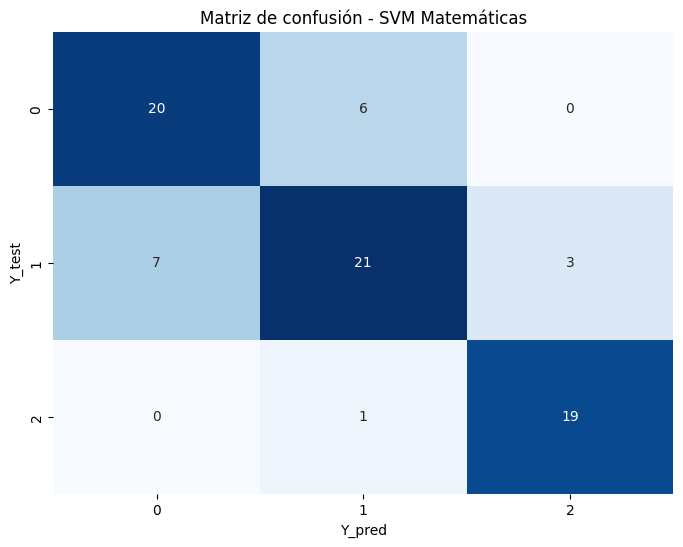

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.74      0.77      0.75        26
       Medio       0.75      0.68      0.71        31
        Alto       0.86      0.95      0.90        20

    accuracy                           0.78        77
   macro avg       0.78      0.80      0.79        77
weighted avg       0.78      0.78      0.78        77



In [ ]:
# SVM - MATEMÁTICAS

# 1. Preprocesamiento
y = df_mat_enc["G3_cat"]
X = df_mat_enc[features_final_mat]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos: necesario para SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Optimización de hiperparámetros
param_grid_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    SVC(class_weight="balanced", probability=True, random_state=0),
    param_grid_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

svm_final = grid_svm.best_estimator_
print("Mejores hiperparámetros:", grid_svm.best_params_)

# 3. Predicciones
y_pred_train = svm_final.predict(X_train_scaled)
y_pred_test = svm_final.predict(X_test_scaled)

# 4. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 5. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 6. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(svm_final, X_train_scaled, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 7. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - SVM Matemáticas")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 8. Reporte
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_svm_mat = y_pred_test
svm_mat = svm_final

Mejores hiperparámetros: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy train: 0.8464
Accuracy test: 0.7922
Precision: 0.8432
Recall: 0.7922
F1-score: 0.8028
Diferencia train-test: 0.0542
F1 promedio CV: 0.8335
Desviación estándar CV: 0.0401


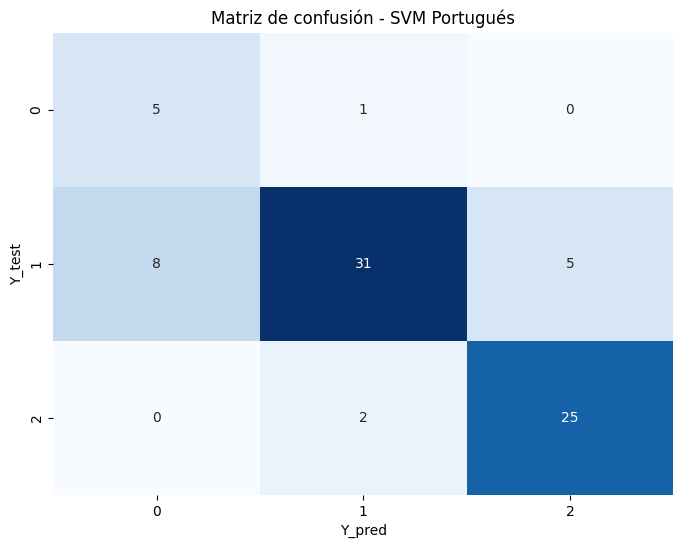

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.38      0.83      0.53         6
       Medio       0.91      0.70      0.79        44
        Alto       0.83      0.93      0.88        27

    accuracy                           0.79        77
   macro avg       0.71      0.82      0.73        77
weighted avg       0.84      0.79      0.80        77



In [ ]:
# SVM - PORTUGUÉS

# 1. Preprocesamiento
y = df_por_enc["G3_cat"]
X = df_por_enc[features_final_por]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos: necesario para SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Optimización de hiperparámetros
param_grid_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    SVC(class_weight="balanced", probability=True, random_state=0),
    param_grid_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

svm_final = grid_svm.best_estimator_
print("Mejores hiperparámetros:", grid_svm.best_params_)

# 3. Predicciones
y_pred_train = svm_final.predict(X_train_scaled)
y_pred_test = svm_final.predict(X_test_scaled)

# 4. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 5. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 6. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(svm_final, X_train_scaled, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 7. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - SVM Portugués")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 8. Reporte
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_svm_por = y_pred_test
svm_por = svm_final

# **Bagging**

Mejores hiperparámetros: {'max_features': 1.0, 'max_samples': 0.6, 'n_estimators': 50}
Accuracy train: 0.8954
Accuracy test: 0.8442
Precision: 0.8479
Recall: 0.8442
F1-score: 0.8404
Diferencia train-test: 0.0513
F1 promedio CV: 0.8564
Desviación estándar CV: 0.0332


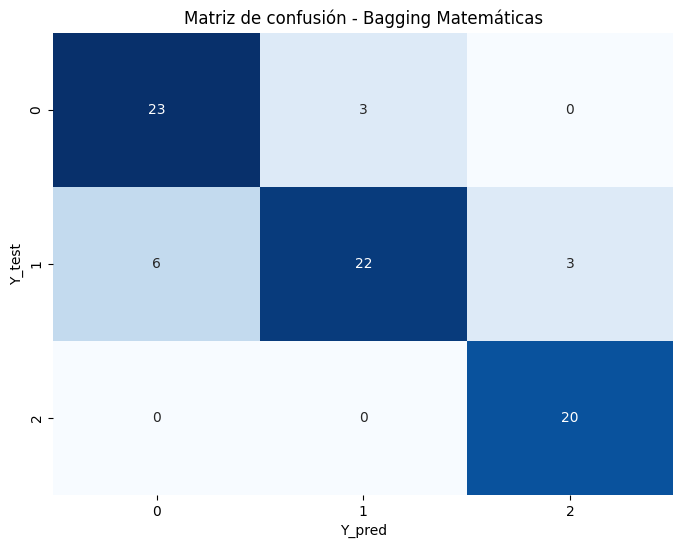

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.79      0.88      0.84        26
       Medio       0.88      0.71      0.79        31
        Alto       0.87      1.00      0.93        20

    accuracy                           0.84        77
   macro avg       0.85      0.86      0.85        77
weighted avg       0.85      0.84      0.84        77



In [ ]:
# BAGGING - MATEMÁTICAS

# 1. Preprocesamiento
y = df_mat_enc["G3_cat"]
X = df_mat_enc[features_final_mat]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos: No es necesario si usamos árbol como estimador base

# 2. Configuración de hiperparámetros
param_grid_bag = {
    "n_estimators": [50, 100, 200],
    "max_samples": [0.6, 0.8, 1.0],
    "max_features": [0.6, 0.8, 1.0]
}

base_tree = DecisionTreeClassifier(
    max_depth=4,
    class_weight="balanced",
    random_state=0
)

bagging = BaggingClassifier(
    estimator=base_tree,
    random_state=0
)

grid_bag = GridSearchCV(
    bagging,
    param_grid_bag,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_bag.fit(X_train, y_train)

bag_final = grid_bag.best_estimator_
print("Mejores hiperparámetros:", grid_bag.best_params_)

# 3. Predicciones
y_pred_train = bag_final.predict(X_train)
y_pred_test = bag_final.predict(X_test)

# 4. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 5. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 6. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(bag_final, X_train, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 7. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - Bagging Matemáticas")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 8. Reporte
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_bag_mat = y_pred_test
bag_mat = bag_final

Mejores hiperparámetros: {'max_features': 0.6, 'max_samples': 0.6, 'n_estimators': 100}
Accuracy train: 0.902
Accuracy test: 0.8701
Precision: 0.8701
Recall: 0.8701
F1-score: 0.8701
Diferencia train-test: 0.0318
F1 promedio CV: 0.8723
Desviación estándar CV: 0.0438


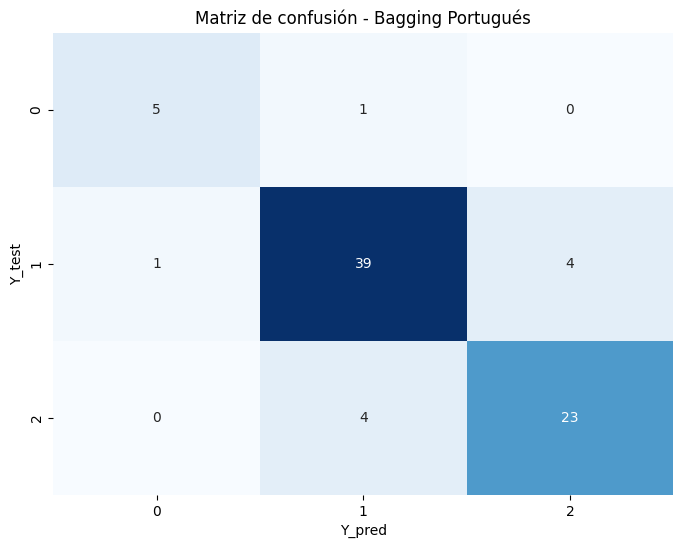

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.83      0.83      0.83         6
       Medio       0.89      0.89      0.89        44
        Alto       0.85      0.85      0.85        27

    accuracy                           0.87        77
   macro avg       0.86      0.86      0.86        77
weighted avg       0.87      0.87      0.87        77



In [ ]:
# BAGGING - PORTUGUÉS

# 1. Preprocesamiento
y = df_por_enc["G3_cat"]
X = df_por_enc[features_final_por]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos: No es necesario si usamos árbol como estimador base

# 2. Configuración de hiperparámetros
param_grid_bag = {
    "n_estimators": [50, 100, 200],
    "max_samples": [0.6, 0.8, 1.0],
    "max_features": [0.6, 0.8, 1.0]
}

base_tree = DecisionTreeClassifier(
    max_depth=4,
    class_weight="balanced",
    random_state=0
)

bagging = BaggingClassifier(
    estimator=base_tree,
    random_state=0
)

grid_bag = GridSearchCV(
    bagging,
    param_grid_bag,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_bag.fit(X_train, y_train)

bag_final = grid_bag.best_estimator_
print("Mejores hiperparámetros:", grid_bag.best_params_)

# 3. Predicciones
y_pred_train = bag_final.predict(X_train)
y_pred_test = bag_final.predict(X_test)

# 4. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 5. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 6. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(bag_final, X_train, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 7. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - Bagging Portugués")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 8. Reporte
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_bag_por = y_pred_test
bag_por = bag_final

# **Boosting**

In [ ]:
# BOOSTING - ADABOOST - MATEMÁTICAS

# 1. Preprocesamiento
y = df_mat_enc["G3_cat"]
X = df_mat_enc[features_final_mat]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos: No es necesario

# 2. Optimización de hiperparámetros
param_grid_ada = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1]
}

ada = AdaBoostClassifier(random_state=0)

grid_ada = GridSearchCV(
    ada,
    param_grid_ada,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)

ada_final = grid_ada.best_estimator_
print("Mejores hiperparámetros:", grid_ada.best_params_)

# 3. Predicciones
y_pred_train = ada_final.predict(X_train)
y_pred_test = ada_final.predict(X_test)

# 4. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 5. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 6. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(ada_final, X_train, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 7. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - AdaBoost Matemáticas")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 8. Reporte
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_ada_clf_mat = y_pred_test
ada_clf_mat = ada_final

Mejores hiperparámetros: {'learning_rate': 0.1, 'n_estimators': 100}
Accuracy train: 0.8725
Accuracy test: 0.8701
Precision: 0.8754
Recall: 0.8701
F1-score: 0.8698
Diferencia train-test: 0.0024
F1 promedio CV: 0.8594
Desviación estándar CV: 0.0327


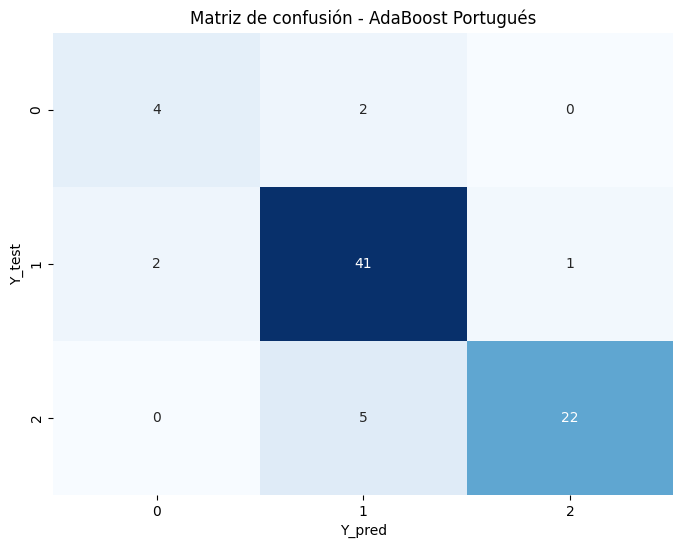

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.67      0.67      0.67         6
       Medio       0.85      0.93      0.89        44
        Alto       0.96      0.81      0.88        27

    accuracy                           0.87        77
   macro avg       0.83      0.80      0.81        77
weighted avg       0.88      0.87      0.87        77



In [ ]:
# BOOSTING - ADABOOST - PORTUGUÉS

# 1. Preprocesamiento
y = df_por_enc["G3_cat"]
X = df_por_enc[features_final_por]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos: No es necesario

# 2. Optimización de hiperparámetros
param_grid_ada = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1]
}

ada = AdaBoostClassifier(random_state=0)

grid_ada = GridSearchCV(
    ada,
    param_grid_ada,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)

ada_final = grid_ada.best_estimator_
print("Mejores hiperparámetros:", grid_ada.best_params_)

# 3. Predicciones
y_pred_train = ada_final.predict(X_train)
y_pred_test = ada_final.predict(X_test)

# 4. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 5. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 6. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(ada_final, X_train, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 7. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - AdaBoost Portugués")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 8. Reporte
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_ada_clf_por = y_pred_test
ada_clf_por = ada_final

# **Gradient Boosting**

Mejores hiperparámetros: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}


,Variable,Importancia
4,G2,0.817935
3,Walc,0.043221
5,G1,0.027414
1,Medu,0.023396
2,goout,0.021861
7,famrel,0.019463
6,failures,0.015599
0,age,0.013970
9,schoolsup,0.008907
8,Dalc,0.008233


/tmp/ipykernel_24131/1522609974.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_gb.head(10), x="Importancia", y="Variable", palette="viridis", edgecolor="black")


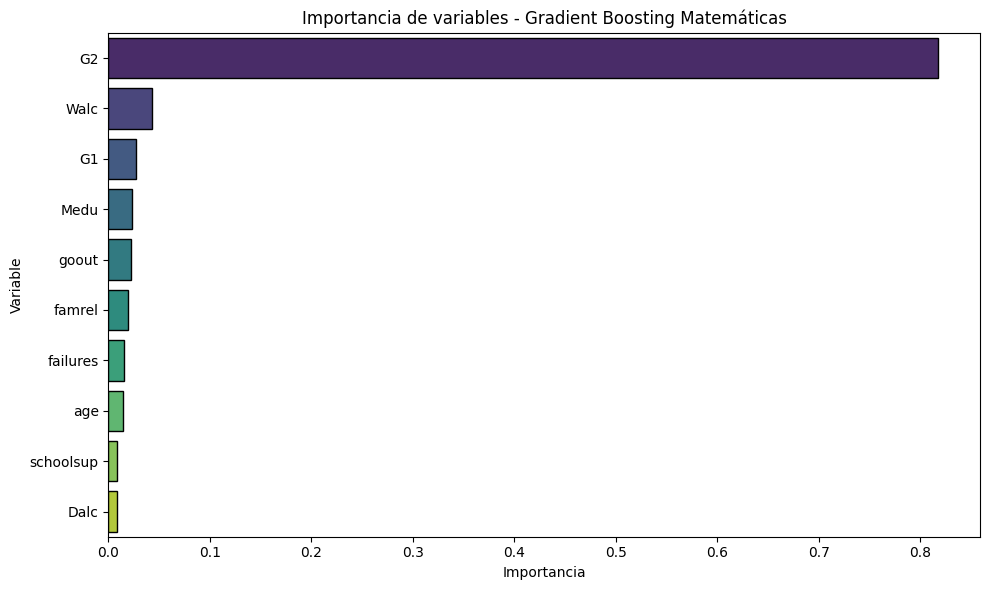

Accuracy train: 0.9673
Accuracy test: 0.8571
Precision: 0.8563
Recall: 0.8571
F1-score: 0.8552
Diferencia train-test: 0.1102
F1 promedio CV: 0.8856
Desviación estándar CV: 0.0397


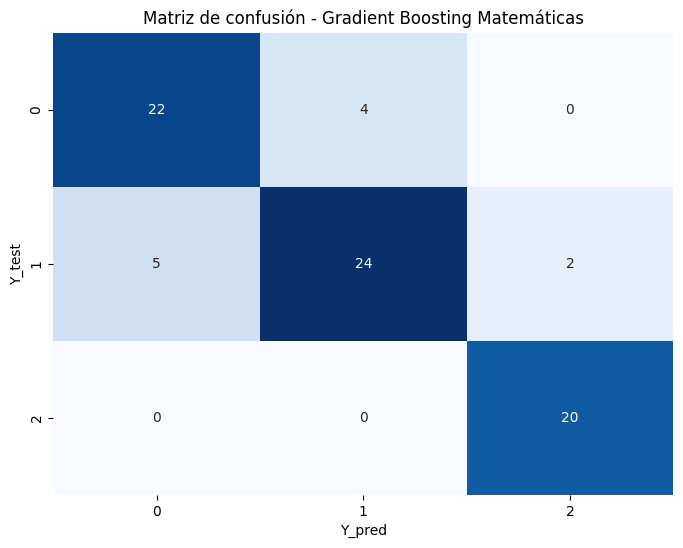

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.81      0.85      0.83        26
       Medio       0.86      0.77      0.81        31
        Alto       0.91      1.00      0.95        20

    accuracy                           0.86        77
   macro avg       0.86      0.87      0.87        77
weighted avg       0.86      0.86      0.86        77



In [ ]:
# GRADIENT BOOSTING - MATEMÁTICAS

# 1. Preprocesamiento
y = df_mat_enc["G3_cat"]
X = df_mat_enc[features_final_mat]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# 2. Optimización de hiperparámetros
param_grid_gb = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [2, 3, 4]
}

gb = GradientBoostingClassifier(random_state=0)

grid_gb = GridSearchCV(
    gb,
    param_grid_gb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

gb_final = grid_gb.best_estimator_
print("Mejores hiperparámetros:", grid_gb.best_params_)

# 3. Importancia de variables
importancias_gb = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": gb_final.feature_importances_
}).sort_values(by="Importancia", ascending=False)

display(importancias_gb.head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=importancias_gb.head(10), x="Importancia", y="Variable", palette="viridis", edgecolor="black")
plt.title("Importancia de variables - Gradient Boosting Matemáticas")
plt.tight_layout()
plt.show()

# 4. Predicciones
y_pred_train = gb_final.predict(X_train)
y_pred_test = gb_final.predict(X_test)

# 5. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 6. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 7. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(gb_final, X_train, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 8. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - Gradient Boosting Matemáticas")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 9. Reporte
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_gb_clf_mat = y_pred_test
gb_clf_mat = gb_final

Mejores hiperparámetros: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100}


,Variable,Importancia
2,G2,9.330335e-01
3,G1,5.826576e-02
11,schoolsup,6.625987e-03
1,age,1.831631e-03
0,school,2.430835e-04
8,freetime,2.388647e-16
6,Medu,1.828231e-16
5,studytime,1.014781e-16
10,failures,2.985446e-17
4,higher,0.000000e+00


/tmp/ipykernel_24131/2997314223.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias_gb.head(10), x="Importancia", y="Variable", palette="viridis", edgecolor="black")


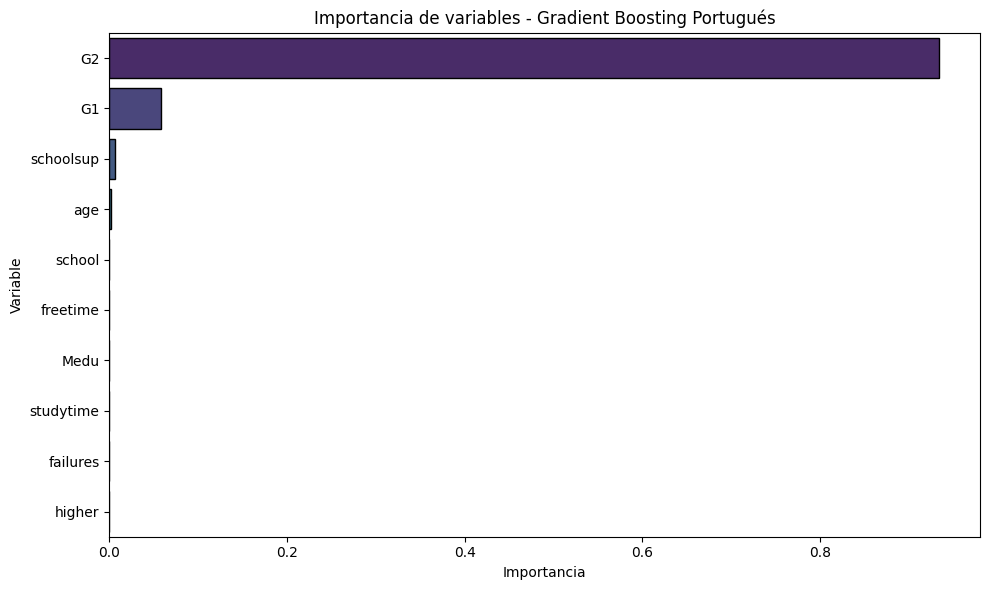

Accuracy train: 0.8758
Accuracy test: 0.8961
Precision: 0.9048
Recall: 0.8961
F1-score: 0.8937
Diferencia train-test: 0.0203
F1 promedio CV: 0.865
Desviación estándar CV: 0.041


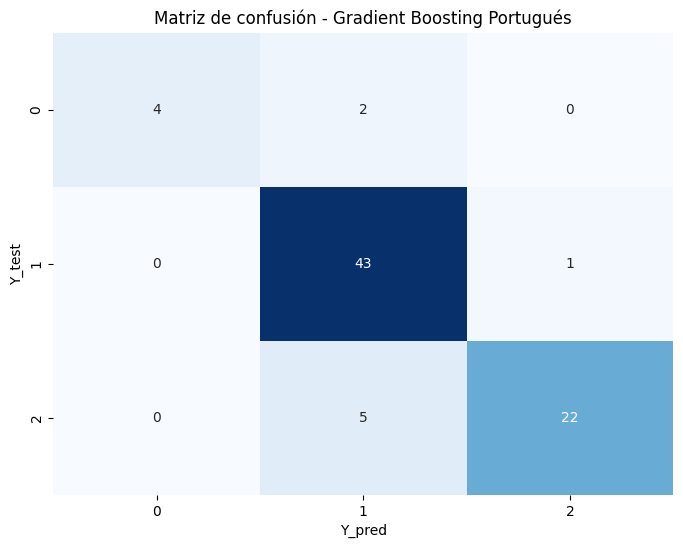

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       1.00      0.67      0.80         6
       Medio       0.86      0.98      0.91        44
        Alto       0.96      0.81      0.88        27

    accuracy                           0.90        77
   macro avg       0.94      0.82      0.86        77
weighted avg       0.90      0.90      0.89        77



In [ ]:
# GRADIENT BOOSTING - PORTUGUÉS

# 1. Preprocesamiento
y = df_por_enc["G3_cat"]
X = df_por_enc[features_final_por]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# 2. Optimización de hiperparámetros
param_grid_gb = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [2, 3, 4]
}

gb = GradientBoostingClassifier(random_state=0)

grid_gb = GridSearchCV(
    gb,
    param_grid_gb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

gb_final = grid_gb.best_estimator_
print("Mejores hiperparámetros:", grid_gb.best_params_)

# 3. Importancia de variables
importancias_gb = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": gb_final.feature_importances_
}).sort_values(by="Importancia", ascending=False)

display(importancias_gb.head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=importancias_gb.head(10), x="Importancia", y="Variable", palette="viridis", edgecolor="black")
plt.title("Importancia de variables - Gradient Boosting Portugués")
plt.tight_layout()
plt.show()

# 4. Predicciones
y_pred_train = gb_final.predict(X_train)
y_pred_test = gb_final.predict(X_test)

# 5. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 6. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 7. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(gb_final, X_train, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 8. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - Gradient Boosting Portugués")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 9. Reporte
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_gb_clf_por = y_pred_test
gb_clf_por = gb_final

# **Voting Classifier**

Accuracy train: 0.9739
Accuracy test: 0.8442
Precision: 0.8432
Recall: 0.8442
F1-score: 0.8428
Diferencia train-test: 0.1297
F1 promedio CV: 0.8634
Desviación estándar CV: 0.042


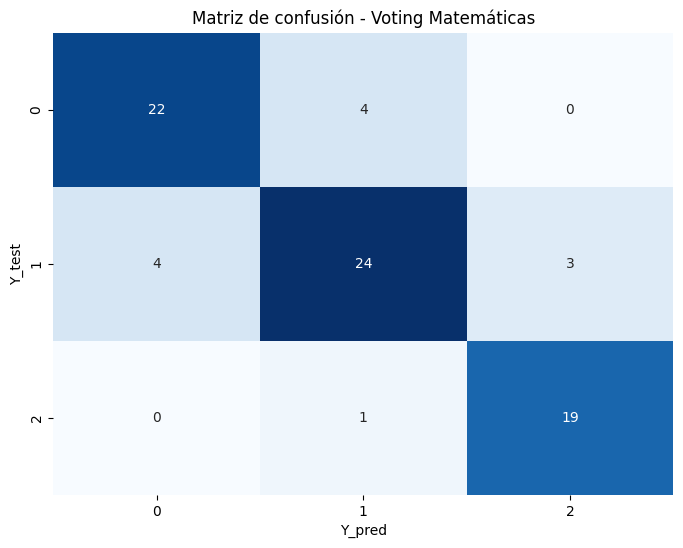

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.85      0.85      0.85        26
       Medio       0.83      0.77      0.80        31
        Alto       0.86      0.95      0.90        20

    accuracy                           0.84        77
   macro avg       0.85      0.86      0.85        77
weighted avg       0.84      0.84      0.84        77



In [ ]:
# VOTING CLASSIFIER - MATEMÁTICAS

# 1. Preprocesamiento
y = df_mat_enc["G3_cat"]
X = df_mat_enc[features_final_mat]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos para modelos que lo necesitan
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Crear modelos base
log_model = LogisticRegression(
    C=1,
    max_iter=1000,
    class_weight="balanced",
    random_state=0
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight="balanced_subsample",
    random_state=0
)

svm_model = SVC(
    C=1,
    kernel="rbf",
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=0
)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=0
)

# 3. Modelo Voting
voting_final = VotingClassifier(
    estimators=[
        ("logistica", log_model),
        ("random_forest", rf_model),
        ("svm", svm_model),
        ("gradient_boosting", gb_model)
    ],
    voting="soft"
)

# En este caso usamos datos escalados porque logística y SVM lo necesitan
voting_final.fit(X_train_scaled, y_train)

# 4. Predicciones
y_pred_train = voting_final.predict(X_train_scaled)
y_pred_test = voting_final.predict(X_test_scaled)

# 5. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 6. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 7. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(voting_final, X_train_scaled, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 8. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - Voting Matemáticas")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 9. Reporte
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_vot_clf_mat = y_pred_test
vot_clf_mat = voting_final

Accuracy train: 0.9412
Accuracy test: 0.8701
Precision: 0.8774
Recall: 0.8701
F1-score: 0.8723
Diferencia train-test: 0.071
F1 promedio CV: 0.8445
Desviación estándar CV: 0.044


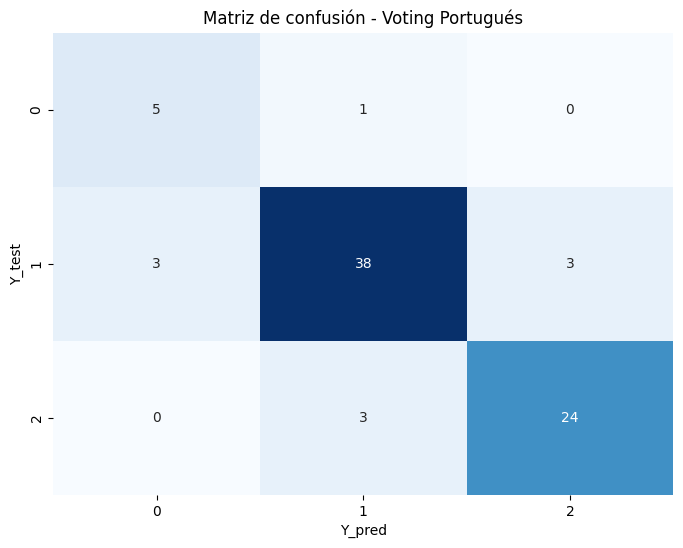

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.62      0.83      0.71         6
       Medio       0.90      0.86      0.88        44
        Alto       0.89      0.89      0.89        27

    accuracy                           0.87        77
   macro avg       0.81      0.86      0.83        77
weighted avg       0.88      0.87      0.87        77



In [ ]:
# VOTING CLASSIFIER - PORTUGUÉS

# 1. Preprocesamiento
y = df_por_enc["G3_cat"]
X = df_por_enc[features_final_por]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos para modelos que lo necesitan
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Crear modelos base
log_model = LogisticRegression(
    C=1,
    max_iter=1000,
    class_weight="balanced",
    random_state=0
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight="balanced_subsample",
    random_state=0
)

svm_model = SVC(
    C=1,
    kernel="rbf",
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=0
)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=0
)

# 3. Modelo Voting
voting_final = VotingClassifier(
    estimators=[
        ("logistica", log_model),
        ("random_forest", rf_model),
        ("svm", svm_model),
        ("gradient_boosting", gb_model)
    ],
    voting="soft"
)

# En este caso usamos datos escalados porque logística y SVM lo necesitan
voting_final.fit(X_train_scaled, y_train)

# 4. Predicciones
y_pred_train = voting_final.predict(X_train_scaled)
y_pred_test = voting_final.predict(X_test_scaled)

# 5. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 6. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 7. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(voting_final, X_train_scaled, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 8. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - Voting Portugués")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 9. Reporte
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

In [ ]:
y_pred_vot_clf_por = y_pred_test
vot_clf_por = voting_final

# **Red Neuronal MLP**

Mejores hiperparámetros: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (20,), 'learning_rate_init': 0.01}
Accuracy train: 0.7941
Accuracy test: 0.7403
Precision: 0.7395
Recall: 0.7403
F1-score: 0.7307
Diferencia train-test: 0.0539
F1 promedio CV: 0.7773
Desviación estándar CV: 0.0724


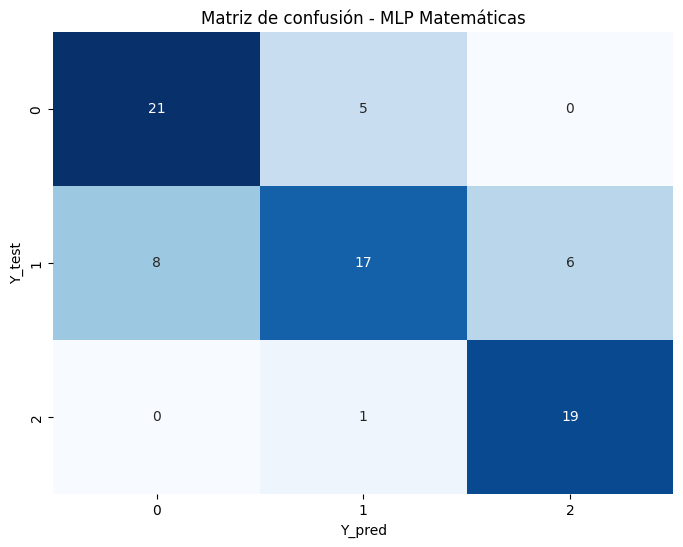

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.72      0.81      0.76        26
       Medio       0.74      0.55      0.63        31
        Alto       0.76      0.95      0.84        20

    accuracy                           0.74        77
   macro avg       0.74      0.77      0.75        77
weighted avg       0.74      0.74      0.73        77



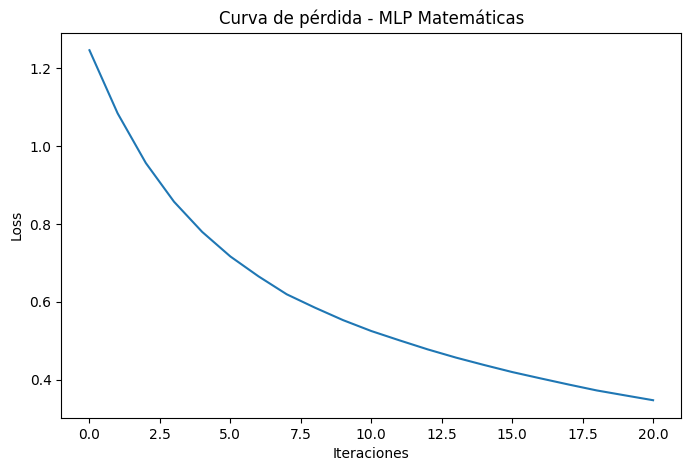

In [ ]:
# RED NEURONAL MLP - MATEMÁTICAS

# 1. Preprocesamiento
y = df_mat_enc["G3_cat"]
X = df_mat_enc[features_final_mat]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos: necesario para MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Optimización de hiperparámetros
param_grid_mlp = {
    "hidden_layer_sizes": [(20,), (30,), (20, 10)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}

mlp = MLPClassifier(
    solver="adam",
    max_iter=1000,
    early_stopping=True,
    random_state=0
)

grid_mlp = GridSearchCV(
    mlp,
    param_grid_mlp,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_mlp.fit(X_train_scaled, y_train)

mlp_final = grid_mlp.best_estimator_
print("Mejores hiperparámetros:", grid_mlp.best_params_)

# 3. Predicciones
y_pred_train = mlp_final.predict(X_train_scaled)
y_pred_test = mlp_final.predict(X_test_scaled)

# 4. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 5. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 6. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(mlp_final, X_train_scaled, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 7. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - MLP Matemáticas")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 8. Reporte
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

# 9. Curva de pérdida
plt.figure(figsize=(8,5))
plt.plot(mlp_final.loss_curve_)
plt.title("Curva de pérdida - MLP Matemáticas")
plt.xlabel("Iteraciones")
plt.ylabel("Loss")
plt.show()

In [ ]:
y_pred_mlp_clf_mat = y_pred_test
mlp_clf_mat = mlp_final

Mejores hiperparámetros: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (20, 10), 'learning_rate_init': 0.01}
Accuracy train: 0.8431
Accuracy test: 0.8052
Precision: 0.8037
Recall: 0.8052
F1-score: 0.8019
Diferencia train-test: 0.0379
F1 promedio CV: 0.7781
Desviación estándar CV: 0.0643


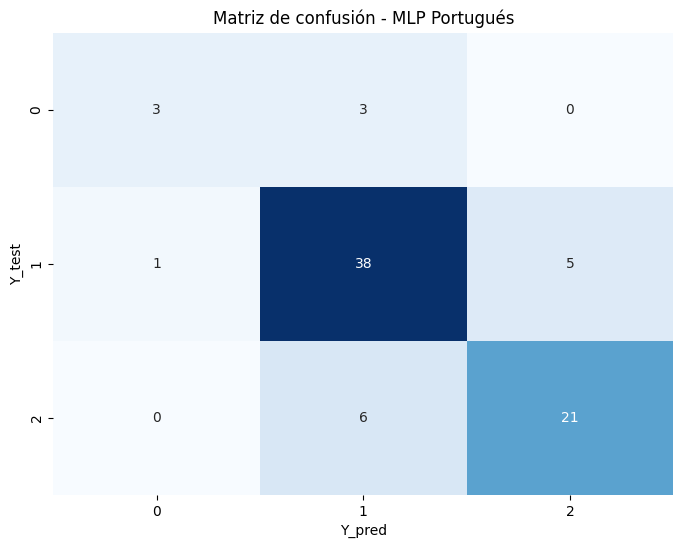

Reporte de clasificación
              precision    recall  f1-score   support

        Bajo       0.75      0.50      0.60         6
       Medio       0.81      0.86      0.84        44
        Alto       0.81      0.78      0.79        27

    accuracy                           0.81        77
   macro avg       0.79      0.71      0.74        77
weighted avg       0.80      0.81      0.80        77



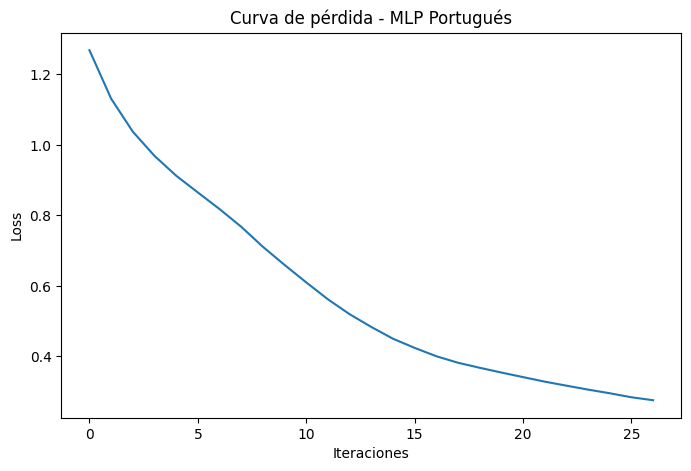

In [ ]:
# RED NEURONAL MLP - PORTUGUÉS

# 1. Preprocesamiento
y = df_por_enc["G3_cat"]
X = df_por_enc[features_final_por]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Escalado de datos: necesario para MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Optimización de hiperparámetros
param_grid_mlp = {
    "hidden_layer_sizes": [(20,), (30,), (20, 10)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}

mlp = MLPClassifier(
    solver="adam",
    max_iter=1000,
    early_stopping=True,
    random_state=0
)

grid_mlp = GridSearchCV(
    mlp,
    param_grid_mlp,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_mlp.fit(X_train_scaled, y_train)

mlp_final = grid_mlp.best_estimator_
print("Mejores hiperparámetros:", grid_mlp.best_params_)

# 3. Predicciones
y_pred_train = mlp_final.predict(X_train_scaled)
y_pred_test = mlp_final.predict(X_test_scaled)

# 4. Métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred_test, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred_test, average="weighted", zero_division=0)

print("Accuracy train:", round(acc_train, 4))
print("Accuracy test:", round(acc_test, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

# 5. Overfitting
over = abs(acc_train - acc_test)
print("Diferencia train-test:", round(over, 4))

# 6. Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(mlp_final, X_train_scaled, y_train, cv=cv, scoring="f1_weighted")

print("F1 promedio CV:", round(cv_scores.mean(), 4))
print("Desviación estándar CV:", round(cv_scores.std(), 4))

# 7. Matriz de confusión
matriz = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - MLP Portugués")
plt.xlabel("Y_pred")
plt.ylabel("Y_test")
plt.show()

# 8. Reporte
print("Reporte de clasificación")
print(classification_report(y_test, y_pred_test, target_names=["Bajo", "Medio", "Alto"], zero_division=0))

# 9. Curva de pérdida
plt.figure(figsize=(8,5))
plt.plot(mlp_final.loss_curve_)
plt.title("Curva de pérdida - MLP Portugués")
plt.xlabel("Iteraciones")
plt.ylabel("Loss")
plt.show()

In [ ]:
y_pred_mlp_clf_por = y_pred_test
mlp_clf_por = mlp_final

In [ ]:
#Tabla comparativa Clasificación - Matemáticas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

modelos_clf_mat={
    "Regresión Logística":y_pred_logreg_mat,
    "Árbol de Decisión":y_pred_dt_mat,
    "Random Forest":y_pred_rfc_mat,
    "SVM":y_pred_svm_mat,
    "Bagging":y_pred_bag_mat,
    "AdaBoost":y_pred_ada_clf_mat,
    "Gradient Boosting":y_pred_gb_clf_mat,
    "Voting":y_pred_vot_clf_mat,
    "MLP":y_pred_mlp_clf_mat
}

resumen_clf_mat=pd.DataFrame({
    "Modelo":list(modelos_clf_mat.keys()),
    "Accuracy":[accuracy_score(y_mat_clf_test,p) for p in modelos_clf_mat.values()],
    "Precision":[precision_score(y_mat_clf_test,p,average="weighted",zero_division=0) for p in modelos_clf_mat.values()],
    "Recall":[recall_score(y_mat_clf_test,p,average="weighted",zero_division=0) for p in modelos_clf_mat.values()],
    "F1-Score":[f1_score(y_mat_clf_test,p,average="weighted",zero_division=0) for p in modelos_clf_mat.values()]
}).round(4).sort_values(by="F1-Score",ascending=False).reset_index(drop=True)

print("Comparación de modelos de Clasificación — Matemáticas")
display(resumen_clf_mat)

Comparación de modelos de Clasificación — Matemáticas


,Modelo,Accuracy,Precision,Recall,F1-Score
0,Árbol de Decisión,0.8701,0.8746,0.8701,0.8710
1,AdaBoost,0.8701,0.8746,0.8701,0.8710
2,Gradient Boosting,0.8571,0.8563,0.8571,0.8552
3,Voting,0.8442,0.8432,0.8442,0.8428
4,Random Forest,0.8442,0.8458,0.8442,0.8424
5,Bagging,0.8442,0.8479,0.8442,0.8404
6,SVM,0.7792,0.7764,0.7792,0.7764
7,Regresión Logística,0.7662,0.7629,0.7662,0.7620
8,MLP,0.7403,0.7395,0.7403,0.7307


In [ ]:
#Tabla comparativa Clasificación - Portugues
modelos_clf_por={
    "Regresión Logística":y_pred_logreg_por,
    "Árbol de Decisión":y_pred_dt_por,
    "Random Forest":y_pred_rfc_por,
    "SVM":y_pred_svm_por,
    "Bagging":y_pred_bag_por,
    "AdaBoost":y_pred_ada_clf_por,
    "Gradient Boosting":y_pred_gb_clf_por,
    "Voting":y_pred_vot_clf_por,
    "MLP":y_pred_mlp_clf_por
}

resumen_clf_por=pd.DataFrame({
    "Modelo":list(modelos_clf_por.keys()),
    "Accuracy":[accuracy_score(y_por_clf_test,p) for p in modelos_clf_por.values()],
    "Precision":[precision_score(y_por_clf_test,p,average="weighted",zero_division=0) for p in modelos_clf_por.values()],
    "Recall":[recall_score(y_por_clf_test,p,average="weighted",zero_division=0) for p in modelos_clf_por.values()],
    "F1-Score":[f1_score(y_por_clf_test,p,average="weighted",zero_division=0) for p in modelos_clf_por.values()]
}).round(4).sort_values(by="F1-Score",ascending=False).reset_index(drop=True)

print("Comparación de modelos de Clasificación — Portugues")
display(resumen_clf_por)

Comparación de modelos de Clasificación — Portugues


,Modelo,Accuracy,Precision,Recall,F1-Score
0,Gradient Boosting,0.8961,0.9048,0.8961,0.8937
1,Voting,0.8701,0.8774,0.8701,0.8723
2,Bagging,0.8701,0.8701,0.8701,0.8701
3,AdaBoost,0.8701,0.8754,0.8701,0.8698
4,Random Forest,0.8442,0.8597,0.8442,0.8469
5,Árbol de Decisión,0.8312,0.8625,0.8312,0.8405
6,SVM,0.7922,0.8432,0.7922,0.8028
7,MLP,0.8052,0.8037,0.8052,0.8019
8,Regresión Logística,0.7662,0.8267,0.7662,0.7779


#Predicciones

In [ ]:
#PREDICCIÓN MATEMÁTICAS - Estudiante simulado
#Variables: age, Medu, goout, Walc, G2, G1, failures, famrel, Dalc, schoolsup

estudiante_mat = pd.DataFrame({
    "age":      [16],   # 16 años
    "Medu":     [3],    # Madre con educación secundaria
    "goout":    [3],    # Sale con amigos nivel medio (1-5)
    "Walc":     [2],    # Alcohol fin de semana bajo (1-5)
    "G2":       [14],   # Segundo parcial: 14
    "G1":       [13],   # Primer parcial: 13
    "failures": [0],    # Sin reprobaciones previas
    "famrel":   [4],    # Buenas relaciones familiares (1-5)
    "Dalc":     [1],    # Alcohol entre semana muy bajo
    "schoolsup":[0]     # No tiene apoyo escolar extra (0=no, 1=sí)
})

#Escalar con el scaler que ya entrenamos
estudiante_mat_scaled = scaler_mat.transform(estudiante_mat)

#Predicción con el mejor modelo (Gradient Boosting Classifier)
prediccion_mat = gb_clf_mat.predict(estudiante_mat_scaled)
probabilidades_mat = gb_clf_mat.predict_proba(estudiante_mat_scaled)

#Mapeo de categorías
categorias = {0:"Bajo (0-9)", 1:"Medio (10-13)", 2:"Alto (14-20)"}

print("="*55)
print("PREDICCIÓN DE RENDIMIENTO - MATEMÁTICAS")
print("="*55)
print("\nPerfil del estudiante:")
print(estudiante_mat.T)
print(f"\nPredicción: {categorias[prediccion_mat[0]]}")
print(f"\nProbabilidades por clase:")
print(f"  Bajo:  {probabilidades_mat[0][0]*100:.1f}%")
print(f"  Medio: {probabilidades_mat[0][1]*100:.1f}%")
print(f"  Alto:  {probabilidades_mat[0][2]*100:.1f}%")

PREDICCIÓN DE RENDIMIENTO - MATEMÁTICAS

Perfil del estudiante:
            0
age        16
Medu        3
goout       3
Walc        2
G2         14
G1         13
failures    0
famrel      4
Dalc        1
schoolsup   0

Predicción: Bajo (0-9)

Probabilidades por clase:
  Bajo:  91.0%
  Medio: 5.9%
  Alto:  3.1%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#PREDICCIÓN REGRESIÓN MATEMÁTICAS - Estudiante simulado
#Variables: age, Medu, goout, Walc, G2, G1, failures, famrel, Dalc, schoolsup

estudiante_mat_reg = pd.DataFrame({
    "age":      [16],
    "Medu":     [3],
    "goout":    [3],
    "Walc":     [2],
    "G2":       [14],
    "G1":       [13],
    "failures": [0],
    "famrel":   [4],
    "Dalc":     [1],
    "schoolsup":[0]
})

#Predicción con Extra Trees (no requiere escalado)
g3_predicho_mat = extra_trees_mat.predict(estudiante_mat_reg)

#Categorizar el resultado para interpretarlo
g3_valor = g3_predicho_mat[0]
if g3_valor <= 9:
    categoria = "Bajo"
elif g3_valor <= 13:
    categoria = "Medio"
else:
    categoria = "Alto"

print("="*55)
print("PREDICCIÓN G3 - MATEMÁTICAS (Regresión)")
print("="*55)
print("\nPerfil del estudiante:")
print(estudiante_mat_reg.T)
print(f"\nG3 predicho: {g3_valor:.2f} / 20")
print(f"Categoría:   {categoria}")
print(f"\nNota: El modelo Extra Trees obtuvo R²=0.847 en test")

PREDICCIÓN G3 - MATEMÁTICAS (Regresión)

Perfil del estudiante:
            0
age        16
Medu        3
goout       3
Walc        2
G2         14
G1         13
failures    0
famrel      4
Dalc        1
schoolsup   0

G3 predicho: 13.95 / 20
Categoría:   Alto

Nota: El modelo Extra Trees obtuvo R²=0.847 en test


In [ ]:
#PREDICCIÓN PORTUGUES - Estudiante simulado
#Variables: school, age, G2, G1, higher, studytime, Medu, Dalc, freetime, internet, failures, schoolsup

estudiante_por = pd.DataFrame({
    "school":   [0],    # 0=Gabriel Pereira, 1=Mousinho da Silveira
    "age":      [17],   # 17 años
    "G2":       [11],   # Segundo parcial: 11
    "G1":       [10],   # Primer parcial: 10
    "higher":   [1],    # Sí quiere estudiar más (0=no, 1=sí)
    "studytime":[2],    # Tiempo de estudio: 2 a 5 horas semanales
    "Medu":     [2],    # Madre con educación 5°-9° grado
    "Dalc":     [1],    # Alcohol entre semana muy bajo (1-5)
    "freetime": [3],    # Tiempo libre nivel medio (1-5)
    "internet": [1],    # Sí tiene internet (0=no, 1=sí)
    "failures": [1],    # 1 reprobación previa
    "schoolsup":[0]     # No tiene apoyo escolar extra
})

#Escalar con el scaler de Portugués
estudiante_por_scaled = scaler_por.transform(estudiante_por)

#Predicción con el mejor modelo (Gradient Boosting Classifier)
prediccion_por = gb_clf_por.predict(estudiante_por_scaled)
probabilidades_por = gb_clf_por.predict_proba(estudiante_por_scaled)

print("="*55)
print("PREDICCIÓN DE RENDIMIENTO - PORTUGUES")
print("="*55)
print("\nPerfil del estudiante:")
print(estudiante_por.T)
print(f"\nPredicción: {categorias[prediccion_por[0]]}")
print(f"\nProbabilidades por clase:")
print(f"  Bajo:  {probabilidades_por[0][0]*100:.1f}%")
print(f"  Medio: {probabilidades_por[0][1]*100:.1f}%")
print(f"  Alto:  {probabilidades_por[0][2]*100:.1f}%")

PREDICCIÓN DE RENDIMIENTO - PORTUGUES

Perfil del estudiante:
            0
school      0
age        17
G2         11
G1         10
higher      1
studytime   2
Medu        2
Dalc        1
freetime    3
internet    1
failures    1
schoolsup   0

Predicción: Bajo (0-9)

Probabilidades por clase:
  Bajo:  68.0%
  Medio: 19.1%
  Alto:  12.9%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#PREDICCIÓN REGRESIÓN PORTUGUES - Estudiante simulado
#Variables: school, age, G2, G1, higher, studytime, Medu, Dalc, freetime, internet, failures, schoolsup

estudiante_por_reg = pd.DataFrame({
    "school":   [0],
    "age":      [17],
    "G2":       [11],
    "G1":       [10],
    "higher":   [1],
    "studytime":[2],
    "Medu":     [2],
    "Dalc":     [1],
    "freetime": [3],
    "internet": [1],
    "failures": [1],
    "schoolsup":[0]
})

#Predicción con Bagged Trees (no requiere escalado)
g3_predicho_por = bagged_trees_por.predict(estudiante_por_reg)

#Categorizar el resultado para interpretarlo
g3_valor = g3_predicho_por[0]
if g3_valor <= 9:
    categoria = "Bajo"
elif g3_valor <= 13:
    categoria = "Medio"
else:
    categoria = "Alto"

print("="*55)
print("PREDICCIÓN G3 - PORTUGUES (Regresión)")
print("="*55)
print("\nPerfil del estudiante:")
print(estudiante_por_reg.T)
print(f"\nG3 predicho: {g3_valor:.2f} / 20")
print(f"Categoría:   {categoria}")
print(f"\nNota: El modelo Bagged Trees obtuvo R²=0.664 en test")

PREDICCIÓN G3 - PORTUGUES (Regresión)

Perfil del estudiante:
            0
school      0
age        17
G2         11
G1         10
higher      1
studytime   2
Medu        2
Dalc        1
freetime    3
internet    1
failures    1
schoolsup   0

G3 predicho: 11.10 / 20
Categoría:   Medio

Nota: El modelo Bagged Trees obtuvo R²=0.664 en test


In [ ]:
#Tabla resumen de predicciones
tabla_predicciones = pd.DataFrame({
    "Materia": ["Matemáticas","Matemáticas","Portugués","Portugués"],
    "Tipo de Modelo": ["Regresión","Clasificación","Regresión","Clasificación"],
    "Modelo Utilizado": ["Extra Trees Regressor","Gradient Boosting Classifier",
                         "Bagged Trees Regressor","Gradient Boosting Classifier"],
    "Predicción": [
        f"G3 ≈ {g3_predicho_mat[0]:.2f} ({'Alto' if g3_predicho_mat[0]>13 else 'Medio' if g3_predicho_mat[0]>9 else 'Bajo'})",
        categorias[prediccion_mat[0]],
        f"G3 ≈ {g3_predicho_por[0]:.2f} ({'Alto' if g3_predicho_por[0]>13 else 'Medio' if g3_predicho_por[0]>9 else 'Bajo'})",
        categorias[prediccion_por[0]]
    ]
})

print("="*70)
print("TABLA DE PREDICCIONES — Comparación Regresión vs Clasificación")
print("="*70)
display(tabla_predicciones)

TABLA DE PREDICCIONES — Comparación Regresión vs Clasificación


,Materia,Tipo de Modelo,Modelo Utilizado,Predicción
0,Matemáticas,Regresión,Extra Trees Regressor,G3 ≈ 13.95 (Alto)
1,Matemáticas,Clasificación,Gradient Boosting Classifier,Bajo (0-9)
2,Portugués,Regresión,Bagged Trees Regressor,G3 ≈ 11.10 (Medio)
3,Portugués,Clasificación,Gradient Boosting Classifier,Bajo (0-9)
